# FINAL

This notebook presents the pair-level, control, network-topology, and validation analyses for the 906-neuron MICrONS structure-function project.

The assignment question is: construct the functional network from the imaging data, compare it with the structural network, ask whether directly connected neurons are strongly correlated, and then perform network analysis to evaluate whether the two networks have similar topology.

The analysis is organized around seven main questions plus H1 validation and scope checks. The map below defines those questions before any data are loaded or any code is run, so the later sections can use the short hypothesis labels without ambiguity.


## 0. Hypothesis Map and Rationale

The hypotheses form a staged answer to the same structure-function question. H1 tests the direct assignment question. H2 and H3 ask whether structural edge details add information beyond binary connectedness. H4-H6 test whether the H1 result remains after the main distance, composition, and tuning controls. H7 moves from pair-level comparisons to network topology. The validation checks ask whether the H1 result also appears in a same-scan cohort and across broader area scopes.

| Hypothesis / check | Analysis question | Why we consider it | Link to the overarching question | Main readout |
|---|---|---|---|---|
| H1. Connected pairs | Are directly connected neuron pairs more functionally correlated than unconnected pairs? | This is the central assignment question and the most direct structure-function comparison. | If anatomy carries functional information, connected pairs should have higher signal correlation on average. | Connected minus unconnected mean `F_corr`, confidence interval, effect size, and neuron-identity permutation null. |
| H2. Synapse strength | Among connected pairs, do stronger synaptic connections have higher functional correlation? | A binary edge may be too coarse; synapse size asks whether edge weight matters. | Tests whether the structural network predicts function in a graded way rather than only as connected versus unconnected. | Spearman correlation between summed synapse size and `F_corr`, plus strength quartile means. |
| H3. Reciprocity | Are bidirectional pairs more functionally similar than unidirectional pairs? | The structural graph is directed, while the functional graph is symmetric; reciprocity is one way to bridge that mismatch. | Tests whether richer directed structural motifs add functional similarity beyond the presence of any edge. | Mean `F_corr` for `none`, `uni`, and `bi` pairs, with pairwise and permutation tests. |
| H4. Distance control | Does the connected-pair effect remain after accounting for soma-soma distance? | Nearby neurons are more likely to be connected and can also be more functionally similar, so distance is the major geometric confound. | Separates direct structure-function alignment from shared spatial organization. | Distance-matched H1 retest, within-distance-bin tests, and logistic control for distance. |
| H5. Composition controls | Does the effect remain within and across area, layer, and cell-type groupings? | Area, layer, and cell type can create apparent functional similarity even without direct connectivity. | Tests whether H1 is a connectivity effect rather than only a composition effect. | Stratified H1 contrasts and joint logistic model with distance plus composition indicators. |
| H6. Orientation similarity | Is connectivity better explained by visual tuning similarity, especially orientation preference? | In visual cortex, like-to-like wiring may reflect tuning similarity; orientation is the most interpretable available tuning axis. | Tests whether signal correlation is just a proxy for orientation co-tuning or captures broader shared response structure. | Orientation-similarity contrast and joint model with `F_corr`, `ori_sim`, and distance. |
| H7. Network topology / hub coupling | Do structurally central neurons also look functionally central? | The prompt asks for network analysis and topology comparison, not only pairwise edge tests. | Tests whether structure-function similarity extends from individual pairs to node-level organization. | Structural degree/strength versus mean functional coupling, partial Spearman tests, and thresholded topology sensitivity. |
| H1 validation / scope checks | Does the connected-pair effect appear in a same-scan V1/L4 cohort, in signal/noise decompositions, and across V1/RL/AL area scopes? | The main H1 result uses a 906-neuron cross-scan signal-correlation cohort. The validation section checks whether the result survives a different measurement regime and narrower/broader biological scopes. | Supports or qualifies the main claim that direct structural connectivity predicts higher functional similarity. | 93-neuron trace/signal/noise H1 tests and exploratory within-area/cross-area H1 contrasts. |

The validation rows are not labeled as a new H8 because they revisit H1 under different measurement and cohort definitions rather than testing a separate primary hypothesis.


## 1. Shared Setup, Data Loading, and Conventions

This section defines imports, paths, plotting style, and shared conventions so the analysis can be run from a fresh kernel without hidden state from the original individual notebooks.

The structural convention is fixed once here: `C[i, j]` means a directed synaptic edge from presynaptic neuron `i` to postsynaptic neuron `j`. Functional similarity is measured with signal correlation across the shared imaging response matrix. Pair-level tests use unordered pairs `i < j`, because the functional correlation matrix is symmetric, while node-level topology tests later return to directed structural degree and strength.


In [102]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from scipy import sparse, stats
from scipy.stats import mannwhitneyu, spearmanr, pearsonr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.api as sm
import networkx as nx

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

ROOT = Path.cwd()
DATA = ROOT / 'Data' if (ROOT / 'Data').exists() else ROOT / 'data'
DATA_DIR = DATA
CACHE_DIR = DATA / 'cache'
CACHE = CACHE_DIR
EXPORTS_DIR = DATA / 'exports'
SYN_CSV = DATA / '1718' / 'raw' / 'synapses_matched.csv'

FIG_DIR = ROOT / 'outputs' / 'figures'
TBL_DIR = ROOT / 'outputs' / 'tables'
OUT_FIG = FIG_DIR
OUT_TBL = TBL_DIR
for path in [FIG_DIR, TBL_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def relpath(path):
    """Display project paths relative to the notebook root."""
    path = Path(path)
    try:
        return path.resolve().relative_to(ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()


PAL_CONN = {'none': '#aab7c4', 'uni': '#4E79A7', 'bi': '#C8453B'}
PAL_AREA = {'V1': '#4E79A7', 'RL': '#F28E2B', 'AL': '#59A14F'}
ORDER_CONN = ['none', 'uni', 'bi']
RAMP_SEQ = sns.color_palette('mako', as_cmap=True)
RAMP_FORE = sns.color_palette('rocket', as_cmap=True)
RAMP_DIV = plt.get_cmap('RdBu_r')
RNG_SEED = 0

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('root       : .')
print(f'data       : {relpath(DATA)}')
print(f'figures out: {relpath(FIG_DIR)}')
print(f'tables out : {relpath(TBL_DIR)}')


root       : .
data       : Data
figures out: outputs/figures
tables out : outputs/tables


## 2. Shared Cohort, Functional Matrix, and Structural Matrix

The 906-neuron cohort and the functional response matrix are loaded once. The structural matrix uses `Data/exports/G_906_edges.csv` as the canonical directed edge table for the merged analysis.

This section also prints the key checks that all later hypotheses depend on: neuron count, functional response shape, valid functional rows, brain-area composition, directed structural edge count, directed density, and the number of finite off-diagonal functional correlations.


In [103]:
# Cohort and functional responses
matched = pd.read_pickle(CACHE_DIR / 'matched_906.pkl').reset_index(drop=True)
N = len(matched)
F = np.load(CACHE_DIR / 'F_906.npy')
valid_path = CACHE_DIR / 'F_906_valid.npy'
valid = np.load(valid_path).astype(bool) if valid_path.exists() else np.isfinite(F).all(axis=1)

if F.shape[0] != N:
    raise ValueError(f'F has {F.shape[0]} rows but matched cohort has {N} neurons')
if valid.shape[0] != N:
    raise ValueError(f'valid mask has {valid.shape[0]} rows but matched cohort has {N} neurons')

# Canonical structural input for this final notebook: exported 906 directed edge table.
edges = pd.read_csv(EXPORTS_DIR / 'G_906_edges.csv')
required_edge_cols = {'pre_neuron_id', 'post_neuron_id', 'synapse_size'}
missing = required_edge_cols.difference(edges.columns)
if missing:
    raise ValueError(f'G_906_edges.csv is missing required columns: {sorted(missing)}')

pt_to_idx = pd.Series(np.arange(N), index=matched['pt_root_id'].astype('int64'))
pre_id = edges['pre_neuron_id'].astype('int64')
post_id = edges['post_neuron_id'].astype('int64')
valid_edge = pre_id.isin(pt_to_idx.index) & post_id.isin(pt_to_idx.index) & (pre_id != post_id)
edges_in = edges.loc[valid_edge].copy()

rows = pt_to_idx.loc[edges_in['pre_neuron_id'].astype('int64')].to_numpy()
cols = pt_to_idx.loc[edges_in['post_neuron_id'].astype('int64')].to_numpy()
data = edges_in['synapse_size'].to_numpy(dtype=np.float64)
C = sparse.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()
C.sum_duplicates()
C_strength = C
A_struct = C_strength != 0

F_corr = np.corrcoef(F)
off_diag = ~np.eye(N, dtype=bool)
finite = np.isfinite(F_corr) & off_diag

area_counts = matched['brain_area'].value_counts(dropna=False).to_dict()
directed_density = C.nnz / (N * (N - 1))
print(f'neurons                  : {N:,}')
print(f'functional response shape: {F.shape}')
print(f'valid functional neurons : {valid.sum():,} / {N:,}')
print(f'brain areas              : {area_counts}')
print(f'directed structural edges: {C.nnz:,}')
print(f'directed density         : {directed_density:.4f}')
print(f'finite off-diagonal Fcorr: {finite.sum():,} / {off_diag.sum():,}')


neurons                  : 906
functional response shape: (906, 116)
valid functional neurons : 906 / 906
brain areas              : {'V1': 728, 'RL': 122, 'AL': 56}
directed structural edges: 11,822
directed density         : 0.0144
finite off-diagonal Fcorr: 819,930 / 819,930


## 3. Shared Pair Table for Pair-Level Analyses

This table is the shared data layer for the pair-level hypotheses defined above. It contains one row per unordered neuron pair and combines functional similarity with structural edge labels, synaptic-strength summaries, distance, coarse composition, and orientation similarity.

The same table feeds H1-H6 so that the analyses are comparable. H1 uses `connected` and `f_corr`; H2 adds synaptic strength; H3 uses `conn_type`; H4 uses `dist_um`; H5 uses area, layer, and cell-type indicators; H6 uses `ori_sim` and `gOSI_min`. Keeping this table shared prevents small differences in filtering or matrix alignment from creating inconsistent results across sections.


In [104]:
# Shared unordered pair table for H1-H6.
# Matrix convention throughout: C[i, j] is the edge from presynaptic neuron i to postsynaptic neuron j.
C_dense = C.toarray()
A_pre = C_dense > 0
A_post = C_dense.T > 0
A_und = A_pre | A_post
np.fill_diagonal(A_und, False)
bidir = A_pre & A_post

xyz = matched[['pt_position_x', 'pt_position_y', 'pt_position_z']].to_numpy(dtype=float)
ori = np.deg2rad(matched['pref_ori'].to_numpy(dtype=float))
gOSI = matched['gOSI'].to_numpy(dtype=float)
area = matched['brain_area'].astype(str).to_numpy()
layer = matched['layer'].astype(str).to_numpy()
ctype = matched['cell_type'].astype(str).to_numpy()

iu, ju = np.triu_indices(N, k=1)
fc_pair = F_corr[iu, ju]
keep = np.isfinite(fc_pair)
iu, ju = iu[keep], ju[keep]
area_i, area_j = area[iu], area[ju]

syn_ij = C_dense[iu, ju]
syn_ji = C_dense[ju, iu]
pairs = pd.DataFrame({
    'i': iu,
    'j': ju,
    'pre_to_post_ij': A_pre[iu, ju],
    'pre_to_post_ji': A_pre[ju, iu],
    'f_corr': F_corr[iu, ju],
    'syn_ij': syn_ij,
    'syn_ji': syn_ji,
    'syn_size_max': np.maximum(syn_ij, syn_ji),
    'syn_size_sum': syn_ij + syn_ji,
    'connected': A_und[iu, ju],
    'conn_type': np.where(bidir[iu, ju], 'bi', np.where(A_und[iu, ju], 'uni', 'none')),
    'dist_um': np.linalg.norm(xyz[iu] - xyz[ju], axis=1),
    'same_area': area_i == area_j,
    'same_layer': layer[iu] == layer[ju],
    'same_celltype': ctype[iu] == ctype[ju],
    'area_pair': [f'{a}-{b}' if a <= b else f'{b}-{a}' for a, b in zip(area_i, area_j)],
    'ori_sim': np.cos(2.0 * (ori[iu] - ori[ju])),
    'gOSI_min': np.minimum(gOSI[iu], gOSI[ju]),
})

n_total_possible = N * (N - 1) // 2
print(f'unordered pairs possible : {n_total_possible:,}')
print(f'pairs with finite F_corr : {len(pairs):,}')
print(f'connected pairs          : {pairs.connected.sum():,}')
print(f'unconnected pairs        : {(~pairs.connected).sum():,}')
print('conn_type counts         :', pairs['conn_type'].value_counts().reindex(ORDER_CONN).to_dict())
print()
print('mean F_corr by connection class:')
print(pairs.groupby('conn_type')['f_corr'].agg(['count', 'mean', 'std']).reindex(ORDER_CONN))
pairs.head()


unordered pairs possible : 409,965
pairs with finite F_corr : 409,965
connected pairs          : 11,580
unconnected pairs        : 398,385
conn_type counts         : {'none': 398385, 'uni': 11338, 'bi': 242}

mean F_corr by connection class:
            count      mean       std
conn_type                            
none       398385  0.022256  0.137008
uni         11338  0.055432  0.143400
bi            242  0.067990  0.166750


,i,j,pre_to_post_ij,pre_to_post_ji,f_corr,syn_ij,syn_ji,syn_size_max,syn_size_sum,connected,conn_type,dist_um,same_area,same_layer,same_celltype,area_pair,ori_sim,gOSI_min
0,0,1,False,False,0.150864,0.0,0.0,0.0,0.0,False,none,227.384660,True,True,True,V1-V1,0.687918,0.476260
1,0,2,False,False,0.306225,0.0,0.0,0.0,0.0,False,none,221.865090,True,False,False,V1-V1,-0.302914,0.449638
2,0,3,False,False,0.128291,0.0,0.0,0.0,0.0,False,none,96.129063,True,True,True,V1-V1,0.054335,0.228730
3,0,4,False,False,0.044584,0.0,0.0,0.0,0.0,False,none,124.381255,True,True,True,V1-V1,0.398111,0.096377
4,0,5,False,False,0.022606,0.0,0.0,0.0,0.0,False,none,183.507512,True,True,True,V1-V1,0.034475,0.430073


## 4. H1. Directly Connected Neurons Have Higher Functional Similarity

H1 is the main pair-level structure-function test. The structural network says whether a pair of neurons has a direct synaptic connection; the functional network gives the pair's signal correlation. If structural connectivity carries functional information, connected pairs should have higher `F_corr` than unconnected pairs on average.

The first analysis reports the raw connected-versus-unconnected contrast, including the mean shift, bootstrap confidence interval, Mann-Whitney test, and Cohen's d. The primary inferential check is a neuron-identity permutation null that keeps the structural graph and functional values fixed but randomizes which neuron identities are paired. This matters because pair rows are not independent; each neuron appears in many pairs.


In [105]:
def boot_mean_diff(a, b, n_boot=5000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    na, nb = len(a), len(b)
    for k in range(n_boot):
        diffs[k] = rng.choice(a, na, replace=True).mean() - rng.choice(b, nb, replace=True).mean()
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

f_none = pairs.loc[pairs.conn_type == 'none', 'f_corr'].to_numpy()
f_uni  = pairs.loc[pairs.conn_type == 'uni',  'f_corr'].to_numpy()
f_bi   = pairs.loc[pairs.conn_type == 'bi',   'f_corr'].to_numpy()
f_conn = pairs.loc[pairs.connected,           'f_corr'].to_numpy()

U_h1, p_h1     = mannwhitneyu(f_conn, f_none, alternative='greater')
md_h1, ci_h1   = boot_mean_diff(f_conn, f_none)
d_h1           = cohens_d(f_conn, f_none)
median_diff_h1 = float(np.median(f_conn) - np.median(f_none))

print(f'H1 - connected (n={len(f_conn):,}) vs unconnected (n={len(f_none):,})')
print(f'  delta-mean   (conn - none) = {md_h1:+.4f}    95% CI [{ci_h1[0]:+.4f}, {ci_h1[1]:+.4f}]')
print(f'  delta-median (conn - none) = {median_diff_h1:+.4f}')
print(f'  Mann-Whitney U             = {U_h1:.3e}    one-sided p = {p_h1:.3e}')
print(f"  Cohen's d                  = {d_h1:+.3f}    (small effect by Cohen's conventions)")
print('  NOTE: the MW p-value treats pairs as independent, which they are not;')
print('        a neuron-level permutation null is computed in the next section.')

H1_RESULT = {
    'hypothesis':     'H1',
    'description':    'connected > unconnected (signal F_corr)',
    'test_direction': 'one-sided (connected > unconnected)',
    'n_connected':    int(len(f_conn)),
    'n_unconnected':  int(len(f_none)),
    'mean_diff':      float(md_h1),
    'median_diff':    median_diff_h1,
    'ci_lo':          float(ci_h1[0]),
    'ci_hi':          float(ci_h1[1]),
    'cohens_d':       float(d_h1),
    'mannwhitney_U':  float(U_h1),
    'p_one_sided':    float(p_h1),
}


H1 - connected (n=11,580) vs unconnected (n=398,385)
  delta-mean   (conn - none) = +0.0335    95% CI [+0.0309, +0.0361]
  delta-median (conn - none) = +0.0326
  Mann-Whitney U             = 2.614e+09    one-sided p = 4.758e-133
  Cohen's d                  = +0.244    (small effect by Cohen's conventions)
  NOTE: the MW p-value treats pairs as independent, which they are not;
        a neuron-level permutation null is computed in the next section.


In [106]:
# ---- neuron-identity permutation null for H1 ----
# The structural undirected adjacency A_und (computed in section 4) is held fixed.
# For each permutation pi we re-read each pair's connection status as A_und[pi[i], pi[j]],
# recompute Delta-mean(conn - none) using the original f_corr values, and tally how
# often that exceeds the observed Delta-mean.

iu_all, ju_all = np.triu_indices(N, k=1)
fmask = np.isfinite(F_corr[iu_all, ju_all])
iu_all = iu_all[fmask]
ju_all = ju_all[fmask]
f_pairs_arr = F_corr[iu_all, ju_all]

# A_und was implicitly built in section 4; reconstruct it here so this cell is self-contained
A_und = (C_dense > 0) | (C_dense.T > 0)
np.fill_diagonal(A_und, False)

obs_diff = float(f_conn.mean() - f_none.mean())

N_PERM = 10000
rng = np.random.default_rng(RNG_SEED)
perm_diffs = np.empty(N_PERM)
for k in range(N_PERM):
    pi = rng.permutation(N)
    conn_k = A_und[pi[iu_all], pi[ju_all]]
    perm_diffs[k] = f_pairs_arr[conn_k].mean() - f_pairs_arr[~conn_k].mean()

n_exceed = int((perm_diffs >= obs_diff).sum())
p_perm   = (n_exceed + 1) / (N_PERM + 1)   # one-sided, with the standard +1/+1 correction
null_mu  = float(perm_diffs.mean())
null_sd  = float(perm_diffs.std(ddof=1))
null_lo, null_hi = np.percentile(perm_diffs, [2.5, 97.5])
z_obs = (obs_diff - null_mu) / null_sd if null_sd > 0 else float('inf')

print(f'H1 neuron-identity permutation null (n_perm = {N_PERM:,})')
print(f'  observed delta-mean    = {obs_diff:+.4f}')
print(f'  null mean +/- std      = {null_mu:+.4f} +/- {null_sd:.4f}')
print(f'  null 95% range         = [{null_lo:+.4f}, {null_hi:+.4f}]')
print(f'  observed sits at z     = {z_obs:+.2f}  std deviations from null mean')
print(f'  one-sided perm p-value = {p_perm:.4e}   (#perms >= observed: {n_exceed}/{N_PERM})')

H1_RESULT['perm_n']             = int(N_PERM)
H1_RESULT['perm_null_mean']     = null_mu
H1_RESULT['perm_null_std']      = null_sd
H1_RESULT['perm_z']             = float(z_obs)
H1_RESULT['perm_p_one_sided']   = float(p_perm)


H1 neuron-identity permutation null (n_perm = 10,000)
  observed delta-mean    = +0.0334
  null mean +/- std      = +0.0000 +/- 0.0016
  null 95% range         = [-0.0032, +0.0033]
  observed sits at z     = +20.42  std deviations from null mean
  one-sided perm p-value = 9.9990e-05   (#perms >= observed: 0/10000)


### H1 Conclusion

H1 is the central pair-level result. In the 906-neuron cohort, connected pairs show a clear upward shift in signal correlation relative to unconnected pairs. The effect is modest in absolute size, but it remains far outside the neuron-identity permutation null, which directly addresses pair non-independence.

The interpretation is population-level rather than pair-deterministic: direct synaptic connectivity enriches for functional similarity, but it does not determine the response similarity of any single neuron pair. The later hypotheses quantify how this result changes when edge weight, directionality, spatial distance, composition, tuning similarity, and topology-level comparisons are added.


## 5. H2. Synapse Strength Gradient

H2 asks whether the H1 effect is only a binary edge effect or whether stronger anatomical connections also predict stronger functional similarity. This is important because a structural network can be represented either as an unweighted adjacency matrix or as a weighted synaptic graph.

The primary structural weight here is summed synapse size across the two directions of an unordered pair. Spearman correlation is used because synapse size is heavy-tailed and the question is whether stronger pairs tend to rank higher in functional similarity. The log-strength Pearson check and strength-quartile means help translate the rank result into a more interpretable effect-size scale.


In [107]:
def boot_spearman_ci(x, y, n_boot=2000, seed=RNG_SEED):
    """95% percentile bootstrap CI for Spearman rho. Pairs (x, y) are resampled
    jointly so the rank-relation within each resample is preserved."""
    rng = np.random.default_rng(seed)
    n = len(x)
    x = np.asarray(x); y = np.asarray(y)
    rhos = np.empty(n_boot)
    for k in range(n_boot):
        idx = rng.integers(0, n, n)
        rhos[k] = spearmanr(x[idx], y[idx]).statistic
    return float(np.percentile(rhos, 2.5)), float(np.percentile(rhos, 97.5))

conn = pairs.loc[pairs.connected].copy()
# Spearman is rank-invariant, so no transform of `syn_size_sum` is needed for the
# primary statistic. log10(...) is computed only for the Pearson sensitivity check
# and for plotting, since `syn_size_sum` is heavy-tailed (max ~ 6e5).
conn['log10_size_sum'] = np.log10(conn['syn_size_sum'].clip(lower=1.0))
conn['log10_size_max'] = np.log10(conn['syn_size_max'].clip(lower=1.0))

rho_h2,    p_rho_h2    = spearmanr(conn['syn_size_sum'], conn['f_corr'])
rho_max,   p_rho_max   = spearmanr(conn['syn_size_max'], conn['f_corr'])
r_pearson, p_pearson   = pearsonr(conn['log10_size_sum'], conn['f_corr'])
ci_lo_h2,  ci_hi_h2    = boot_spearman_ci(conn['syn_size_sum'].to_numpy(),
                                          conn['f_corr'].to_numpy())
r2_log = float(r_pearson ** 2)

print(f'H2 - connected pairs only (n={len(conn):,})')
print(f'  Spearman rho (syn_size_sum, f_corr)   = {rho_h2:+.4f}    '
      f'95% boot CI [{ci_lo_h2:+.4f}, {ci_hi_h2:+.4f}]    p = {p_rho_h2:.2e}    (primary, two-sided)')
print(f'  Spearman rho (syn_size_max, f_corr)   = {rho_max:+.4f}    p = {p_rho_max:.2e}    (sensitivity check)')
print(f'  Pearson  r   (log10 size_sum, f_corr) = {r_pearson:+.4f}    p = {p_pearson:.2e}')
print(f'  Pearson  r^2 on log10 strength        = {r2_log:.4f}    '
      f'(<1% of F_corr variance is *linearly* explained by log strength)')
print('  NOTE: Spearman rho^2 is NOT a fraction of variance explained;')
print('        we report the Pearson r^2 on log10 strength as the proper variance-explained scale.')

conn['quartile'] = pd.qcut(conn['syn_size_sum'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
q = conn.groupby('quartile', observed=True)['f_corr'].agg(['count', 'mean', 'sem'])
print()
print('quartile means of F_corr (Q1 = weakest, Q4 = strongest):')
print(q)

H2_RESULT = {
    'hypothesis':         'H2',
    'description':        'syn_size_sum vs F_corr (connected only)',
    'test_direction':     'two-sided Spearman',
    'n_connected':        int(len(conn)),
    'spearman_rho_sum':   float(rho_h2),
    'spearman_ci_lo':     float(ci_lo_h2),
    'spearman_ci_hi':     float(ci_hi_h2),
    'p_spearman_sum':     float(p_rho_h2),
    'spearman_rho_max':   float(rho_max),
    'p_spearman_max':     float(p_rho_max),
    'pearson_log10_r':    float(r_pearson),
    'pearson_log10_r2':   r2_log,
    'p_pearson_log10':    float(p_pearson),
}


H2 - connected pairs only (n=11,580)
  Spearman rho (syn_size_sum, f_corr)   = +0.0686    95% boot CI [+0.0498, +0.0861]    p = 1.44e-13    (primary, two-sided)
  Spearman rho (syn_size_max, f_corr)   = +0.0690    p = 1.09e-13    (sensitivity check)
  Pearson  r   (log10 size_sum, f_corr) = +0.0695    p = 6.77e-14
  Pearson  r^2 on log10 strength        = 0.0048    (<1% of F_corr variance is *linearly* explained by log strength)
  NOTE: Spearman rho^2 is NOT a fraction of variance explained;
        we report the Pearson r^2 on log10 strength as the proper variance-explained scale.

quartile means of F_corr (Q1 = weakest, Q4 = strongest):
          count      mean       sem
quartile                           
Q1         2895  0.044211  0.002594
Q2         2895  0.052571  0.002657
Q3         2895  0.054816  0.002676
Q4         2895  0.071179  0.002748


In [108]:
# ---- neuron-identity permutation null for H2 ----
# For each permutation pi:
#   - syn_ij_perm = C[pi[i], pi[j]],  syn_ji_perm = C[pi[j], pi[i]]
#   - syn_sum_perm = syn_ij_perm + syn_ji_perm
#   - 'connected' pairs are those with syn_sum_perm > 0
#   - Spearman rho is recomputed on (syn_sum_perm, f_corr) over those pairs.
# F_corr and C are both fixed; only neuron labels move. Two-sided test.

N_PERM_H2 = 5000
rng = np.random.default_rng(RNG_SEED + 1)
obs_rho_h2 = float(rho_h2)
perm_rhos_h2 = np.empty(N_PERM_H2)
for k in range(N_PERM_H2):
    pi = rng.permutation(N)
    s_ij = C_dense[pi[iu_all], pi[ju_all]]
    s_ji = C_dense[pi[ju_all], pi[iu_all]]
    s_sum = s_ij + s_ji
    conn_k = s_sum > 0
    if conn_k.sum() < 5:
        perm_rhos_h2[k] = 0.0
        continue
    perm_rhos_h2[k] = spearmanr(s_sum[conn_k], f_pairs_arr[conn_k]).statistic

n_exceed_h2 = int((np.abs(perm_rhos_h2) >= abs(obs_rho_h2)).sum())
p_perm_h2 = (n_exceed_h2 + 1) / (N_PERM_H2 + 1)
null_mu_h2 = float(perm_rhos_h2.mean())
null_sd_h2 = float(perm_rhos_h2.std(ddof=1))
z_obs_h2 = (obs_rho_h2 - null_mu_h2) / null_sd_h2 if null_sd_h2 > 0 else float('inf')

print(f'H2 neuron-identity permutation null (n_perm = {N_PERM_H2:,})')
print(f'  observed Spearman rho   = {obs_rho_h2:+.4f}')
print(f'  null mean +/- std       = {null_mu_h2:+.4f} +/- {null_sd_h2:.4f}')
print(f'  observed sits at z      = {z_obs_h2:+.2f}  std deviations from null mean')
print(f'  two-sided perm p-value  = {p_perm_h2:.4e}   (#perms |rho| >= |obs|: {n_exceed_h2}/{N_PERM_H2})')

H2_RESULT['perm_n']           = int(N_PERM_H2)
H2_RESULT['perm_null_mean']   = null_mu_h2
H2_RESULT['perm_null_std']    = null_sd_h2
H2_RESULT['perm_z']           = float(z_obs_h2)
H2_RESULT['perm_p_two_sided'] = float(p_perm_h2)


H2 neuron-identity permutation null (n_perm = 5,000)
  observed Spearman rho   = +0.0686
  null mean +/- std       = +0.0000 +/- 0.0095
  observed sits at z      = +7.21  std deviations from null mean
  two-sided perm p-value  = 1.9996e-04   (#perms |rho| >= |obs|: 0/5000)


### H2 Conclusion

H2 shows a weak but positive graded relationship. Stronger connected pairs tend to have slightly higher signal correlation, so structural edge weight contains some additional information beyond the binary connected label. The effect is small and explains very little of the variance in pairwise functional similarity.

The H2 result refines the binary H1 result rather than replacing it. Connection strength nudges expected functional similarity upward, but it does not provide a strong quantitative prediction of pairwise signal correlation.


## 6. H3. Reciprocity

H3 asks whether bidirectional connectivity adds functional similarity beyond the presence of a one-way connection. This matters because the structural graph is directed, but the functional correlation matrix is symmetric. A bidirectional pair is one biologically interpretable way that directed anatomy might map onto symmetric functional similarity.

The analysis compares three groups: unconnected pairs, unidirectionally connected pairs, and bidirectionally connected pairs. The key caution is sample size: bidirectional pairs are rare in this cohort, so the section must separate the observed ordering of group means from what is statistically resolved.


In [109]:
def boot_mean_ci(x, n_boot=4000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    bm = np.array([rng.choice(x, len(x), replace=True).mean() for _ in range(n_boot)])
    return float(x.mean()), float(np.percentile(bm, 2.5)), float(np.percentile(bm, 97.5))

groups = {'none': f_none, 'uni': f_uni, 'bi': f_bi}
group_stats = {}
for g in ORDER_CONN:
    m_, lo_, hi_ = boot_mean_ci(groups[g])
    group_stats[g] = {'n': int(len(groups[g])), 'mean': m_, 'ci_lo': lo_, 'ci_hi': hi_}
    print(f'{g:>4s}  n={len(groups[g]):>7,d}   mean f_corr = {m_:+.4f}   95% CI [{lo_:+.4f}, {hi_:+.4f}]')

pairwise = []
for name, a, b in [('bi > none', f_bi, f_none),
                   ('bi > uni',  f_bi, f_uni),
                   ('uni > none', f_uni, f_none)]:
    U_, p_ = mannwhitneyu(a, b, alternative='greater')
    pairwise.append((name, U_, p_))
    print(f'  {name:>11s}   U = {U_:.3e}   one-sided p = {p_:.3e}')

# ---- Power-aware framing of the bi > uni non-significance ----
# Cohen's d for the observed bi-uni gap, and for the uni-none gap as a reference.
def _pooled_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return float((a.mean() - b.mean()) / sp)

d_uni_none = _pooled_d(f_uni, f_none)
d_bi_uni   = _pooled_d(f_bi,  f_uni)
print()
print(f"  Cohen's d (uni - none) = {d_uni_none:+.3f}    (the 'uni > none' effect)")
print(f"  Cohen's d (bi  - uni)  = {d_bi_uni:+.3f}    (the actual 'bi > uni' gap; small)")
print( '  Reading: with n_bi = 242, the design has good power for d = 0.24,')
print( '          but only modest power for d ~ 0.09. The data therefore *exclude*')
print( '          a bi - uni gap as large as the uni - none step, while not ruling')
print( '          out a small positive bi - uni effect.')

# ---- Area composition of bi vs uni pairs (is the near-tie geographic?) ----
ba = matched['brain_area'].astype(str).to_numpy()
def area_breakdown(idx_pairs):
    a = ba[idx_pairs[:, 0]]; b = ba[idx_pairs[:, 1]]
    same = (a == b)
    labels = [f'{x}-{y}' if is_same else 'cross-area' for x, y, is_same in zip(a, b, same)]
    return pd.Series(labels).value_counts().to_dict()

bi_ij  = pairs.loc[pairs.conn_type == 'bi',  ['i', 'j']].to_numpy()
uni_ij = pairs.loc[pairs.conn_type == 'uni', ['i', 'j']].to_numpy()
print()
print(f'  bi  pairs (n={len(bi_ij):>5,d})  by area : {area_breakdown(bi_ij)}')
print(f'  uni pairs (n={len(uni_ij):>5,d})  by area : {area_breakdown(uni_ij)}')

H3_RESULT = {
    'hypothesis':            'H3',
    'description':           'reciprocity premium (bi > uni > none)',
    'test_direction':        'one-sided pairwise (a > b for each comparison)',
    'n_none':                group_stats['none']['n'],
    'n_uni':                 group_stats['uni']['n'],
    'n_bi':                  group_stats['bi']['n'],
    'mean_none':             group_stats['none']['mean'],
    'mean_uni':              group_stats['uni']['mean'],
    'mean_bi':               group_stats['bi']['mean'],
    'ci_lo_bi':              group_stats['bi']['ci_lo'],
    'ci_hi_bi':              group_stats['bi']['ci_hi'],
    'cohens_d_uni_vs_none':  d_uni_none,
    'cohens_d_bi_vs_uni':    d_bi_uni,
    'p_uni_gt_none':         float(pairwise[2][2]),
    'p_bi_gt_none':          float(pairwise[0][2]),
    'p_bi_gt_uni':           float(pairwise[1][2]),
}


none  n=398,385   mean f_corr = +0.0223   95% CI [+0.0218, +0.0227]
 uni  n= 11,338   mean f_corr = +0.0554   95% CI [+0.0527, +0.0581]
  bi  n=    242   mean f_corr = +0.0680   95% CI [+0.0475, +0.0894]
    bi > none   U = 5.517e+07   one-sided p = 5.023e-05
     bi > uni   U = 1.395e+06   one-sided p = 3.287e-01
   uni > none   U = 2.559e+09   one-sided p = 6.064e-130

  Cohen's d (uni - none) = +0.242    (the 'uni > none' effect)
  Cohen's d (bi  - uni)  = +0.087    (the actual 'bi > uni' gap; small)
  Reading: with n_bi = 242, the design has good power for d = 0.24,
          but only modest power for d ~ 0.09. The data therefore *exclude*
          a bi - uni gap as large as the uni - none step, while not ruling
          out a small positive bi - uni effect.

  bi  pairs (n=  242)  by area : {'V1-V1': 233, 'RL-RL': 4, 'AL-AL': 3, 'cross-area': 2}
  uni pairs (n=11,338)  by area : {'V1-V1': 10208, 'cross-area': 734, 'RL-RL': 308, 'AL-AL': 88}


In [110]:
# ---- (a) V1-V1-stratified pairwise tests ----
# Restricting to V1-V1 pairs removes the bi-vs-uni area-composition difference
# shown in section 7 (bi pairs are 96.3% V1-V1; uni pairs are 90.0% V1-V1).
i_idx = pairs['i'].to_numpy()
j_idx = pairs['j'].to_numpy()
v1v1_mask = (ba[i_idx] == 'V1') & (ba[j_idx] == 'V1')
pairs_v1 = pairs.loc[v1v1_mask].copy()

f_none_v1 = pairs_v1.loc[pairs_v1.conn_type == 'none', 'f_corr'].to_numpy()
f_uni_v1  = pairs_v1.loc[pairs_v1.conn_type == 'uni',  'f_corr'].to_numpy()
f_bi_v1   = pairs_v1.loc[pairs_v1.conn_type == 'bi',   'f_corr'].to_numpy()

print('V1-V1-only pair counts        :', {
    'none': int(len(f_none_v1)),
    'uni':  int(len(f_uni_v1)),
    'bi':   int(len(f_bi_v1)),
})
print('V1-V1-only mean f_corr        :', {
    'none': float(f_none_v1.mean()),
    'uni':  float(f_uni_v1.mean()),
    'bi':   float(f_bi_v1.mean()),
})

U_uni_none_v1, p_uni_none_v1 = mannwhitneyu(f_uni_v1, f_none_v1, alternative='greater')
U_bi_none_v1,  p_bi_none_v1  = mannwhitneyu(f_bi_v1,  f_none_v1, alternative='greater')
U_bi_uni_v1,   p_bi_uni_v1   = mannwhitneyu(f_bi_v1,  f_uni_v1,  alternative='greater')

d_uni_none_v1 = _pooled_d(f_uni_v1, f_none_v1)
d_bi_uni_v1   = _pooled_d(f_bi_v1,  f_uni_v1)

print(f'  V1-V1 uni > none : U = {U_uni_none_v1:.3e}  p = {p_uni_none_v1:.3e}  d = {d_uni_none_v1:+.3f}')
print(f'  V1-V1 bi  > none : U = {U_bi_none_v1:.3e}  p = {p_bi_none_v1:.3e}')
print(f'  V1-V1 bi  > uni  : U = {U_bi_uni_v1:.3e}  p = {p_bi_uni_v1:.3e}  d = {d_bi_uni_v1:+.3f}')
print('  Reading: removing the V1-vs-RL/AL composition difference between bi and uni,')
print('           the bi - uni gap can be re-evaluated on a like-for-like sample.')

# ---- (b) neuron-identity permutation null for the three H3 mean-differences ----
# Same null structure as section 5b, but with three test statistics:
#   uni - none, bi - none, bi - uni
# Each pair's conn_type is recomputed from the permuted directed adjacency, and
# the three group means are recomputed against the original f_corr values.
A_pre_dense = (C_dense > 0)

N_PERM_H3 = 5000
rng = np.random.default_rng(RNG_SEED + 2)
obs_d_uni_none = float(f_uni.mean() - f_none.mean())
obs_d_bi_uni   = float(f_bi.mean()  - f_uni.mean())
obs_d_bi_none  = float(f_bi.mean()  - f_none.mean())

perm_d_uni_none = np.empty(N_PERM_H3)
perm_d_bi_uni   = np.empty(N_PERM_H3)
perm_d_bi_none  = np.empty(N_PERM_H3)

for k in range(N_PERM_H3):
    pi = rng.permutation(N)
    has_ij = A_pre_dense[pi[iu_all], pi[ju_all]]
    has_ji = A_pre_dense[pi[ju_all], pi[iu_all]]
    is_bi   = has_ij & has_ji
    is_uni  = has_ij ^ has_ji
    is_none = ~(has_ij | has_ji)
    m_none = f_pairs_arr[is_none].mean() if is_none.any() else 0.0
    m_uni  = f_pairs_arr[is_uni].mean()  if is_uni.any()  else 0.0
    m_bi   = f_pairs_arr[is_bi].mean()   if is_bi.any()   else 0.0
    perm_d_uni_none[k] = m_uni - m_none
    perm_d_bi_uni[k]   = m_bi  - m_uni
    perm_d_bi_none[k]  = m_bi  - m_none

def _perm_p_z(perm, obs):
    n_ex = int((perm >= obs).sum())
    p = (n_ex + 1) / (len(perm) + 1)
    mu = float(perm.mean())
    sd = float(perm.std(ddof=1))
    z = (obs - mu) / sd if sd > 0 else float('inf')
    return p, mu, sd, z, n_ex

p_perm_uni_none, mu_un, sd_un, z_un, _ = _perm_p_z(perm_d_uni_none, obs_d_uni_none)
p_perm_bi_uni,   mu_bu, sd_bu, z_bu, _ = _perm_p_z(perm_d_bi_uni,   obs_d_bi_uni)
p_perm_bi_none,  mu_bn, sd_bn, z_bn, _ = _perm_p_z(perm_d_bi_none,  obs_d_bi_none)

print()
print(f'H3 neuron-identity permutation null (n_perm = {N_PERM_H3:,}, all one-sided a > b)')
print(f'  uni - none : observed = {obs_d_uni_none:+.4f}  '
      f'null = {mu_un:+.4f} +/- {sd_un:.4f}  z = {z_un:+.2f}  p = {p_perm_uni_none:.4e}')
print(f'  bi  - none : observed = {obs_d_bi_none:+.4f}  '
      f'null = {mu_bn:+.4f} +/- {sd_bn:.4f}  z = {z_bn:+.2f}  p = {p_perm_bi_none:.4e}')
print(f'  bi  - uni  : observed = {obs_d_bi_uni:+.4f}  '
      f'null = {mu_bu:+.4f} +/- {sd_bu:.4f}  z = {z_bu:+.2f}  p = {p_perm_bi_uni:.4e}')

H3_RESULT['n_v1v1_none']               = int(len(f_none_v1))
H3_RESULT['n_v1v1_uni']                = int(len(f_uni_v1))
H3_RESULT['n_v1v1_bi']                 = int(len(f_bi_v1))
H3_RESULT['mean_v1v1_none']            = float(f_none_v1.mean())
H3_RESULT['mean_v1v1_uni']             = float(f_uni_v1.mean())
H3_RESULT['mean_v1v1_bi']              = float(f_bi_v1.mean())
H3_RESULT['p_v1v1_uni_gt_none']        = float(p_uni_none_v1)
H3_RESULT['p_v1v1_bi_gt_none']         = float(p_bi_none_v1)
H3_RESULT['p_v1v1_bi_gt_uni']          = float(p_bi_uni_v1)
H3_RESULT['cohens_d_v1v1_uni_vs_none'] = float(d_uni_none_v1)
H3_RESULT['cohens_d_v1v1_bi_vs_uni']   = float(d_bi_uni_v1)
H3_RESULT['perm_n']                    = int(N_PERM_H3)
H3_RESULT['perm_p_uni_gt_none']        = float(p_perm_uni_none)
H3_RESULT['perm_p_bi_gt_none']         = float(p_perm_bi_none)
H3_RESULT['perm_p_bi_gt_uni']          = float(p_perm_bi_uni)
H3_RESULT['perm_z_uni_gt_none']        = float(z_un)
H3_RESULT['perm_z_bi_gt_none']         = float(z_bn)
H3_RESULT['perm_z_bi_gt_uni']          = float(z_bu)


V1-V1-only pair counts        : {'none': 254187, 'uni': 10208, 'bi': 233}
V1-V1-only mean f_corr        : {'none': 0.03127970642645085, 'uni': 0.05417028417423614, 'bi': 0.0666740164284406}
  V1-V1 uni > none : U = 1.416e+09  p = 9.352e-56  d = +0.170
  V1-V1 bi  > none : U = 3.290e+07  p = 1.668e-03
  V1-V1 bi  > uni  : U = 1.218e+06  p = 2.657e-01  d = +0.087
  Reading: removing the V1-vs-RL/AL composition difference between bi and uni,
           the bi - uni gap can be re-evaluated on a like-for-like sample.

H3 neuron-identity permutation null (n_perm = 5,000, all one-sided a > b)
  uni - none : observed = +0.0332  null = +0.0000 +/- 0.0016  z = +20.28  p = 1.9996e-04
  bi  - none : observed = +0.0457  null = -0.0001 +/- 0.0090  z = +5.08  p = 1.9996e-04
  bi  - uni  : observed = +0.0126  null = -0.0001 +/- 0.0090  z = +1.41  p = 8.3183e-02


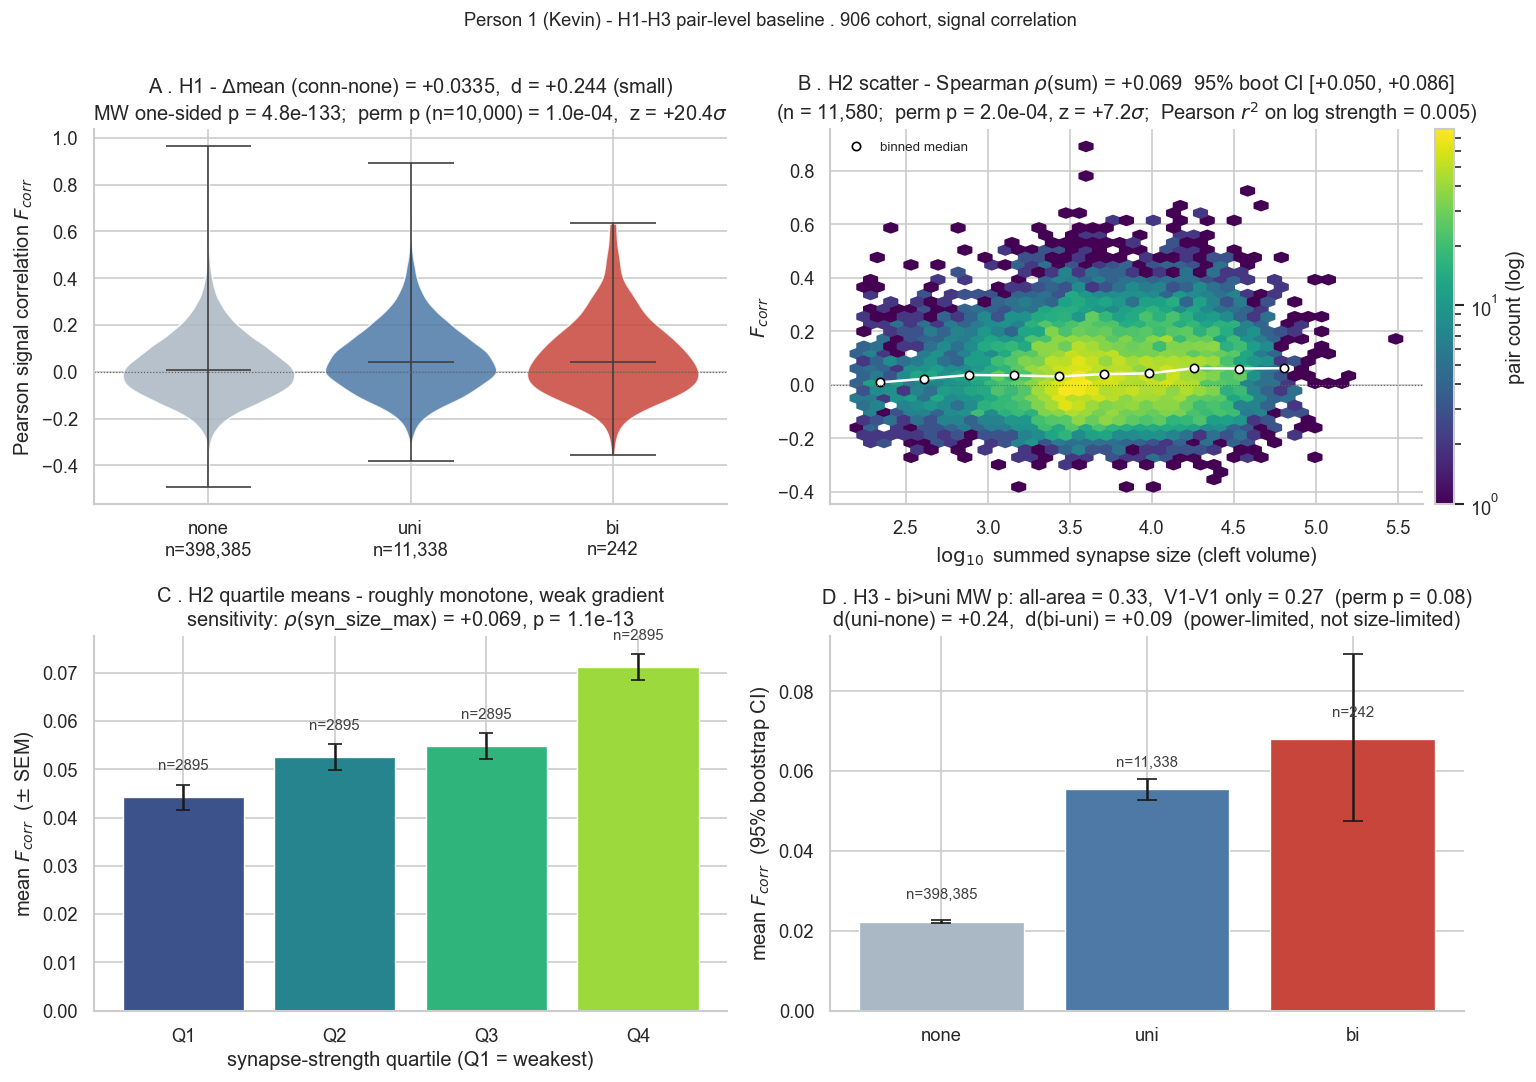

figure saved to: outputs/figures/person1_h1_h3_pair_baseline.png
table saved to : outputs/tables/person1_h1_h3_summary.csv

summary table (one row per hypothesis; NaN = column not applicable to that test):
hypothesis                             description                                 test_direction  n_connected  n_unconnected  mean_diff  median_diff    ci_lo    ci_hi  cohens_d  mannwhitney_U   p_one_sided  perm_n  perm_null_mean  perm_null_std    perm_z  perm_p_one_sided  spearman_rho_sum  spearman_ci_lo  spearman_ci_hi  p_spearman_sum  spearman_rho_max  p_spearman_max  pearson_log10_r  pearson_log10_r2  p_pearson_log10  perm_p_two_sided   n_none   n_uni  n_bi  mean_none  mean_uni  mean_bi  ci_lo_bi  ci_hi_bi  cohens_d_uni_vs_none  cohens_d_bi_vs_uni  p_uni_gt_none  p_bi_gt_none  p_bi_gt_uni  n_v1v1_none  n_v1v1_uni  n_v1v1_bi  mean_v1v1_none  mean_v1v1_uni  mean_v1v1_bi  p_v1v1_uni_gt_none  p_v1v1_bi_gt_none  p_v1v1_bi_gt_uni  cohens_d_v1v1_uni_vs_none  cohens_d_v1v1_bi_vs_uni  pe

,hypothesis,description,test_direction,n_connected,n_unconnected,mean_diff,median_diff,ci_lo,ci_hi,cohens_d,...,p_v1v1_bi_gt_none,p_v1v1_bi_gt_uni,cohens_d_v1v1_uni_vs_none,cohens_d_v1v1_bi_vs_uni,perm_p_uni_gt_none,perm_p_bi_gt_none,perm_p_bi_gt_uni,perm_z_uni_gt_none,perm_z_bi_gt_none,perm_z_bi_gt_uni
0,H1,connected > unconnected (signal F_corr),one-sided (connected > unconnected),11580.0,398385.0,0.033459,0.032575,0.030857,0.036143,0.243701,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,H2,syn_size_sum vs F_corr (connected only),two-sided Spearman,11580.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,H3,reciprocity premium (bi > uni > none),one-sided pairwise (a > b for each comparison),NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001668,0.265711,0.170387,0.087498,0.0002,0.0002,0.083183,20.275985,5.084478,1.412915


In [111]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- (A) H1: violin of f_corr by conn_type ---
ax = axes[0, 0]
data = [f_none, f_uni, f_bi]
parts = ax.violinplot(data, showmeans=False, showmedians=True, widths=0.85)
for k, body in enumerate(parts['bodies']):
    body.set_facecolor(PAL_CONN[ORDER_CONN[k]])
    body.set_edgecolor('white')
    body.set_alpha(0.85)
for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
    parts[key].set_color('0.25')
    parts[key].set_linewidth(1.0)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'none\nn={len(f_none):,}',
                    f'uni\nn={len(f_uni):,}',
                    f'bi\nn={len(f_bi):,}'])
ax.set_ylabel(r'Pearson signal correlation $F_{corr}$')
ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_title(f'A . H1 - $\\Delta$mean (conn-none) = {md_h1:+.4f},  d = {d_h1:+.3f} (small)\n'
             f'MW one-sided p = {p_h1:.1e};  perm p (n={N_PERM:,}) = {p_perm:.1e},  z = {z_obs:+.1f}$\\sigma$')

# --- (B) H2 scatter: hexbin of log10 syn_size_sum vs f_corr (with binned-median overlay) ---
ax = axes[0, 1]
hb = ax.hexbin(conn['log10_size_sum'], conn['f_corr'],
               gridsize=40, mincnt=1, cmap='viridis', bins='log')
xb = np.linspace(conn['log10_size_sum'].min(), conn['log10_size_sum'].max(), 13)
ix = np.digitize(conn['log10_size_sum'].to_numpy(), xb)
xc, yb = [], []
for k in range(1, len(xb)):
    sel = (ix == k)
    if sel.sum() >= 20:
        xc.append(0.5 * (xb[k-1] + xb[k]))
        yb.append(np.median(conn['f_corr'].to_numpy()[sel]))
ax.plot(xc, yb, 'o-', color='white', mec='black', mfc='white', lw=1.5, ms=5,
        label='binned median')
ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_xlabel(r'$\log_{10}$ summed synapse size (cleft volume)')
ax.set_ylabel(r'$F_{corr}$')
ax.set_title(f'B . H2 scatter - Spearman $\\rho$(sum) = {rho_h2:+.3f}  '
             f'95% boot CI [{ci_lo_h2:+.3f}, {ci_hi_h2:+.3f}]\n'
             f'(n = {len(conn):,};  perm p = {p_perm_h2:.1e}, z = {z_obs_h2:+.1f}$\\sigma$;  '
             f'Pearson $r^2$ on log strength = {r2_log:.3f})')
ax.legend(loc='upper left', frameon=False, fontsize=8)
cb = plt.colorbar(hb, ax=ax, fraction=0.045, pad=0.02)
cb.set_label('pair count (log)')

# --- (C) H2 quartile means of f_corr ---
ax = axes[1, 0]
qx = np.arange(4)
ax.bar(qx, q['mean'], yerr=q['sem'],
       color=plt.cm.viridis(np.linspace(0.25, 0.85, 4)),
       edgecolor='white', linewidth=0.8, capsize=4)
for k, (mu, n_) in enumerate(zip(q['mean'], q['count'])):
    ax.text(k, mu + 0.005, f'n={n_}', ha='center', va='bottom', fontsize=9, color='0.25')
ax.set_xticks(qx); ax.set_xticklabels(q.index)
ax.set_ylabel(r'mean $F_{corr}$  ($\pm$ SEM)')
ax.set_xlabel('synapse-strength quartile (Q1 = weakest)')
ax.set_title(f'C . H2 quartile means - roughly monotone, weak gradient\n'
             f'sensitivity: $\\rho$(syn_size_max) = {rho_max:+.3f}, p = {p_rho_max:.1e}')

# --- (D) H3: mean +/- 95% CI by conn_type ---
ax = axes[1, 1]
xs = np.arange(3)
mu_  = [group_stats[g]['mean']  for g in ORDER_CONN]
los_ = [group_stats[g]['ci_lo'] for g in ORDER_CONN]
his_ = [group_stats[g]['ci_hi'] for g in ORDER_CONN]
err_lo = [m - lo for m, lo in zip(mu_, los_)]
err_hi = [hi - m for m, hi in zip(mu_, his_)]
ax.bar(xs, mu_, yerr=[err_lo, err_hi],
       color=[PAL_CONN[g] for g in ORDER_CONN],
       edgecolor='white', linewidth=0.8, capsize=6)
for k, g in enumerate(ORDER_CONN):
    ax.text(k, mu_[k] + 0.005, f'n={group_stats[g]["n"]:,}',
            ha='center', va='bottom', fontsize=9, color='0.25')
ax.set_xticks(xs); ax.set_xticklabels(ORDER_CONN)
ax.set_ylabel(r'mean $F_{corr}$  (95% bootstrap CI)')
ax.set_title(
    f'D . H3 - bi>uni MW p: all-area = {H3_RESULT["p_bi_gt_uni"]:.2f},  '
    f'V1-V1 only = {H3_RESULT["p_v1v1_bi_gt_uni"]:.2f}  '
    f'(perm p = {H3_RESULT["perm_p_bi_gt_uni"]:.2f})\n'
    f'd(uni-none) = {d_uni_none:+.2f},  d(bi-uni) = {d_bi_uni:+.2f}  '
    f'(power-limited, not size-limited)'
)

fig.suptitle('Person 1 (Kevin) - H1-H3 pair-level baseline . 906 cohort, signal correlation',
             y=1.00, fontsize=11)
fig.tight_layout()

fig_path = FIG_DIR / 'person1_h1_h3_pair_baseline.png'
fig.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'figure saved to: {relpath(fig_path)}')

summary = pd.DataFrame([H1_RESULT, H2_RESULT, H3_RESULT])
tbl_path = TBL_DIR / 'person1_h1_h3_summary.csv'
summary.to_csv(tbl_path, index=False)
print(f'table saved to : {relpath(tbl_path)}')
print()
print('summary table (one row per hypothesis; NaN = column not applicable to that test):')
with pd.option_context('display.max_columns', None, 'display.width', 220):
    print(summary.to_string(index=False))
summary


### H3 Conclusion

H3 resolves the connected-versus-unconnected ordering but not a distinct reciprocity premium. The mean ordering is in the expected direction, with bidirectional pairs highest, unidirectional pairs intermediate, and unconnected pairs lowest. The robust result is that connected pairs, whether unidirectional or bidirectional, are above unconnected pairs.

The bidirectional-versus-unidirectional difference is small and is not detected under the tests used here. Reciprocity therefore remains a limited supporting observation rather than a headline result. Restricting the comparison to V1-V1 pairs, which removes the bi-vs-uni area-composition imbalance, gives the same null bi-vs-uni result, so the unresolved reciprocity premium is not explained by where bidirectional pairs sit in the cohort.


# **7. Controls for Distance, Composition, and Orientation**

The previous chapter establishes a baseline pair-level structure-function effect: in the 906-neuron MICrONS proofread-and-functionally-matched cohort, structurally connected pairs of neurons have higher signal correlation than unconnected pairs. That baseline is open to three obvious confounds, each owned in this section.

- **Distance.** Nearby neurons are both more likely to be connected *and* more likely to share visual responses. Does the connected-pair correlation gap survive after we take that geometric confound out?
- **Composition.** V1, RL and AL differ in cell types and laminar makeup. Does the connected-pair correlation gap survive within strata of brain area, layer, and cell type?
- **Orientation tuning.** Like-to-like wiring is classically described in terms of orientation preference, not raw signal correlation. Does orientation similarity carry information beyond `f_corr`?

These three control chapters should not be read as independent discoveries on the same level as the baseline pair-level result. Their job is to test alternative explanations. If the baseline effect shrinks but remains positive after these controls, the correct conclusion is not that the confounds are irrelevant; it is that direct connectivity still carries functional information after accounting for the major known structure in the data — exactly the regime reported by Cossell et al. (2015), Ko et al. (2011), and the MICrONS Consortium (2025).

In [112]:
# 0.5  Tiny shared helpers reused by H4, H5, H6
def boot_mean_diff(a, b, n_boot=4000, seed=0):
    """Bootstrap (mean(a) - mean(b)) with a 95% percentile interval."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    diffs = np.empty(n_boot)
    for k in range(n_boot):
        diffs[k] = rng.choice(a, len(a), replace=True).mean() - rng.choice(b, len(b), replace=True).mean()
    return float(diffs.mean()), tuple(np.percentile(diffs, [2.5, 97.5]))

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std(ddof=0)

# Pre-split f_conn / f_un — used by every H4 panel
f_conn = pairs.loc[ pairs.connected, 'f_corr'].to_numpy()
f_un   = pairs.loc[~pairs.connected, 'f_corr'].to_numpy()

# Container for the final cross-hypothesis summary table
RESULTS = []


## **7.1 Distance Control**

### Theoretical concepts

- *Euclidean soma distance.* $d_{ij} = \lVert \mathbf{x}_i - \mathbf{x}_j \rVert_2$ with $\mathbf{x}_i \in \mathbb{R}^3$ the cortical centroid.
- *Signal correlation* (row-wise Pearson on the response matrix $F \in \mathbb{R}^{N \times M}$):
$$F^{\mathrm{corr}}_{ij} \;=\; \frac{\sum_c (F_{ic}-\bar F_i)(F_{jc}-\bar F_j)}{\sqrt{\sum_c (F_{ic}-\bar F_i)^2 \, \sum_c (F_{jc}-\bar F_j)^2}}.$$
- *Bootstrap mean-difference CI.* Resample $a,b$ with replacement $B$ times; report 2.5/97.5 percentiles of $\bar a^\ast - \bar b^\ast$.
- *Mann-Whitney U* (one-sided, $a > b$). Rank-based; null hypothesis is identical distribution. $U = \sum_{i,j} \mathbf{1}[a_i > b_j]$.
- *Logistic regression* for binary connectivity:
$$\log \frac{p_{ij}}{1-p_{ij}} \;=\; \beta_0 + \beta_1\, F^{\mathrm{corr}}_{ij} + \beta_2\, d_{ij} + \beta_3\, d_{ij}^{\,2}, \qquad p_{ij}=\Pr(\text{connected}_{ij}=1).$$
- *HC0 robust SE* (White sandwich, allows heteroskedasticity):
$$\widehat{\mathrm{Var}}(\hat\beta) \;=\; (X^\top X)^{-1}\, X^\top\,\mathrm{diag}(e_i^{\,2})\, X\, (X^\top X)^{-1}.$$
- *Benjamini-Hochberg FDR.* Sort $p_{(1)}\le\dots\le p_{(m)}$; adjusted $q_k = \min_{r \ge k}\, p_{(r)} \cdot m / r$. Controls expected fraction of false rejections.

---

### **Question**
Cortical connection probability decays steeply with soma-soma distance, and so does signal correlation: nearby neurons see similar pieces of the visual world. The connected-pair correlation gap could therefore be a side-effect of this shared geometry rather than a structure-function relationship per se. **In this chapter we ask whether the connected-pair correlation gap survives once we hold distance fixed.**

### **Tests**
Four complementary panels, each addressing a different failure mode of the others.

- **(a) Distance profile** — bin pairs by distance and plot `P(connected | dist)` and `mean f_corr | dist` together. If both decay together, distance is a real shared driver and any pure connected-vs-unconnected contrast pools across it.
- **(b) Distance matching** — for each connected pair, pick the closest-distance unconnected pair (without replacement, tight tolerance) and rerun the connected-vs-unconnected contrast on this matched control. Robust to functional form because it is non-parametric.
- **(c) Within-distance-bin Mann-Whitney** — repeat the connected-vs-unconnected contrast inside each of five distance quintiles and BH-FDR correct, to make sure the effect is not driven by a single distance regime.
- **(d) Logistic regression / shrinkage** — fit `connected ~ f_corr + dist + dist²` with HC0 robust SEs, and read the partial coefficient on `f_corr` alongside the raw and matched estimates so the shrinkage is visible.

### **Expected outcome**
The connected-vs-unconnected `Δ mean f_corr` should shrink relative to the raw baseline number, but stay positive in the matched test, in the within-bin tests, and as a positive logistic coefficient. That is the conservative reading: distance explains *part* of the baseline gap, not all of it.

In [113]:
# H4 (a) · bin pairs by soma-soma distance and read off the two curves
h4a_edges = np.linspace(pairs.dist_um.min(), pairs.dist_um.max(), 25)
h4a_mids  = 0.5 * (h4a_edges[:-1] + h4a_edges[1:])
h4a_bin   = pairs.groupby(pd.cut(pairs.dist_um, h4a_edges, include_lowest=True), observed=False)
h4a_pconn = h4a_bin.connected.mean().to_numpy()
h4a_fc    = h4a_bin.f_corr.mean().to_numpy()
h4a_n     = h4a_bin.size().to_numpy()

# Pearson correlation between P(conn) and mean F_corr across bins gives a one-line summary
from scipy.stats import pearsonr
r_pf, p_pf = pearsonr(h4a_pconn, h4a_fc)
print(f'across {len(h4a_mids)} distance bins, corr( P(conn), mean F_corr ) = {r_pf:+.3f}  (p = {p_pf:.2e})')
print(f'span: {h4a_edges[0]:.0f} – {h4a_edges[-1]:.0f} µm,   first-bin pairs n={h4a_n[0]:,}')


across 24 distance bins, corr( P(conn), mean F_corr ) = +0.902  (p = 1.74e-09)
span: 6 – 931 µm,   first-bin pairs n=6,058


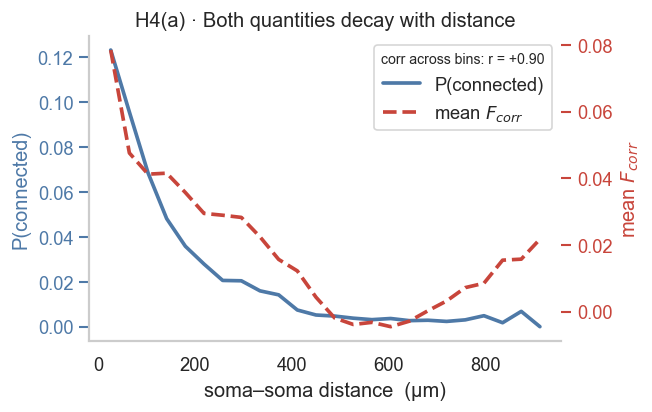

In [114]:
# H4 (a) · twin-axis decay plot
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax2 = ax.twinx()
ax.plot(h4a_mids,  h4a_pconn, lw=2.2, color=PAL_CONN['uni'], label='P(connected)')
ax2.plot(h4a_mids, h4a_fc,    lw=2.2, color=PAL_CONN['bi'], ls='--', label=r'mean $F_{corr}$')
ax.set_xlabel('soma–soma distance  (µm)')
ax.set_ylabel('P(connected)',          color=PAL_CONN['uni'])
ax2.set_ylabel(r'mean $F_{corr}$',     color=PAL_CONN['bi'])
ax.tick_params (axis='y', colors=PAL_CONN['uni'])
ax2.tick_params(axis='y', colors=PAL_CONN['bi'])
ax.grid(False); ax2.grid(False)
ax.set_title('H4(a) · Both quantities decay with distance')
lg = [Line2D([0], [0], color=PAL_CONN['uni'], lw=2.2,             label='P(connected)'),
      Line2D([0], [0], color=PAL_CONN['bi'],  lw=2.2, ls='--',    label=r'mean $F_{corr}$')]
ax.legend(handles=lg, loc='upper right',
          title=fr'corr across bins: r = {r_pf:+.2f}', title_fontsize=8.5)
fig.tight_layout()
fig.savefig(OUT_FIG / 'H4a_distance_profile.png')
plt.show()


In [115]:
# H4 (b) · for each connected pair pick the closest-distance unconnected pair, no replacement
rng        = np.random.default_rng(0)
conn_idx   = pairs.index[ pairs.connected].to_numpy()
un_idx     = pairs.index[~pairs.connected].to_numpy()
un_sorted  = un_idx[np.argsort(pairs.loc[un_idx, 'dist_um'].to_numpy())]
un_d       = pairs.loc[un_sorted, 'dist_um'].to_numpy()
used       = np.zeros(len(un_sorted), dtype=bool)
matched_un = []
for ci in rng.permutation(conn_idx):
    d   = pairs.loc[ci, 'dist_um']
    pos = np.searchsorted(un_d, d)
    best, best_d = None, np.inf
    for off in range(0, 50):
        for k in (pos - off, pos + off):
            if 0 <= k < len(un_sorted) and not used[k]:
                diff = abs(un_d[k] - d)
                if diff < best_d:
                    best, best_d = k, diff
        if best is not None and best_d < 2.0:
            break
    if best is not None:
        used[best] = True
        matched_un.append(un_sorted[best])
matched_un = np.asarray(matched_un)
f_match    = pairs.loc[matched_un, 'f_corr'].to_numpy()

_, p_match         = mannwhitneyu(f_conn, f_match, alternative='greater')
md_match, ci_match = boot_mean_diff(f_conn, f_match, seed=1)
md_raw,   ci_raw   = boot_mean_diff(f_conn, f_un,    seed=2)
print(f'raw            Δmean = {md_raw:+.4f}   CI [{ci_raw[0]:+.4f}, {ci_raw[1]:+.4f}]')
print(f'distance-matched Δmean = {md_match:+.4f}   CI [{ci_match[0]:+.4f}, {ci_match[1]:+.4f}]   p = {p_match:.2e}')
print(f'matched control n   = {len(matched_un):,}  /  connected n = {len(conn_idx):,}')

RESULTS += [
    {'hypothesis': 'H4', 'test': 'raw H1 (no control)',
     'mean_diff': md_raw,   'ci_lo': ci_raw[0],   'ci_hi': ci_raw[1],   'p': float('nan'),
     'note': 'baseline, included for shrinkage comparison'},
    {'hypothesis': 'H4', 'test': 'distance-matched',
     'mean_diff': md_match, 'ci_lo': ci_match[0], 'ci_hi': ci_match[1], 'p': p_match,
     'note': f'n_matched={len(matched_un)}'},
]


raw            Δmean = +0.0334   CI [+0.0308, +0.0361]
distance-matched Δmean = +0.0185   CI [+0.0147, +0.0221]   p = 4.36e-23
matched control n   = 11,580  /  connected n = 11,580


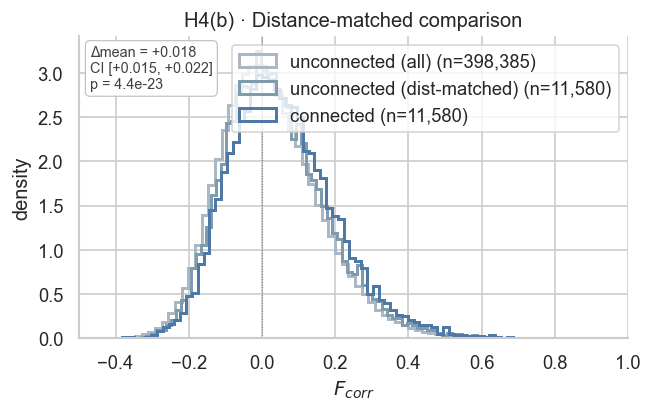

In [116]:
# H4 (b) · histograms of f_corr for three groups
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for label, x, c in [
    ('unconnected (all)',          f_un,    PAL_CONN['none']),
    ('unconnected (dist-matched)', f_match, '#7F9BAE'),
    ('connected',                  f_conn,  PAL_CONN['uni']),
]:
    ax.hist(x, bins=80, density=True, histtype='step', linewidth=1.8,
            color=c, label=f'{label} (n={len(x):,})')
ax.axvline(0, color='0.4', lw=0.6, ls=':')
ax.set_xlabel(r'$F_{corr}$')
ax.set_ylabel('density')
ax.set_xlim(-0.5, 1.0)
ax.set_title('H4(b) · Distance-matched comparison')
ax.text(0.02, 0.97,
        f'Δmean = {md_match:+.3f}\nCI [{ci_match[0]:+.3f}, {ci_match[1]:+.3f}]\np = {p_match:.1e}',
        transform=ax.transAxes, va='top', ha='left', fontsize=8.6, color='0.25',
        bbox=dict(boxstyle='round,pad=0.32', facecolor='white', edgecolor='0.75', lw=0.7))
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUT_FIG / 'H4b_distance_matched.png')
plt.show()


In [117]:
# H4 (c) · split pairs into five distance quintiles, retest H1 inside each, BH-FDR correct
qs = pairs.dist_um.quantile(np.linspace(0, 1, 6)).to_numpy()
labels_q, ds_q, lo_q, hi_q, ps_q, n_c, n_u = [], [], [], [], [], [], []
for k in range(5):
    sel = (pairs.dist_um >= qs[k]) & ((pairs.dist_um < qs[k + 1]) if k < 4 else (pairs.dist_um <= qs[k + 1]))
    sub = pairs[sel]
    a = sub.loc[ sub.connected, 'f_corr'].to_numpy()
    b = sub.loc[~sub.connected, 'f_corr'].to_numpy()
    if len(a) < 5 or len(b) < 5:
        continue
    md_, ci_ = boot_mean_diff(a, b, n_boot=2000, seed=k + 10)
    _, p_    = mannwhitneyu(a, b, alternative='greater')
    labels_q.append(f'Q{k+1}: {qs[k]:.0f}\u2013{qs[k+1]:.0f} µm')
    ds_q.append(md_); lo_q.append(ci_[0]); hi_q.append(ci_[1])
    ps_q.append(p_); n_c.append(len(a)); n_u.append(len(b))
ranked = np.argsort(ps_q)
m      = len(ps_q)
q_adj  = np.empty(m); cur = 1.0
for r in range(m - 1, -1, -1):
    idx = ranked[r]; cur = min(cur, ps_q[idx] * m / (r + 1)); q_adj[idx] = cur

h4c = pd.DataFrame({
    'bin': labels_q, 'n_conn': n_c, 'n_unconn': n_u,
    'mean_diff': ds_q, 'ci_lo': lo_q, 'ci_hi': hi_q, 'p': ps_q, 'q': q_adj,
})
print(h4c.to_string(index=False))
for r in h4c.itertuples():
    RESULTS.append({'hypothesis': 'H4', 'test': f'within-bin {r.bin.split(":")[0]}',
                    'mean_diff': r.mean_diff, 'ci_lo': r.ci_lo, 'ci_hi': r.ci_hi,
                    'p': r.p, 'note': f'BH q={r.q:.1e}; n_conn={r.n_conn}, n_unconn={r.n_unconn}'})


           bin  n_conn  n_unconn  mean_diff    ci_lo    ci_hi            p            q
  Q1: 6–148 µm    6120     75873   0.021437 0.017605 0.025170 8.809004e-27 4.404502e-26
Q2: 148–230 µm    2786     79207   0.015304 0.009886 0.020719 2.466409e-09 4.110682e-09
Q3: 230–332 µm    1684     80309   0.019706 0.013127 0.026418 1.064222e-09 2.660556e-09
Q4: 332–527 µm     739     81254   0.018259 0.008855 0.028088 1.317846e-04 1.317846e-04
Q5: 527–931 µm     251     81742   0.031496 0.015075 0.048277 7.262639e-05 9.078299e-05


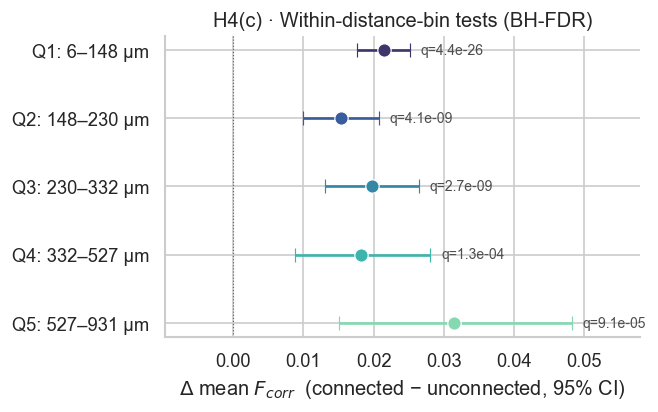

In [118]:
# H4 (c) · forest plot of within-bin Δ mean F_corr
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ypos = np.arange(len(h4c))[::-1]
cols = RAMP_SEQ(np.linspace(0.25, 0.85, len(h4c)))
for y_, r, c_ in zip(ypos, h4c.itertuples(), cols):
    ax.errorbar(r.mean_diff, y_, xerr=[[r.mean_diff - r.ci_lo], [r.ci_hi - r.mean_diff]],
                fmt='o', color=c_, markersize=8, capsize=4, lw=1.6, mec='white', mew=0.7)
    ax.text(r.ci_hi + 0.0015, y_, f'q={r.q:.1e}', va='center', fontsize=8.4, color='0.3')
ax.axvline(0, color='0.4', lw=0.7, ls=':')
ax.set_yticks(ypos); ax.set_yticklabels(h4c.bin)
ax.set_xlabel(r'$\Delta$ mean $F_{corr}$  (connected − unconnected, 95% CI)')
ax.set_title('H4(c) · Within-distance-bin tests (BH-FDR)')
ax.margins(x=0.20)
fig.tight_layout()
fig.savefig(OUT_FIG / 'H4c_within_bin.png')
plt.show()


In [119]:
# H4 (d) · partial logistic regression, connected ~ f_corr + dist + dist²  (HC0 SEs)
Xh4 = np.column_stack([pairs.f_corr.values, pairs.dist_um.values, pairs.dist_um.values ** 2])
Xh4 = sm.add_constant(Xh4)
yh4 = pairs.connected.astype(int).to_numpy()
logit_h4 = sm.Logit(yh4, Xh4).fit(disp=False, cov_type='HC0')
beta_fc, se_fc, p_fc = logit_h4.params[1], logit_h4.bse[1], logit_h4.pvalues[1]
print(f'logistic β(f_corr | dist, dist²) = {beta_fc:+.3f} ± {se_fc:.3f}   p = {p_fc:.2e}')

RESULTS += [{
    'hypothesis': 'H4', 'test': 'logistic β(f_corr | dist, dist²)',
    'mean_diff': beta_fc,  'ci_lo': beta_fc - 1.96 * se_fc, 'ci_hi': beta_fc + 1.96 * se_fc, 'p': p_fc,
    'note': 'connected ~ f_corr + dist + dist², HC0 SE',
}]


logistic β(f_corr | dist, dist²) = +0.905 ± 0.067   p = 4.80e-42


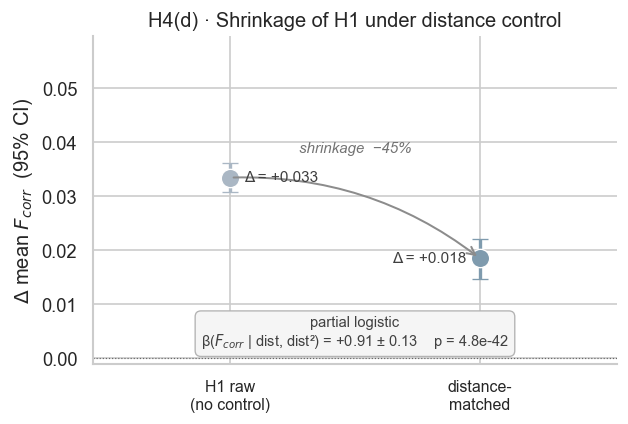

In [120]:
# H4 (d) · two H1 estimates (raw vs distance-matched) + the partial logistic readout
fig, ax = plt.subplots(figsize=(5.4, 3.7))
estimates = [
    ('H1 raw\n(no control)',  md_raw,   ci_raw[0],   ci_raw[1],   PAL_CONN['none']),
    ('distance-\nmatched',    md_match, ci_match[0], ci_match[1], '#7F9BAE'),
]
xpos = np.arange(len(estimates))
for x_, (lbl, m_, lo_, hi_, c_) in zip(xpos, estimates):
    ax.errorbar(x_, m_, yerr=[[m_ - lo_], [hi_ - m_]], fmt='o',
                color=c_, markersize=11, capsize=5, lw=2.0, mec='white', mew=0.8)

# arrow showing the shrinkage between raw and matched, plus a clear annotation
ax.annotate('', xy=(xpos[1], md_match), xytext=(xpos[0], md_raw),
            arrowprops=dict(arrowstyle='->', color='0.55', lw=1.2,
                            connectionstyle='arc3,rad=-0.18'))

# Δ labels — placed to the side of each marker so they don't crash into the cap
ax.annotate(f'Δ = {md_raw:+.3f}',   xy=(xpos[0], md_raw),   xytext=(8, 0),
            textcoords='offset points', va='center', ha='left',
            fontsize=9.2, color='0.25')
ax.annotate(f'Δ = {md_match:+.3f}', xy=(xpos[1], md_match), xytext=(-8, 0),
            textcoords='offset points', va='center', ha='right',
            fontsize=9.2, color='0.25')

# shrinkage label just above the curve apex
ax.text(0.5 * (xpos[0] + xpos[1]),
        max(md_raw, md_match) + 0.0042,
        f'shrinkage  −{(md_raw - md_match) / md_raw:.0%}',
        ha='center', va='bottom', fontsize=9.0, color='0.45',
        fontstyle='italic')

ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_xticks(xpos); ax.set_xticklabels([e[0] for e in estimates], fontsize=9.5)
ax.set_xlim(-0.55, 1.55)
ax.set_ylabel(r'$\Delta$ mean $F_{corr}$  (95% CI)')
ax.set_ylim(-0.001, max(ci_raw[1], ci_match[1]) * 1.65)
ax.set_title('H4(d) · Shrinkage of H1 under distance control')

# Bottom-centre is empty (curve dips toward distance-matched on the right) — anchor box there.
ax.text(0.50, 0.04,
        f'partial logistic\nβ($F_{{corr}}$ | dist, dist²) = {beta_fc:+.2f} ± {1.96 * se_fc:.2f}    p = {p_fc:.1e}',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=8.8, color='0.25',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5', edgecolor='0.7', lw=0.8))
fig.tight_layout()
fig.savefig(OUT_FIG / 'H4d_shrinkage.png')
plt.show()


### **Conclusion**

This section supports the main pair-level claim with an important caveat: distance explains part of the raw baseline gap, but it does not erase it. The connected-versus-unconnected contrast shrinks under distance matching, which is exactly what should happen if geometry is a real confound, but the contrast remains positive across the distance-controlled views.

This should shape the report language. We should not say that direct connectivity is independent of distance in a strong causal sense. The defensible statement is narrower and stronger: even after accounting for the fact that nearby neurons are more likely to be connected and more functionally similar, direct structural connectivity remains associated with higher signal correlation.


## **7.2 Composition Controls**

### Theoretical concepts

- *Stratified contrast.* Rerun the connected-vs-unconnected test on the slice $\{(i,j) : \mathbb{1}_{\text{same X}_{ij}} = v\}$ for $v\in\{0,1\}$ and $X\in\{\text{area, layer, celltype}\}$.
- *Z-score standardisation.* $z(x) = (x - \bar x)/\sigma_x$; lets continuous regressors share a unit-variance scale so $|\beta|$ ranks them directly.
- *Joint logistic regression.*
$$\log\frac{p_{ij}}{1-p_{ij}} \;=\; \beta_0 + \beta_1 z(F^{\mathrm{corr}}_{ij}) + \beta_2 z(d_{ij}) + \beta_3 \mathbb{1}_{\text{same area}} + \beta_4 \mathbb{1}_{\text{same layer}} + \beta_5 \mathbb{1}_{\text{same celltype}}.$$
Each $\beta_k$ is the partial effect of its predictor *holding the others fixed*.
- *HC0 robust SE.* Same sandwich estimator as in the distance chapter; mitigates residual heteroskedasticity.
- *Pair non-independence caveat.* Every neuron appears in $N{-}1$ pair rows, so the effective sample size is below the nominal pair count. HC0 SE does not fix this; treat reported $p$-values as guidance, not confirmatory inference.

---

### **Question**
The 906-neuron cohort spans three brain areas (V1, RL, AL), four cortical layers (L2/3, L4, L5, L6), and several excitatory cell types (e.g. 23P, 4P, 5P-IT, 5P-NP, 5P-PT). Each of those compartments has its own internal connectivity statistics and its own internal response statistics. The baseline effect could be inflated if it just reflects "pairs that share a compartment are both more often connected and more often co-tuned." **In this chapter we ask whether the connected-pair correlation gap survives after we hold compositional identity fixed.**

### **Tests**

- **(a) Stratified retest** — split pairs by `same_area`, `same_layer`, `same_celltype` (each into within-stratum and across-stratum) and run the connected-vs-unconnected contrast inside each split. Six bootstrapped Δ means with 95% CIs and one-sided Mann-Whitney p-values.
- **(b) Joint logistic regression** — fit `connected ~ z(f_corr) + z(dist) + same_area + same_layer + same_celltype` with HC0 robust SEs, so that the partial coefficient on `f_corr` answers the chapter question after distance, area, layer, and cell-type are simultaneously controlled.

**Note on independence.** Pairs are not independent: any neuron appears in 905 of them, so the SE returned by the regression underestimates the true SE. We use HC0 robust SEs as a partial mitigation but treat the resulting p-values as guidance, not as confirmatory inference.

### **Expected outcome**
Within-stratum and across-stratum effects should both stay positive and significant; in the joint logistic, the standardised coefficient on `f_corr` should remain well above zero and comparable in magnitude to the categorical compositional terms.

In [121]:
# H5 (a) · stratified bootstrap + Mann-Whitney for each (feature, value) bucket
strat_rows = []
for col in ['same_area', 'same_layer', 'same_celltype']:
    for v in [True, False]:
        sub = pairs[pairs[col] == v]
        a = sub.loc[ sub.connected, 'f_corr'].to_numpy()
        b = sub.loc[~sub.connected, 'f_corr'].to_numpy()
        if len(a) < 5 or len(b) < 5:
            continue
        md_, ci_ = boot_mean_diff(a, b, n_boot=2000, seed=hash((col, v)) & 0xffff)
        _, p_   = mannwhitneyu(a, b, alternative='greater')
        strat_rows.append({'feature': col, 'value': v,
                           'n_conn': len(a), 'n_unconn': len(b),
                           'mean_diff': md_, 'ci_lo': ci_[0], 'ci_hi': ci_[1], 'p': p_})
strat = pd.DataFrame(strat_rows)
print(strat.to_string(index=False))
for r in strat.itertuples():
    RESULTS.append({
        'hypothesis': 'H5', 'test': f'stratum {r.feature}={r.value}',
        'mean_diff': r.mean_diff, 'ci_lo': r.ci_lo, 'ci_hi': r.ci_hi, 'p': r.p,
        'note': f'n_conn={r.n_conn}, n_unconn={r.n_unconn}',
    })


      feature  value  n_conn  n_unconn  mean_diff    ci_lo    ci_hi            p
    same_area   True   10844    262705   0.023321 0.020574 0.026083 2.299866e-59
    same_area  False     736    135680   0.047721 0.037041 0.058132 5.259409e-20
   same_layer   True    4929    129295   0.034230 0.029980 0.038421 6.971655e-54
   same_layer  False    6651    269090   0.030453 0.026975 0.034064 6.975206e-71
same_celltype   True    4993    129731   0.032937 0.028829 0.036892 5.497337e-53
same_celltype  False    6587    268654   0.031015 0.027559 0.034572 3.269075e-70


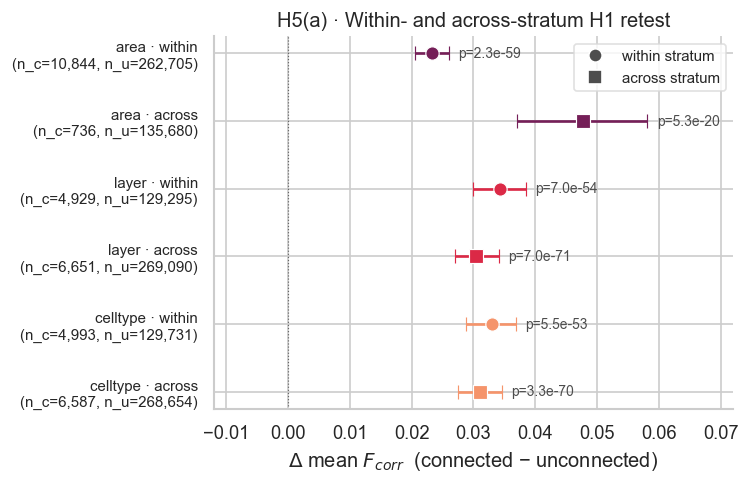

In [122]:
# H5 (a) · forest plot — colour by feature, marker by within (●) / across (■)
feat_colors = {
    'same_area':     RAMP_FORE(0.30),
    'same_layer':    RAMP_FORE(0.55),
    'same_celltype': RAMP_FORE(0.78),
}
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ypos    = np.arange(len(strat))[::-1]
ylabels = []
for y_, r in zip(ypos, strat.itertuples()):
    feat_short = r.feature.replace('same_', '')
    where      = 'within' if r.value else 'across'
    marker     = 'o' if r.value else 's'
    color      = feat_colors[r.feature]
    ax.errorbar(r.mean_diff, y_,
                xerr=[[r.mean_diff - r.ci_lo], [r.ci_hi - r.mean_diff]],
                fmt=marker, color=color, markersize=8, capsize=4, lw=1.6,
                mec='white', mew=0.7)
    ax.text(r.ci_hi + 0.0015, y_, f'p={r.p:.1e}', va='center', fontsize=8.3, color='0.3')
    ylabels.append(f'{feat_short} · {where}\n(n_c={r.n_conn:,}, n_u={r.n_unconn:,})')
ax.axvline(0, color='0.4', lw=0.7, ls=':')
ax.set_yticks(ypos); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel(r'$\Delta$ mean $F_{corr}$  (connected − unconnected)')
ax.set_title('H5(a) · Within- and across-stratum H1 retest')

# Generous left margin so labels fit, and a touch of right margin so p-values + legend
# coexist without overlap. The marker-shape legend lives in the bottom-right corner —
# the celltype-across point sits near x=0.03 with its p-value text at x≈0.045, so the
# region (x>0.058) is comfortably empty.
ax.set_xlim(-0.012, 0.072)
lg_h = [Line2D([0], [0], marker='o', color='w', markerfacecolor='0.3', markersize=8, label='within stratum'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='0.3', markersize=8, label='across stratum')]
ax.legend(handles=lg_h, loc='upper right', frameon=True,
          facecolor='white', edgecolor='0.85', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_FIG / 'H5a_stratified.png')
plt.show()


In [123]:
# H5 (b) · joint logistic — z-score continuous regressors, keep categoricals as 0/1
Xj = pd.DataFrame({
    'f_corr':        zscore(pairs.f_corr.values),
    'dist_um':       zscore(pairs.dist_um.values),
    'same_area':     pairs.same_area.astype(int).values,
    'same_layer':    pairs.same_layer.astype(int).values,
    'same_celltype': pairs.same_celltype.astype(int).values,
})
Xj    = sm.add_constant(Xj)
yj    = pairs.connected.astype(int).to_numpy()
joint = sm.Logit(yj, Xj).fit(disp=False, cov_type='HC0')
print(joint.summary().tables[1])

RESULTS += [{
    'hypothesis': 'H5', 'test': 'joint logistic β(f_corr | dist, area, layer, celltype)',
    'mean_diff': float(joint.params['f_corr']),
    'ci_lo':     float(joint.params['f_corr'] - 1.96 * joint.bse['f_corr']),
    'ci_hi':     float(joint.params['f_corr'] + 1.96 * joint.bse['f_corr']),
    'p':         float(joint.pvalues['f_corr']),
    'note':      'standardised continuous; HC0 SE',
}]


                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.2989      0.038   -114.555      0.000      -4.372      -4.225
f_corr            0.1296      0.009     14.107      0.000       0.112       0.148
dist_um          -1.3134      0.023    -58.224      0.000      -1.358      -1.269
same_area         0.1884      0.042      4.509      0.000       0.107       0.270
same_layer       -0.0853      0.036     -2.394      0.017      -0.155      -0.015
same_celltype     0.0041      0.035      0.117      0.906      -0.065       0.073


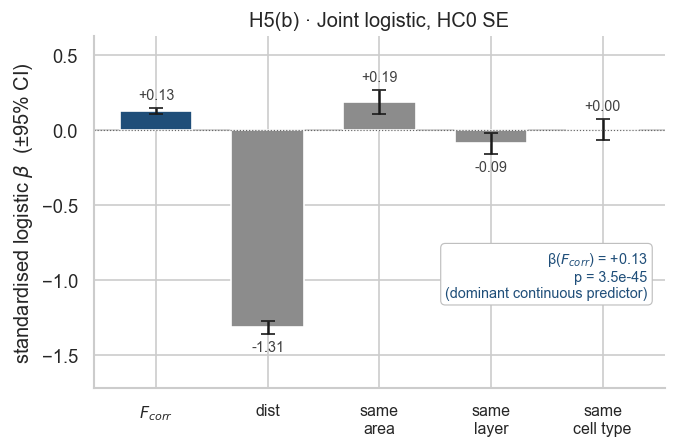

In [124]:
# H5 (b) · standardised coefficient bar chart, with f_corr highlighted
fig, ax = plt.subplots(figsize=(5.8, 3.9))
names = [r'$F_{corr}$', 'dist', 'same\narea', 'same\nlayer', 'same\ncell type']
keys  = ['f_corr', 'dist_um', 'same_area', 'same_layer', 'same_celltype']
betas = np.array([joint.params[k] for k in keys])
ses   = np.array([joint.bse[k]    for k in keys])
bar_c = ['#1F4E79' if k == 'f_corr' else '0.55' for k in keys]
ax.bar(np.arange(len(names)), betas, yerr=1.96 * ses,
       color=bar_c, edgecolor='white', capsize=4, width=0.65)
ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_xticks(np.arange(len(names))); ax.set_xticklabels(names, fontsize=9.5)
ax.set_ylabel(r'standardised logistic $\beta$  (±95% CI)')
ax.set_title('H5(b) · Joint logistic, HC0 SE')
yspan = (betas + 1.96 * ses).max() - (betas - 1.96 * ses).min()
pad   = 0.025 * yspan
for x, b_, s_ in zip(np.arange(len(names)), betas, ses):
    ytxt, va = (b_ + 1.96 * s_ + pad, 'bottom') if b_ >= 0 else (b_ - 1.96 * s_ - pad, 'top')
    ax.text(x, ytxt, f'{b_:+.2f}', ha='center', va=va, fontsize=8.6, color='0.25')
ax.margins(y=0.22)

# Empty quadrant: only the dist bar is deeply negative, so the lower-right region —
# below the small same_area / same_layer / same_celltype bars and above the dist trough
# — is comfortably empty. Anchor the readout there.
ax.text(0.97, 0.32,
        f'β($F_{{corr}}$) = {joint.params["f_corr"]:+.2f}\n'
        f'p = {joint.pvalues["f_corr"]:.1e}\n'
        f'(dominant continuous predictor)',
        transform=ax.transAxes, va='center', ha='right', fontsize=8.6, color='#1F4E79',
        bbox=dict(boxstyle='round,pad=0.32', facecolor='white', edgecolor='0.75', lw=0.7))
fig.tight_layout()
fig.savefig(OUT_FIG / 'H5b_joint_logistic.png')
plt.show()


### **Conclusion**

These results support the robustness of the baseline connected-pair effect. The connected-pair effect remains positive within the coarse composition splits and in the joint model that includes distance plus area, layer, and cell-type indicators. That makes it unlikely that the baseline result is only a trivial consequence of comparing same-area or same-class pairs against mixed pairs.

The result should still be described carefully. Area, layer, and cell-type labels are coarse, and pair rows remain statistically dependent because neurons appear in many pairs. These controls strengthen the baseline interpretation, but they do not prove that every possible anatomical or transcriptional covariate has been controlled.


## **7.3 Orientation Similarity**

### **Theoretical concepts**

- *Orientation similarity* ($\pi$-periodic, since orientation $\theta$ is defined modulo $180^\circ$):
$$\mathrm{ori\_sim}_{ij} \;=\; \cos\!\big(2\,(\theta_i - \theta_j)\big) \;\in\; [-1, +1].$$
$+1$ = identical preferred orientation, $-1$ = orthogonal.
- *Global orientation selectivity* (vector-strength form):
$$\mathrm{gOSI}_i \;=\; \frac{\big|\sum_k r_{ik}\, e^{\,i\,2\theta_k}\big|}{\sum_k r_{ik}}, \qquad \mathrm{gOSI}_i \in [0,1],$$
with $r_{ik}$ neuron $i$'s response to a drifting grating at orientation $\theta_k$. We keep only pairs with $\min(\mathrm{gOSI}_i, \mathrm{gOSI}_j) > 0.10$ so $\theta_i$ is meaningful.
- *Joint logistic regression* on the well-tuned subset:
$$\log\frac{p_{ij}}{1-p_{ij}} \;=\; \beta_0 + \beta_1 z(F^{\mathrm{corr}}_{ij}) + \beta_2 z(\mathrm{ori\_sim}_{ij}) + \beta_3 z(d_{ij}).$$
Comparing $|\beta_1|$ to $|\beta_2|$ tells us whether `ori_sim` carries information about connectivity *beyond* what `f_corr` already provides.
- *Bootstrap CI + one-sided Mann-Whitney* as in the distance chapter.

---

### **Question**

Like-to-like wiring in mouse V1 is classically described in terms of orientation preference, not arbitrary stimulus correlation. So `f_corr` and `ori_sim` could be near-substitutes — both metrics could mostly track the same latent feature-tuning axis. **In this chapter we ask whether orientation similarity carries information about connectivity *beyond* what `f_corr` already provides, and vice versa.**

### **Tests**

- **(a) Marginal contrast** — restrict to well-tuned pairs (`gOSI_min > 0.10`) and compare connected vs unconnected `ori_sim` (bootstrap CI + one-sided Mann-Whitney). Without a tuning floor, `pref_ori` is meaningless for low-gOSI cells and `ori_sim` becomes noise around zero.
- **(b) Joint logistic regression** — on the same well-tuned subset fit `connected ~ z(f_corr) + z(ori_sim) + z(dist)` with HC0 SEs. The standardised coefficients tell us which feature carries weight given the others.

### **Expected outcome**

`ori_sim` should be higher in connected pairs than unconnected, and the standardised coefficients on both `f_corr` and `ori_sim` should be positive. In the published V1 L2/3 literature `f_corr` typically carries the more stable signal, while `ori_sim` adds a moderate amount on top.


In [125]:
# H6 (a) · marginal Δ ori_sim on the well-tuned subset
GOSI_MIN = 0.10
sub = pairs.dropna(subset=['ori_sim']).copy()
sub = sub[sub.gOSI_min > GOSI_MIN]
print(f'well-tuned pairs (gOSI_min > {GOSI_MIN}): {len(sub):,}  ({len(sub)/len(pairs):.1%} of all pairs)')

a_o = sub.loc[ sub.connected, 'ori_sim'].to_numpy()
b_o = sub.loc[~sub.connected, 'ori_sim'].to_numpy()
_, p_o     = mannwhitneyu(a_o, b_o, alternative='greater')
md_o, ci_o = boot_mean_diff(a_o, b_o, n_boot=4000, seed=1)
print(f'ori_sim  Δmean = {md_o:+.4f}   CI [{ci_o[0]:+.4f}, {ci_o[1]:+.4f}]   p = {p_o:.2e}')
print(f'  connected  : n={len(a_o):,}, mean ori_sim = {a_o.mean():+.4f}')
print(f'  unconnected: n={len(b_o):,}, mean ori_sim = {b_o.mean():+.4f}')

RESULTS += [{
    'hypothesis': 'H6', 'test': 'marginal Δ ori_sim (connected − unconnected)',
    'mean_diff': md_o, 'ci_lo': ci_o[0], 'ci_hi': ci_o[1], 'p': p_o,
    'note': f'gOSI_min > {GOSI_MIN};  n_conn={len(a_o)}, n_unconn={len(b_o)}',
}]


well-tuned pairs (gOSI_min > 0.1): 320,400  (78.2% of all pairs)
ori_sim  Δmean = +0.0543   CI [+0.0389, +0.0702]   p = 3.75e-13
  connected  : n=9,071, mean ori_sim = +0.0878
  unconnected: n=311,329, mean ori_sim = +0.0334


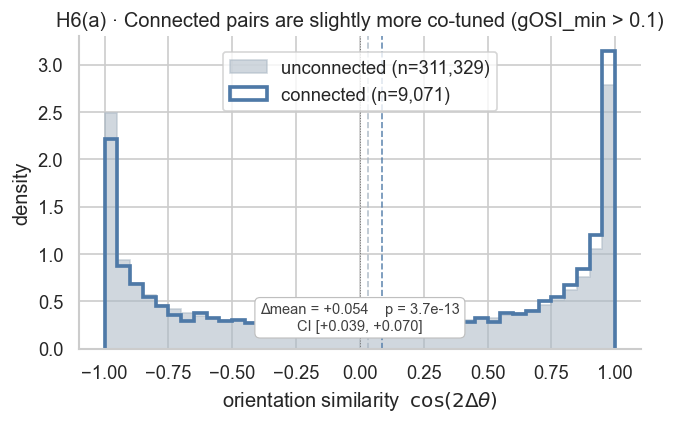

In [126]:
# H6 (a) · ori_sim distribution by connection status (filled unconnected, stepped connected)
fig, ax = plt.subplots(figsize=(5.6, 3.7))
bins = np.linspace(-1.0, 1.0, 41)
ax.hist(b_o, bins=bins, density=True, histtype='stepfilled',
        color=PAL_CONN['none'], alpha=0.55, edgecolor=PAL_CONN['none'],
        label=f'unconnected (n={len(b_o):,})')
ax.hist(a_o, bins=bins, density=True, histtype='step', linewidth=2.2,
        color=PAL_CONN['uni'], label=f'connected (n={len(a_o):,})')
ax.axvline(b_o.mean(), color=PAL_CONN['none'], lw=1.0, ls='--', alpha=0.85)
ax.axvline(a_o.mean(), color=PAL_CONN['uni'],  lw=1.0, ls='--', alpha=0.85)
ax.axvline(0,           color='0.45', lw=0.6, ls=':')
ax.set_xlabel(r'orientation similarity  $\cos(2\Delta\theta)$')
ax.set_ylabel('density')
ax.set_title(f'H6(a) · Connected pairs are slightly more co-tuned (gOSI_min > {GOSI_MIN})')
# Bottom centre is empty in this U-shaped distribution — perfect spot for the stats box.
ax.text(0.50, 0.05,
        f'Δmean = {md_o:+.3f}    p = {p_o:.1e}\nCI [{ci_o[0]:+.3f}, {ci_o[1]:+.3f}]',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=8.8, color='0.25',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.75', lw=0.7))
ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(0.50, 0.98))
fig.tight_layout()
fig.savefig(OUT_FIG / 'H6a_ori_sim_dist.png')
plt.show()


In [127]:
# H6 (b) · joint logistic on the well-tuned subset
Xs = pd.DataFrame({
    'f_corr':  zscore(sub.f_corr.values),
    'ori_sim': zscore(sub.ori_sim.values),
    'dist_um': zscore(sub.dist_um.values),
})
Xs = sm.add_constant(Xs)
ys = sub.connected.astype(int).to_numpy()
m6 = sm.Logit(ys, Xs).fit(disp=False, cov_type='HC0')
print(m6.summary().tables[1])

RESULTS += [
    {'hypothesis': 'H6', 'test': 'joint logistic β(f_corr | ori_sim, dist)',
     'mean_diff': float(m6.params['f_corr']),
     'ci_lo':     float(m6.params['f_corr'] - 1.96 * m6.bse['f_corr']),
     'ci_hi':     float(m6.params['f_corr'] + 1.96 * m6.bse['f_corr']),
     'p':         float(m6.pvalues['f_corr']),
     'note':      'standardised; well-tuned subset'},
    {'hypothesis': 'H6', 'test': 'joint logistic β(ori_sim | f_corr, dist)',
     'mean_diff': float(m6.params['ori_sim']),
     'ci_lo':     float(m6.params['ori_sim'] - 1.96 * m6.bse['ori_sim']),
     'ci_hi':     float(m6.params['ori_sim'] + 1.96 * m6.bse['ori_sim']),
     'p':         float(m6.pvalues['ori_sim']),
     'note':      'standardised; well-tuned subset'},
]


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.1781      0.020   -209.642      0.000      -4.217      -4.139
f_corr         0.1217      0.010     11.724      0.000       0.101       0.142
ori_sim        0.0353      0.011      3.253      0.001       0.014       0.057
dist_um       -1.3440      0.022    -62.493      0.000      -1.386      -1.302


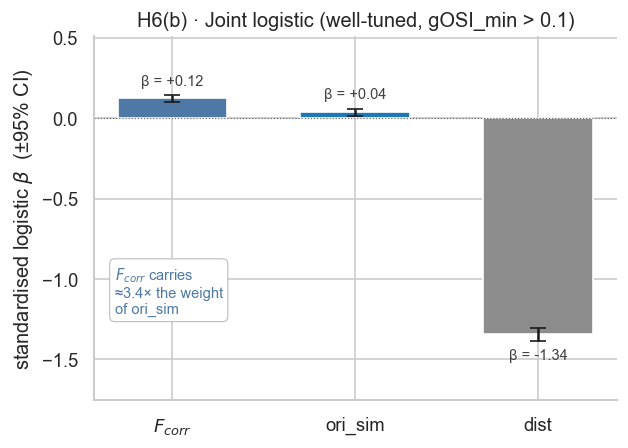

In [128]:
# H6 (b) · standardised coefficient bar chart
fig, ax = plt.subplots(figsize=(5.4, 3.9))
names = [r'$F_{corr}$', 'ori_sim', 'dist']
keys  = ['f_corr', 'ori_sim', 'dist_um']
betas = np.array([m6.params[k] for k in keys])
ses   = np.array([m6.bse[k]    for k in keys])
bar_c = [PAL_CONN['uni'], '#1F77B4', '0.55']
ax.bar(np.arange(3), betas, yerr=1.96 * ses,
       color=bar_c, edgecolor='white', capsize=5, width=0.6)
ax.axhline(0, color='0.4', lw=0.7, ls=':')
ax.set_xticks(np.arange(3)); ax.set_xticklabels(names)
ax.set_ylabel(r'standardised logistic $\beta$  (±95% CI)')
ax.set_title(f'H6(b) · Joint logistic (well-tuned, gOSI_min > {GOSI_MIN})')
yspan = (betas + 1.96 * ses).max() - (betas - 1.96 * ses).min()
pad   = 0.030 * yspan
for x, b_, s_ in zip(np.arange(3), betas, ses):
    ytxt, va = (b_ + 1.96 * s_ + pad, 'bottom') if b_ >= 0 else (b_ - 1.96 * s_ - pad, 'top')
    ax.text(x, ytxt, f'β = {b_:+.2f}', ha='center', va=va, fontsize=8.8, color='0.25')
ax.margins(y=0.24)

# Big empty quadrant: below the F_corr / ori_sim bars (both small) and to the LEFT of
# the dist trough. Lower-left of the axes is clean.
ratio = betas[0] / betas[1] if betas[1] != 0 else float('inf')
ax.text(0.04, 0.30,
        f'$F_{{corr}}$ carries\n≈{ratio:.1f}× the weight\nof ori_sim',
        transform=ax.transAxes, va='center', ha='left', fontsize=8.8, color=PAL_CONN['uni'],
        bbox=dict(boxstyle='round,pad=0.34', facecolor='white', edgecolor='0.75', lw=0.7))
fig.tight_layout()
fig.savefig(OUT_FIG / 'H6b_joint_logistic.png')
plt.show()


In [129]:
summary = pd.DataFrame(RESULTS)[['hypothesis', 'test', 'mean_diff', 'ci_lo', 'ci_hi', 'p', 'note']]
summary.to_csv(OUT_TBL / 'person2_h4_h6_controls_summary.csv', index=False)
print(f'saved -> {relpath(OUT_TBL / "person2_h4_h6_controls_summary.csv")}')
summary


saved -> outputs/tables/person2_h4_h6_controls_summary.csv


,hypothesis,test,mean_diff,ci_lo,ci_hi,p,note
0,H4,raw H1 (no control),0.033421,0.030847,0.036107,NaN,"baseline, included for shrinkage comparison"
1,H4,distance-matched,0.018499,0.014696,0.022134,4.357941e-23,n_matched=11580
2,H4,within-bin Q1,0.021437,0.017605,0.025170,8.809004e-27,"BH q=4.4e-26; n_conn=6120, n_unconn=75873"
3,H4,within-bin Q2,0.015304,0.009886,0.020719,2.466409e-09,"BH q=4.1e-09; n_conn=2786, n_unconn=79207"
4,H4,within-bin Q3,0.019706,0.013127,0.026418,1.064222e-09,"BH q=2.7e-09; n_conn=1684, n_unconn=80309"
5,H4,within-bin Q4,0.018259,0.008855,0.028088,1.317846e-04,"BH q=1.3e-04; n_conn=739, n_unconn=81254"
6,H4,within-bin Q5,0.031496,0.015075,0.048277,7.262639e-05,"BH q=9.1e-05; n_conn=251, n_unconn=81742"
7,H4,"logistic β(f_corr | dist, dist²)",0.905034,0.774475,1.035594,4.803750e-42,"connected ~ f_corr + dist + dist², HC0 SE"
8,H5,stratum same_area=True,0.023321,0.020574,0.026083,2.299866e-59,"n_conn=10844, n_unconn=262705"
9,H5,stratum same_area=False,0.047721,0.037041,0.058132,5.259409e-20,"n_conn=736, n_unconn=135680"


### **Conclusion**

These results support a layered interpretation. Connected pairs are slightly more orientation-similar among well-tuned neurons, which is consistent with like-to-like wiring in visual cortex. However, signal correlation remains the stronger predictor when orientation similarity and distance are modeled together.

The best interpretation is that orientation preference captures one specific tuning axis inside a broader response-similarity relationship. Orientation similarity contributes useful biological context, but it does not replace the functional correlation result. For the report, this section should be used to say that the baseline connected-pair effect is not merely an orientation-tuning artifact, while still acknowledging that tuning similarity is part of the structure-function story.


## 8. Network Analysis and Topology Comparison, Including H7

The assignment asks not only whether directly connected neurons are correlated, but also whether the structural and functional networks have similar topology. This is a harder comparison because the two networks have different mathematical forms: the structural graph is sparse, directed, and synapse-weighted, while the functional matrix is dense, symmetric, and signed.

H7 handles the most interpretable topology comparison: node centrality. If the networks have similar topology, neurons that are structural hubs would also be functionally coupled to many other neurons or have high mean functional association with the cohort. This section therefore computes structural degree and strength, functional hub metrics, partial rank correlations, and thresholded graph sensitivities.


In [130]:
def mean_pairwise_distance_um(xyz):
    dist = np.linalg.norm(xyz[:, None, :] - xyz[None, :, :], axis=2)
    np.fill_diagonal(dist, np.nan)
    return np.nanmean(dist, axis=1)

xyz = matched[['pt_position_x', 'pt_position_y', 'pt_position_z']].to_numpy(dtype=float)
mean_dist_um = mean_pairwise_distance_um(xyz)

F_corr_no_diag = F_corr.copy()
np.fill_diagonal(F_corr_no_diag, np.nan)

mean_fcorr_signed = np.nanmean(F_corr_no_diag, axis=1)
mean_fcorr_pos_clipped = np.nanmean(np.clip(F_corr_no_diag, 0, None), axis=1)
mean_fcorr_abs = np.nanmean(np.abs(F_corr_no_diag), axis=1)

iu_all, ju_all = np.triu_indices(N, k=1)
pair_dist = np.linalg.norm(xyz[iu_all] - xyz[ju_all], axis=1)
pair_fc = F_corr_no_diag[iu_all, ju_all]
pair_mask = np.isfinite(pair_fc) & valid[iu_all] & valid[ju_all]
d_z = (pair_dist[pair_mask] - pair_dist[pair_mask].mean()) / pair_dist[pair_mask].std(ddof=0)
X_pair = np.column_stack([np.ones(d_z.size), d_z, d_z ** 2])
beta_pair = np.linalg.lstsq(X_pair, pair_fc[pair_mask], rcond=None)[0]
pair_resid = pair_fc[pair_mask] - X_pair @ beta_pair
F_corr_pairdist_resid = np.full((N, N), np.nan, dtype=float)
ii, jj = iu_all[pair_mask], ju_all[pair_mask]
F_corr_pairdist_resid[ii, jj] = pair_resid
F_corr_pairdist_resid[jj, ii] = pair_resid
mean_fcorr_pairdist_resid = np.nanmean(F_corr_pairdist_resid, axis=1)
print(f'pairwise distance residual model: F_corr ~ dist + dist^2, n_pairs={pair_mask.sum():,}')

area_arr = matched.brain_area.to_numpy()
mean_fcorr_same_area = np.full(N, np.nan, dtype=float)
mean_dist_same_area = np.full(N, np.nan, dtype=float)
dist_matrix = np.linalg.norm(xyz[:, None, :] - xyz[None, :, :], axis=2)
np.fill_diagonal(dist_matrix, np.nan)
for i in range(N):
    same = area_arr == area_arr[i]
    same[i] = False
    mean_fcorr_same_area[i] = np.nanmean(F_corr_no_diag[i, same])
    mean_dist_same_area[i] = np.nanmean(dist_matrix[i, same])

rho_resid_dist, p_resid_dist = spearmanr(mean_fcorr_pairdist_resid, mean_dist_um, nan_policy='omit')
print(f'sanity: mean pair-distance residual still correlates with mean distance: rho={rho_resid_dist:+.3f}, p={p_resid_dist:.2e}')
if np.isfinite(rho_resid_dist) and abs(rho_resid_dist) > 0.10:
    print('diagnostic warning: node-averaged pair-distance residuals still carry distance structure; treat this as an incomplete distance-control check.')

hub_metrics = pd.DataFrame({
    'matrix_index': np.arange(N),
    'pt_root_id': matched.pt_root_id.values,
    'brain_area': matched.brain_area.values,
    'layer': matched.layer.values,
    'cell_type': matched.cell_type.values,
    'valid_function': valid,
    'x_um': matched.pt_position_x.values,
    'y_um': matched.pt_position_y.values,
    'z_um': matched.pt_position_z.values,
    'mean_dist_um': mean_dist_um,
    'out_degree': np.asarray(A_struct.sum(axis=1)).ravel().astype(float),
    'in_degree': np.asarray(A_struct.sum(axis=0)).ravel().astype(float),
    'out_strength': np.asarray(C_strength.sum(axis=1)).ravel(),
    'in_strength': np.asarray(C_strength.sum(axis=0)).ravel(),
    'mean_fcorr_signed': mean_fcorr_signed,
    'mean_fcorr_pos_clipped': mean_fcorr_pos_clipped,
    'mean_fcorr_abs': mean_fcorr_abs,
    'mean_fcorr_pairdist_resid': mean_fcorr_pairdist_resid,
    'mean_fcorr_same_area': mean_fcorr_same_area,
    'mean_dist_same_area': mean_dist_same_area,
})

hub_metrics['total_degree'] = hub_metrics.out_degree + hub_metrics.in_degree
hub_metrics['total_strength'] = hub_metrics.out_strength + hub_metrics.in_strength

out_metrics = OUT_TBL / 'h7_hub_metrics.csv'
hub_metrics.to_csv(out_metrics, index=False)
print(f'saved: {relpath(out_metrics)}')
hub_metrics.describe(include='all').T.loc[
    ['total_degree', 'total_strength', 'mean_fcorr_signed', 'mean_fcorr_pairdist_resid', 'mean_fcorr_same_area', 'mean_dist_um'],
    ['count', 'mean', 'std', 'min', '50%', 'max']
]


pairwise distance residual model: F_corr ~ dist + dist^2, n_pairs=409,965
sanity: mean pair-distance residual still correlates with mean distance: rho=+0.218, p=3.54e-11
diagnostic warning: node-averaged pair-distance residuals still carry distance structure; treat this as an incomplete distance-control check.
saved: outputs/tables/h7_hub_metrics.csv


,count,mean,std,min,50%,max
total_degree,906.0,26.09713,17.677012,1.0,23.0,107.0
total_strength,906.0,242825.969095,202583.633828,2644.0,192454.0,1590828.0
mean_fcorr_signed,906.0,0.023201,0.022913,-0.053065,0.025378,0.080423
mean_fcorr_pairdist_resid,906.0,0.0,0.022896,-0.074837,0.002351,0.060709
mean_fcorr_same_area,906.0,0.04353,0.045028,-0.061515,0.038815,0.269021
mean_dist_um,906.0,325.103146,93.876598,229.201547,288.137152,618.13498


In [131]:
def _control_matrix(control_df):
    if control_df is None or control_df.shape[1] == 0:
        return np.empty((0, 0))

    parts = []
    for col in control_df.columns:
        s = control_df[col]
        if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_bool_dtype(s):
            values = s.astype(float).to_numpy()
            if pd.Series(values).nunique(dropna=True) > 2:
                values = stats.rankdata(values)
            parts.append(values)
        else:
            dummies = pd.get_dummies(s, prefix=col, drop_first=True, dtype=float)
            for dcol in dummies.columns:
                parts.append(dummies[dcol].to_numpy(dtype=float))

    if not parts:
        return np.empty((len(control_df), 0))
    Z = np.column_stack(parts)
    keep = np.nanstd(Z, axis=0) > 0
    return Z[:, keep]


def partial_spearman(x, y, control_df=None):
    base = pd.DataFrame({'x': x, 'y': y}).reset_index(drop=True)
    if control_df is not None and control_df.shape[1] > 0:
        controls = control_df.reset_index(drop=True)
        base = pd.concat([base, controls], axis=1)
    mask = base.notna().all(axis=1).to_numpy()
    base = base.loc[mask].reset_index(drop=True)

    rx = stats.rankdata(base['x'].to_numpy(dtype=float))
    ry = stats.rankdata(base['y'].to_numpy(dtype=float))

    if control_df is None or control_df.shape[1] == 0:
        r, p = pearsonr(rx, ry)
        return r, p, len(base)

    Z = _control_matrix(base.drop(columns=['x', 'y']))
    if Z.shape[1] == 0:
        r, p = pearsonr(rx, ry)
        return r, p, len(base)

    Z = (Z - Z.mean(axis=0)) / Z.std(axis=0, ddof=0)
    X = np.column_stack([np.ones(len(base)), Z])
    bx = np.linalg.lstsq(X, rx, rcond=None)[0]
    by = np.linalg.lstsq(X, ry, rcond=None)[0]
    ex = rx - X @ bx
    ey = ry - X @ by
    r, p = pearsonr(ex, ey)
    return r, p, len(base)


def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    mask = np.isfinite(p)
    if not mask.any():
        return q
    pv = p[mask]
    order = np.argsort(pv)
    ranked = pv[order] * len(pv) / np.arange(1, len(pv) + 1)
    adjusted = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty_like(pv)
    out[order] = np.minimum(adjusted, 1.0)
    q[mask] = out
    return q


def h7_corr(df, smetric, fmetric, controls):
    sub = df[df.valid_function].copy()
    if controls == 'raw':
        mask = sub[[smetric, fmetric]].notna().all(axis=1)
        rho, p = spearmanr(sub.loc[mask, smetric], sub.loc[mask, fmetric])
        return float(rho), float(p), int(mask.sum())
    control_sets = {
        'distance': ['mean_dist_um'],
        'distance+area': ['mean_dist_um', 'brain_area'],
        'distance+area+cell_type': ['mean_dist_um', 'brain_area', 'cell_type'],
        'distance+area+layer': ['mean_dist_um', 'brain_area', 'layer'],
        'total_degree': ['total_degree'],
        'distance+area+total_degree': ['mean_dist_um', 'brain_area', 'total_degree'],
    }
    rho, p, n = partial_spearman(
        sub[smetric].to_numpy(dtype=float),
        sub[fmetric].to_numpy(dtype=float),
        sub[control_sets[controls]],
    )
    return float(rho), float(p), int(n)


def bootstrap_h7_ci(df, smetric, fmetric, controls, n_boot=1000, seed=7):
    rng = np.random.default_rng(seed)
    sub = df[df.valid_function].reset_index(drop=True).copy()
    boot = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample = sub.iloc[rng.integers(0, len(sub), len(sub))].reset_index(drop=True)
        boot[b] = h7_corr(sample, smetric, fmetric, controls)[0]
    return float(np.nanpercentile(boot, 2.5)), float(np.nanpercentile(boot, 97.5))


def stratified_permutation_p(df, smetric, fmetric, controls, strata_cols=('brain_area', 'layer'), n_perm=10000, seed=11):
    rng = np.random.default_rng(seed)
    sub = df[df.valid_function].reset_index(drop=True).copy()
    observed = h7_corr(sub, smetric, fmetric, controls)[0]
    perm = np.empty(n_perm, dtype=float)
    group_indices = [idx.to_numpy() for _, idx in sub.groupby(list(strata_cols), observed=False).groups.items()]
    y0 = sub[fmetric].to_numpy().copy()
    for b in range(n_perm):
        y = y0.copy()
        for idx in group_indices:
            if len(idx) > 1:
                y[idx] = rng.permutation(y[idx])
        sample = sub.copy()
        sample[fmetric] = y
        perm[b] = h7_corr(sample, smetric, fmetric, controls)[0]
    p = (np.sum(np.abs(perm) >= abs(observed)) + 1) / (n_perm + 1)
    return float(observed), float(p)


def run_h7_tests(df, cohort_label):
    structural_metrics = [
        'total_degree', 'total_strength',
        'in_degree', 'out_degree',
        'in_strength', 'out_strength',
    ]
    functional_metrics = [
        'mean_fcorr_signed',
        'mean_fcorr_pos_clipped',
        'mean_fcorr_abs',
    ]
    control_sets = {
        'raw': [],
        'distance': ['mean_dist_um'],
        'distance+area': ['mean_dist_um', 'brain_area'],
        'distance+area+cell_type': ['mean_dist_um', 'brain_area', 'cell_type'],
        'distance+area+layer': ['mean_dist_um', 'brain_area', 'layer'],
    }

    rows = []
    for fmetric in functional_metrics:
        for smetric in structural_metrics:
            for control_label, controls in control_sets.items():
                sub = df[df.valid_function].copy()
                if control_label == 'raw':
                    mask = sub[[smetric, fmetric]].notna().all(axis=1)
                    rho, p = spearmanr(sub.loc[mask, smetric], sub.loc[mask, fmetric])
                    n = int(mask.sum())
                else:
                    rho, p, n = partial_spearman(
                        sub[smetric].to_numpy(dtype=float),
                        sub[fmetric].to_numpy(dtype=float),
                        sub[controls],
                    )
                rows.append({
                    'cohort': cohort_label,
                    'functional_metric': fmetric,
                    'structural_metric': smetric,
                    'controls': control_label,
                    'test_role': (
                        'primary'
                        if (
                            cohort_label == 'all_906'
                            and fmetric == 'mean_fcorr_signed'
                            and smetric == 'total_strength'
                            and control_label == 'distance+area'
                        )
                        else 'strict_layer_sensitivity'
                        if (
                            cohort_label == 'all_906'
                            and fmetric == 'mean_fcorr_signed'
                            and smetric in ['total_degree', 'total_strength']
                            and control_label == 'distance+area+layer'
                        )
                        else 'exploratory'
                    ),
                    'rho': float(rho),
                    'p_value': float(p),
                    'n_neurons': n,
                })
    return pd.DataFrame(rows)

summary_all = run_h7_tests(hub_metrics, 'all_906')
h7_summary = summary_all.copy()
h7_summary['rank_variance_approx'] = h7_summary['rho'] ** 2
h7_summary['q_bh_all_tests'] = bh_fdr(h7_summary.p_value)

bootstrap_specs = [
    ('total_strength', 'mean_fcorr_signed', 'distance+area', 'primary'),
    ('total_strength', 'mean_fcorr_signed', 'distance+area+layer', 'strict layer'),
    ('total_strength', 'mean_fcorr_signed', 'distance+area+total_degree', 'strength beyond degree'),
    ('total_degree', 'mean_fcorr_signed', 'distance+area+layer', 'strict layer'),
    ('in_strength', 'mean_fcorr_signed', 'distance+area', 'directional'),
    ('out_strength', 'mean_fcorr_signed', 'distance+area', 'directional'),
    ('total_strength', 'mean_fcorr_pairdist_resid', 'raw', 'pairwise-distance residual'),
    ('total_strength', 'mean_fcorr_abs', 'distance+area', 'absolute-coupling check'),
]
boot_rows = []
for smetric, fmetric, controls, role in bootstrap_specs:
    rho, p, n = h7_corr(hub_metrics, smetric, fmetric, controls)
    ci_lo, ci_hi = bootstrap_h7_ci(hub_metrics, smetric, fmetric, controls, n_boot=1000)
    boot_rows.append({
        'role': role,
        'cohort': 'all_906',
        'functional_metric': fmetric,
        'structural_metric': smetric,
        'controls': controls,
        'rho': rho,
        'p_value': p,
        'rank_variance_approx': rho ** 2,
        'ci_low_bootstrap': ci_lo,
        'ci_high_bootstrap': ci_hi,
        'n_neurons': n,
    })
h7_bootstrap = pd.DataFrame(boot_rows)
out_bootstrap = OUT_TBL / 'h7_key_bootstrap_ci.csv'
h7_bootstrap.to_csv(out_bootstrap, index=False)
print(f'saved: {relpath(out_bootstrap)}')

perm_specs = [
    ('total_strength', 'mean_fcorr_signed', 'distance+area'),
    ('total_strength', 'mean_fcorr_signed', 'distance+area+layer'),
    ('in_strength', 'mean_fcorr_signed', 'distance+area'),
    ('out_strength', 'mean_fcorr_signed', 'distance+area'),
]
N_STRATIFIED_PERMUTATIONS = 10_000
perm_rows = []
for smetric, fmetric, controls in perm_specs:
    rho_obs, p_perm = stratified_permutation_p(
        hub_metrics, smetric, fmetric, controls,
        strata_cols=('brain_area', 'layer'),
        n_perm=N_STRATIFIED_PERMUTATIONS,
    )
    perm_rows.append({
        'cohort': 'all_906',
        'functional_metric': fmetric,
        'structural_metric': smetric,
        'controls': controls,
        'strata_preserved': 'brain_area+layer',
        'rho': rho_obs,
        'rank_variance_approx': rho_obs ** 2,
        'p_stratified_permutation': p_perm,
        'n_permutations': N_STRATIFIED_PERMUTATIONS,
    })
h7_permutation = pd.DataFrame(perm_rows)
out_permutation = OUT_TBL / 'h7_stratified_permutation.csv'
h7_permutation.to_csv(out_permutation, index=False)
print(f'saved: {relpath(out_permutation)}')

def custom_h7_row(df, label, smetric, fmetric, control_cols):
    sub = df[df.valid_function].copy() if 'valid_function' in df.columns else df.copy()
    cols = [smetric, fmetric] + list(control_cols)
    sub = sub.dropna(subset=cols).reset_index(drop=True)
    if control_cols:
        rho, p, n = partial_spearman(
            sub[smetric].to_numpy(dtype=float),
            sub[fmetric].to_numpy(dtype=float),
            sub[list(control_cols)],
        )
    else:
        rho, p = spearmanr(sub[smetric], sub[fmetric])
        n = len(sub)
    return {
        'analysis': label,
        'structural_metric': smetric,
        'functional_metric': fmetric,
        'controls': '+'.join(control_cols) if control_cols else 'raw',
        'rho': float(rho),
        'rank_variance_approx': float(rho ** 2),
        'p_value': float(p),
        'n_neurons': int(n),
    }

def recompute_subset_metrics(mask, subset_label):
    idx = np.flatnonzero(mask)
    sub = hub_metrics.iloc[idx].copy().reset_index(drop=True)
    F_sub = F_corr_no_diag[np.ix_(idx, idx)].copy()
    D_sub = dist_matrix[np.ix_(idx, idx)].copy()
    C_sub = C_strength[idx][:, idx]
    A_sub = C_sub != 0
    sub['subset_label'] = subset_label
    sub['mean_fcorr_subset'] = np.nanmean(F_sub, axis=1)
    sub['mean_dist_subset'] = np.nanmean(D_sub, axis=1)
    sub['subset_total_strength'] = np.asarray(C_sub.sum(axis=1)).ravel() + np.asarray(C_sub.sum(axis=0)).ravel()
    sub['subset_total_degree'] = np.asarray(A_sub.sum(axis=1)).ravel() + np.asarray(A_sub.sum(axis=0)).ravel()
    return sub

robust_rows = []
robust_rows.append(custom_h7_row(hub_metrics, 'strength beyond degree', 'total_strength', 'mean_fcorr_signed', ['total_degree']))
robust_rows.append(custom_h7_row(hub_metrics, 'strength beyond degree', 'total_strength', 'mean_fcorr_signed', ['mean_dist_um', 'brain_area', 'total_degree']))
robust_rows.append(custom_h7_row(hub_metrics, 'cell-type strict control', 'total_strength', 'mean_fcorr_signed', ['mean_dist_um', 'brain_area', 'cell_type']))
robust_rows.append(custom_h7_row(hub_metrics, 'same-area functional mean', 'total_strength', 'mean_fcorr_same_area', []))
robust_rows.append(custom_h7_row(hub_metrics, 'same-area functional mean', 'total_strength', 'mean_fcorr_same_area', ['mean_dist_same_area', 'brain_area']))
robust_rows.append(custom_h7_row(hub_metrics, 'same-area functional mean', 'total_strength', 'mean_fcorr_same_area', ['mean_dist_same_area', 'brain_area', 'layer']))
robust_rows.append(custom_h7_row(hub_metrics, 'pair-distance residual diagnostic', 'mean_fcorr_pairdist_resid', 'mean_dist_um', []))
robust_rows.append(custom_h7_row(hub_metrics, 'pair-distance residual diagnostic', 'total_strength', 'mean_fcorr_pairdist_resid', []))

v1_recomputed = recompute_subset_metrics((hub_metrics.brain_area == 'V1').to_numpy(), 'V1')
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 recomputed functional mean; full structural strength', 'total_strength', 'mean_fcorr_subset', []))
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 recomputed functional mean; full structural strength', 'total_strength', 'mean_fcorr_subset', ['mean_dist_subset']))
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 recomputed functional mean; full structural strength', 'total_strength', 'mean_fcorr_subset', ['mean_dist_subset', 'layer']))
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 induced-subgraph strength', 'subset_total_strength', 'mean_fcorr_subset', []))
robust_rows.append(custom_h7_row(v1_recomputed, 'V1 induced-subgraph strength', 'subset_total_strength', 'mean_fcorr_subset', ['mean_dist_subset', 'layer']))

h7_robustness = pd.DataFrame(robust_rows)
out_robustness = OUT_TBL / 'h7_robustness_diagnostics.csv'
h7_robustness.to_csv(out_robustness, index=False)
print(f'saved: {relpath(out_robustness)}')

strength_quartiles = hub_metrics.copy()
strength_quartiles['strength_quartile'] = pd.qcut(strength_quartiles.total_strength, 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
strength_quartile_summary = strength_quartiles.groupby('strength_quartile', observed=False).agg(
    n_neurons=('matrix_index', 'size'),
    mean_total_strength=('total_strength', 'mean'),
    mean_total_degree=('total_degree', 'mean'),
    mean_signed_fcorr=('mean_fcorr_signed', 'mean'),
    mean_abs_fcorr=('mean_fcorr_abs', 'mean'),
).reset_index()
out_quartiles = OUT_TBL / 'h7_strength_quartiles.csv'
strength_quartile_summary.to_csv(out_quartiles, index=False)
print(f'saved: {relpath(out_quartiles)}')

out_summary = OUT_TBL / 'h7_summary.csv'
h7_summary.to_csv(out_summary, index=False)
print(f'saved: {relpath(out_summary)}')

primary_row = h7_summary[
    (h7_summary.cohort == 'all_906')
    & (h7_summary.functional_metric == 'mean_fcorr_signed')
    & (h7_summary.structural_metric == 'total_strength')
    & (h7_summary.controls == 'distance+area')
].iloc[0]
print(
    'primary narrow signed-alignment effect: '
    f"rho={primary_row.rho:+.3f}, rank_variance_approx={primary_row.rank_variance_approx:.4f} "
    f"({100 * primary_row.rank_variance_approx:.1f}% rank variance)"
)

primary = h7_summary[
    (h7_summary.cohort == 'all_906')
    & (h7_summary.functional_metric == 'mean_fcorr_signed')
    & (h7_summary.structural_metric.isin(['total_degree', 'total_strength', 'in_strength', 'out_strength']))
    & (h7_summary.controls.isin(['raw', 'distance', 'distance+area', 'distance+area+cell_type', 'distance+area+layer']))
].copy()
primary.sort_values(['structural_metric', 'controls'])


saved: outputs/tables/h7_key_bootstrap_ci.csv
saved: outputs/tables/h7_stratified_permutation.csv
saved: outputs/tables/h7_robustness_diagnostics.csv
saved: outputs/tables/h7_strength_quartiles.csv
saved: outputs/tables/h7_summary.csv
primary narrow signed-alignment effect: rho=+0.110, rank_variance_approx=0.0120 (1.2% rank variance)


,cohort,functional_metric,structural_metric,controls,test_role,rho,p_value,n_neurons,rank_variance_approx,q_bh_all_tests
21,all_906,mean_fcorr_signed,in_strength,distance,exploratory,0.132593,6.249254e-05,906,0.017581,0.000937
22,all_906,mean_fcorr_signed,in_strength,distance+area,exploratory,0.116930,4.205730e-04,906,0.013673,0.003441
23,all_906,mean_fcorr_signed,in_strength,distance+area+cell_type,exploratory,0.063367,5.657151e-02,906,0.004015,0.124181
24,all_906,mean_fcorr_signed,in_strength,distance+area+layer,exploratory,0.059840,7.181457e-02,906,0.003581,0.143629
20,all_906,mean_fcorr_signed,in_strength,raw,exploratory,0.162925,8.214076e-07,906,0.026544,0.000018
26,all_906,mean_fcorr_signed,out_strength,distance,exploratory,0.066534,4.527089e-02,906,0.004427,0.116294
27,all_906,mean_fcorr_signed,out_strength,distance+area,exploratory,0.066462,4.550525e-02,906,0.004417,0.116294
28,all_906,mean_fcorr_signed,out_strength,distance+area+cell_type,exploratory,0.054707,9.983921e-02,906,0.002993,0.179711
29,all_906,mean_fcorr_signed,out_strength,distance+area+layer,exploratory,0.064592,5.195036e-02,906,0.004172,0.120442
25,all_906,mean_fcorr_signed,out_strength,raw,exploratory,0.124958,1.627228e-04,906,0.015614,0.001831


saved: outputs/figures/h7_hub_coupling.png


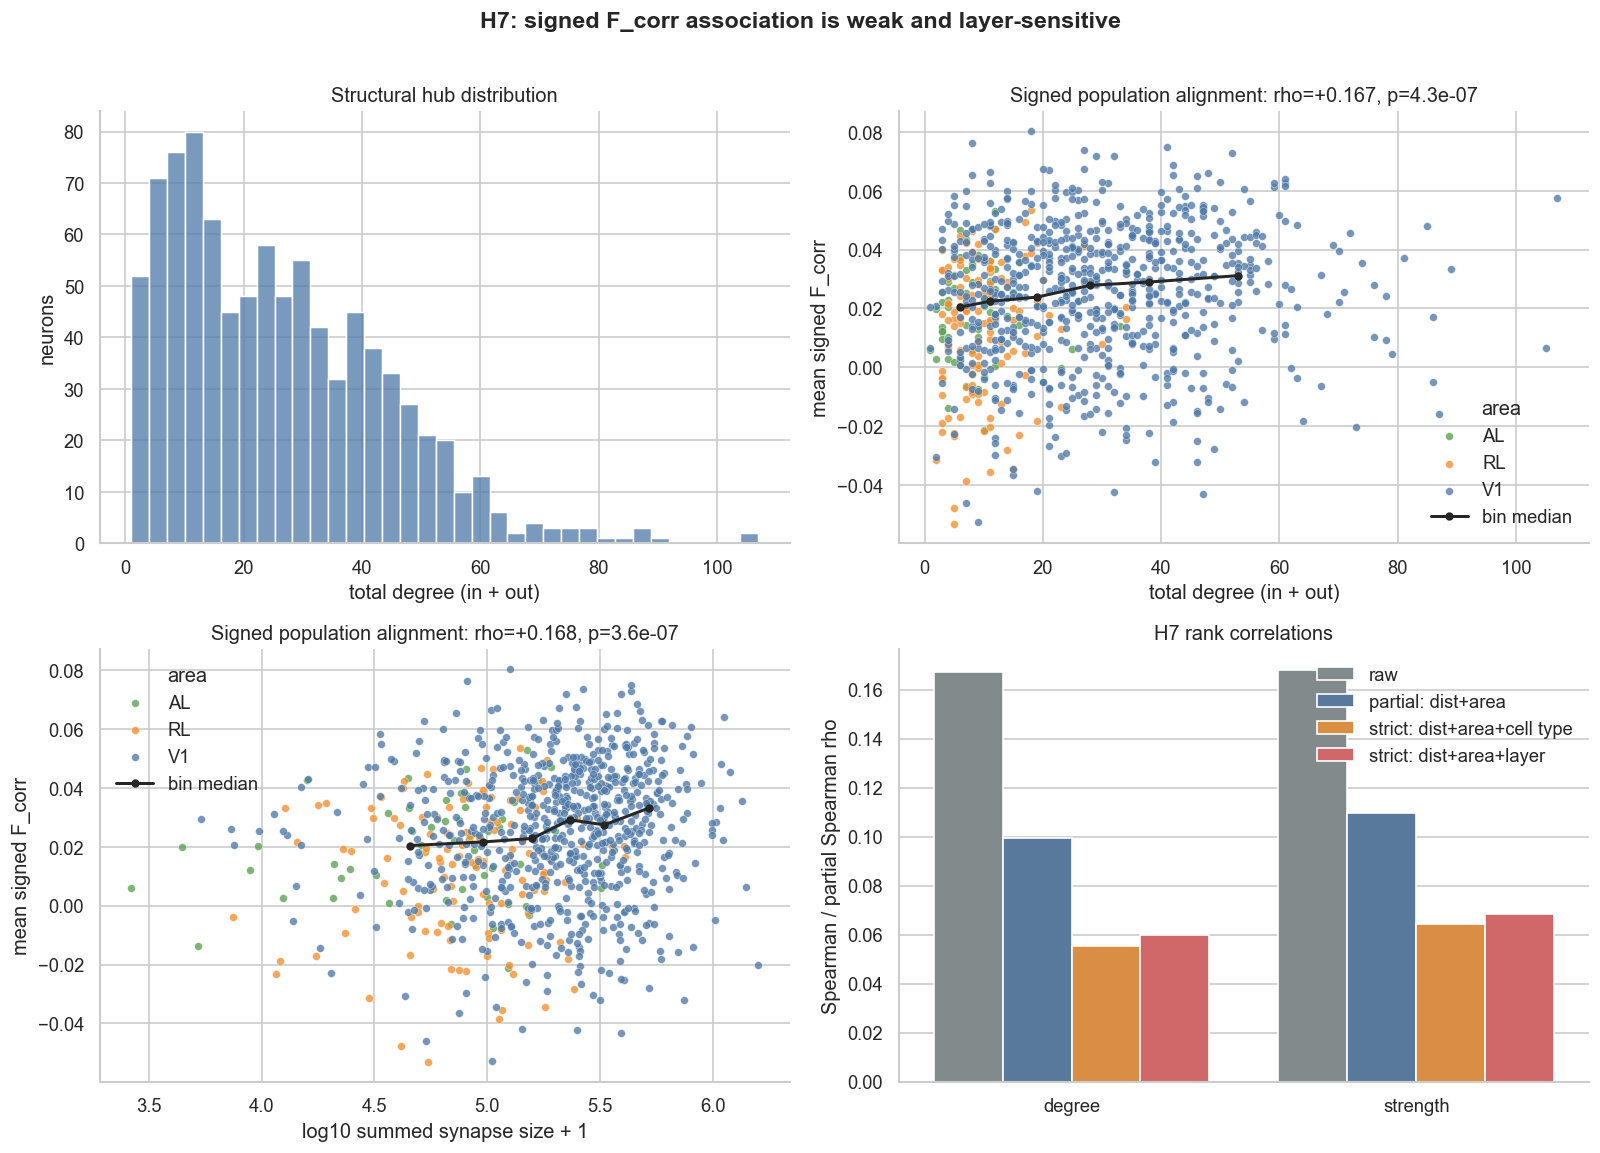

In [132]:
plot_df = hub_metrics[hub_metrics.valid_function].copy()
coef_df = h7_summary[
    (h7_summary.cohort == 'all_906')
    & (h7_summary.functional_metric == 'mean_fcorr_signed')
    & (h7_summary.structural_metric.isin(['total_degree', 'total_strength']))
    & (h7_summary.controls.isin(['raw', 'distance+area', 'distance+area+cell_type', 'distance+area+layer']))
].copy()
coef_df['metric_label'] = coef_df.structural_metric.map({
    'total_degree': 'degree',
    'total_strength': 'strength',
})
coef_df['control_label'] = coef_df.controls.map({
    'raw': 'raw',
    'distance+area': 'partial: dist+area',
    'distance+area+cell_type': 'strict: dist+area+cell type',
    'distance+area+layer': 'strict: dist+area+layer',
})

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))
ax = axes[0, 0]
sns.histplot(plot_df.total_degree, bins=35, color='#4E79A7', ax=ax)
ax.set(title='Structural hub distribution', xlabel='total degree (in + out)', ylabel='neurons')

for ax, xcol, xlabel in [
    (axes[0, 1], 'total_degree', 'total degree (in + out)'),
    (axes[1, 0], 'total_strength', 'log10 summed synapse size + 1'),
]:
    x = plot_df[xcol].to_numpy(dtype=float)
    x_plot = np.log10(x + 1) if xcol == 'total_strength' else x
    for area_name, sub in plot_df.groupby('brain_area'):
        sx = sub[xcol].to_numpy(dtype=float)
        sx = np.log10(sx + 1) if xcol == 'total_strength' else sx
        ax.scatter(
            sx,
            sub.mean_fcorr_signed,
            s=22,
            alpha=0.78,
            linewidths=0.25,
            edgecolor='white',
            color=PAL_AREA.get(area_name, '0.45'),
            label=area_name,
        )
    trend = pd.DataFrame({'x': x_plot, 'y': plot_df.mean_fcorr_signed}).copy()
    trend['bin'] = pd.qcut(trend.x, 6, duplicates='drop')
    trend = trend.groupby('bin', observed=False).agg(x=('x', 'median'), y=('y', 'median')).reset_index(drop=True)
    ax.plot(trend.x, trend.y, color='0.15', lw=1.8, marker='o', ms=4, label='bin median')
    rho = coef_df[(coef_df.structural_metric == xcol) & (coef_df.controls == 'raw')].rho.iloc[0]
    p = coef_df[(coef_df.structural_metric == xcol) & (coef_df.controls == 'raw')].p_value.iloc[0]
    ax.set(title=f'Signed population alignment: rho={rho:+.3f}, p={p:.1e}', xlabel=xlabel, ylabel='mean signed F_corr')
    ax.legend(title='area', frameon=False, loc='best')

ax = axes[1, 1]
sns.barplot(
    data=coef_df,
    x='metric_label',
    y='rho',
    hue='control_label',
    palette=['#7f8c8d', '#4E79A7', '#F28E2B', '#E15759'],
    ax=ax,
)
ax.axhline(0, color='0.2', lw=0.8)
ax.set(title='H7 rank correlations', xlabel='', ylabel='Spearman / partial Spearman rho')
ax.legend(title='', frameon=False)

fig.suptitle('H7: signed F_corr association is weak and layer-sensitive', y=1.01, fontsize=14, fontweight='semibold')
plt.tight_layout()
out_fig = OUT_FIG / 'h7_hub_coupling.png'
fig.savefig(out_fig, bbox_inches='tight')
print(f'saved: {relpath(out_fig)}')
plt.show()


### H7 Hub-Coupling Conclusion

H7 does not support broad topology-level alignment in the 906-neuron excitatory oracle-response cohort. The one detectable positive result is narrow: structural strength has a weak signed relationship with mean signed signal correlation, with the primary distance- and area-controlled total-strength row showing `rho` about +0.11, or roughly 1% rank variance. This relationship is better interpreted as a small signed population-response alignment among more structurally connected neurons than as evidence that structural hubs are generally functional hubs.

The caveats are central to the result. Synapse-size structural strength adds no detectable variance beyond binary degree, absolute sign-agnostic `F_corr` does not support generic functional coupling magnitude, same-area and V1-only recomputations weaken under controls, and the node-averaged pair-distance residual remains distance-structured. Directional in/out rows suggest possible input-side asymmetry, but the area x layer stratified permutation for `in_strength` is marginal. H7 therefore supports only a narrow, definition-dependent signed population-alignment signal; it does not provide evidence for broader structural-functional topology matching.


## 8.1 H7 Sensitivity View

The sensitivity tables quantify how the H7 result changes under alternative functional metrics and stricter controls. Topology conclusions are more analysis-dependent than the H1 pair-level comparison because node-level hubness can be defined by signed mean correlation, positive-clipped correlation, absolute correlation, or thresholded functional degree.

The signed mean-correlation rows retain a small positive association, but the absolute-correlation and strength-beyond-degree checks do not support a broad hub interpretation. This pattern confines H7 to a limited topology signal rather than structural-functional network equivalence.


In [133]:
sensitivity_view = h7_summary[
    (h7_summary.structural_metric.isin(['total_degree', 'total_strength', 'in_degree', 'out_degree', 'in_strength', 'out_strength']))
    & (h7_summary.controls.isin(['raw', 'distance', 'distance+area', 'distance+area+cell_type', 'distance+area+layer']))
].copy()
sensitivity_view = sensitivity_view.sort_values([
    'functional_metric', 'cohort', 'structural_metric', 'controls'
])
key_sensitivity = sensitivity_view[
    sensitivity_view.functional_metric.isin(['mean_fcorr_signed', 'mean_fcorr_abs'])
    & sensitivity_view.structural_metric.isin(['total_degree', 'total_strength', 'in_strength', 'out_strength'])
    & sensitivity_view.controls.isin(['distance+area', 'distance+area+cell_type', 'distance+area+layer'])
].copy()
print(key_sensitivity.to_string(index=False))
h7_robustness


 cohort functional_metric structural_metric                controls                test_role       rho  p_value  n_neurons  rank_variance_approx  q_bh_all_tests
all_906    mean_fcorr_abs       in_strength           distance+area              exploratory -0.086663 0.009058        906              0.007510        0.035446
all_906    mean_fcorr_abs       in_strength distance+area+cell_type              exploratory -0.080150 0.015820        906              0.006424        0.056839
all_906    mean_fcorr_abs       in_strength     distance+area+layer              exploratory -0.081968 0.013588        906              0.006719        0.050954
all_906    mean_fcorr_abs      out_strength           distance+area              exploratory  0.029693 0.372009        906              0.000882        0.471561
all_906    mean_fcorr_abs      out_strength distance+area+cell_type              exploratory  0.042697 0.199152        906              0.001823        0.320065
all_906    mean_fcorr_abs      out

,analysis,structural_metric,functional_metric,controls,rho,rank_variance_approx,p_value,n_neurons
0,strength beyond degree,total_strength,mean_fcorr_signed,total_degree,0.032706,0.001070,3.254287e-01,906
1,strength beyond degree,total_strength,mean_fcorr_signed,mean_dist_um+brain_area+total_degree,0.046779,0.002188,1.594707e-01,906
2,cell-type strict control,total_strength,mean_fcorr_signed,mean_dist_um+brain_area+cell_type,0.064268,0.004130,5.313782e-02,906
3,same-area functional mean,total_strength,mean_fcorr_same_area,raw,-0.120596,0.014543,2.745595e-04,906
4,same-area functional mean,total_strength,mean_fcorr_same_area,mean_dist_same_area+brain_area,0.018606,0.000346,5.759541e-01,906
5,same-area functional mean,total_strength,mean_fcorr_same_area,mean_dist_same_area+brain_area+layer,-0.006129,0.000038,8.538250e-01,906
6,pair-distance residual diagnostic,mean_fcorr_pairdist_resid,mean_dist_um,raw,0.217668,0.047379,3.536745e-11,906
7,pair-distance residual diagnostic,total_strength,mean_fcorr_pairdist_resid,raw,-0.050279,0.002528,1.304704e-01,906
8,V1 recomputed functional mean; full structural...,total_strength,mean_fcorr_subset,raw,0.073940,0.005467,4.611852e-02,728
9,V1 recomputed functional mean; full structural...,total_strength,mean_fcorr_subset,mean_dist_subset,0.041740,0.001742,2.606893e-01,728


## 8.2 Thresholded Topology Sensitivity

A dense correlation matrix is not automatically comparable to a sparse synaptic graph. To make a graph-level comparison, the functional matrix is thresholded, and the resulting topology depends strongly on that threshold. This section checks that sensitivity directly.

The functional graph is thresholded at densities around the structural density. The analysis then compares degree and strength coupling and contrasts average clustering in the structural and thresholded functional graphs. These diagnostics test whether the weak signed hub-coupling result translates into graph topology; the near-zero degree and strength correlations indicate that it does not.


In [134]:
def top_k_functional_adjacency(F_corr, k, valid_mask=None, positive_only=True):
    n = F_corr.shape[0]
    iu, ju = np.triu_indices(n, k=1)
    vals = F_corr[iu, ju]
    mask = np.isfinite(vals)
    if valid_mask is not None:
        mask &= valid_mask[iu] & valid_mask[ju]
    if positive_only:
        mask &= vals > 0
    iu, ju, vals = iu[mask], ju[mask], vals[mask]
    k = int(min(k, len(vals)))
    if k <= 0:
        return np.zeros((n, n), dtype=bool), np.full((n, n), np.nan)
    keep = np.argpartition(vals, -k)[-k:]
    A = np.zeros((n, n), dtype=bool)
    W = np.full((n, n), np.nan)
    A[iu[keep], ju[keep]] = True
    A[ju[keep], iu[keep]] = True
    W[iu[keep], ju[keep]] = vals[keep]
    W[ju[keep], iu[keep]] = vals[keep]
    return A, W

A_struct_und = ((C_strength + C_strength.T) > 0).toarray().astype(bool)
np.fill_diagonal(A_struct_und, False)
struct_degree_und = A_struct_und.sum(axis=1)
struct_edges_und = int(A_struct_und[np.triu_indices(N, k=1)].sum())
possible_edges = N * (N - 1) // 2
struct_density_und = struct_edges_und / possible_edges
struct_clustering = nx.average_clustering(nx.from_numpy_array(A_struct_und))

rows = []
for mult in [0.5, 1.0, 2.0, 4.0]:
    k = max(1, int(round(struct_edges_und * mult)))
    A_func, W_func = top_k_functional_adjacency(F_corr, k, valid_mask=valid, positive_only=True)
    func_degree = A_func.sum(axis=1)
    func_strength = np.nansum(np.where(A_func, W_func, 0.0), axis=1)
    rho_deg, p_deg = spearmanr(struct_degree_und[valid], func_degree[valid])
    rho_str, p_str = spearmanr(hub_metrics.loc[valid, 'total_strength'], func_strength[valid])
    func_clustering = nx.average_clustering(nx.from_numpy_array(A_func))
    rows.append({
        'density_multiplier': mult,
        'functional_edges': int(A_func[np.triu_indices(N, k=1)].sum()),
        'functional_density': float(A_func[np.triu_indices(N, k=1)].sum() / possible_edges),
        'structural_edges_undirected': struct_edges_und,
        'structural_density_undirected': struct_density_und,
        'spearman_struct_degree_vs_functional_degree': float(rho_deg),
        'p_degree': float(p_deg),
        'spearman_struct_strength_vs_functional_strength': float(rho_str),
        'p_strength': float(p_str),
        'structural_clustering': float(struct_clustering),
        'functional_clustering': float(func_clustering),
    })

topology = pd.DataFrame(rows)
out_topology = OUT_TBL / 'h7_topology_sensitivity.csv'
topology.to_csv(out_topology, index=False)
print(f'saved: {relpath(out_topology)}')
topology


saved: outputs/tables/h7_topology_sensitivity.csv


,density_multiplier,functional_edges,functional_density,structural_edges_undirected,structural_density_undirected,spearman_struct_degree_vs_functional_degree,p_degree,spearman_struct_strength_vs_functional_strength,p_strength,structural_clustering,functional_clustering
0,0.5,5790,0.014123,11580,0.028246,-0.003324,0.920414,-0.001005,0.975891,0.070919,0.268704
1,1.0,11580,0.028246,11580,0.028246,0.008211,0.805047,0.011389,0.732099,0.070919,0.287253
2,2.0,23160,0.056493,11580,0.028246,0.006027,0.856244,0.010923,0.742654,0.070919,0.300804
3,4.0,46320,0.112985,11580,0.028246,0.029663,0.372489,0.031480,0.343916,0.070919,0.331571


saved: outputs/figures/h7_topology_sensitivity.png


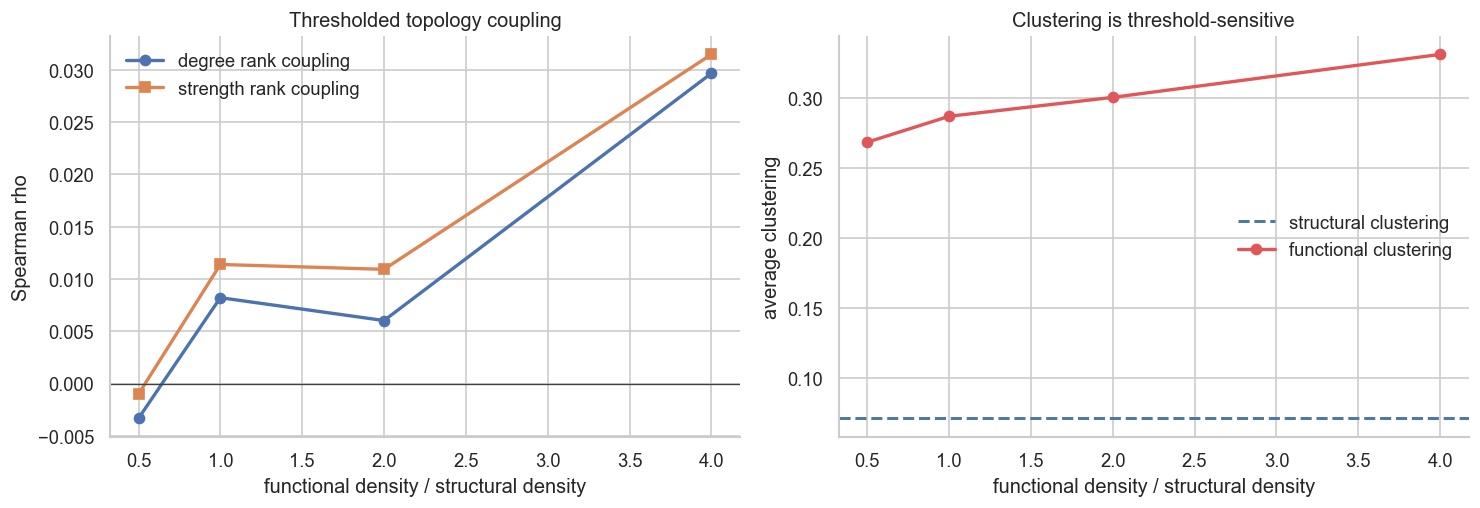

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
ax.plot(
    topology.density_multiplier,
    topology.spearman_struct_degree_vs_functional_degree,
    marker='o',
    lw=2,
    label='degree rank coupling',
)
ax.plot(
    topology.density_multiplier,
    topology.spearman_struct_strength_vs_functional_strength,
    marker='s',
    lw=2,
    label='strength rank coupling',
)
ax.axhline(0, color='0.25', lw=0.8)
ax.set(xlabel='functional density / structural density', ylabel='Spearman rho', title='Thresholded topology coupling')
ax.legend(frameon=False)

ax = axes[1]
ax.axhline(struct_clustering, color='#4E79A7', ls='--', lw=1.8, label='structural clustering')
ax.plot(
    topology.density_multiplier,
    topology.functional_clustering,
    color='#E15759',
    marker='o',
    lw=2,
    label='functional clustering',
)
ax.set(xlabel='functional density / structural density', ylabel='average clustering', title='Clustering is threshold-sensitive')
ax.legend(frameon=False)

plt.tight_layout()
out_fig = OUT_FIG / 'h7_topology_sensitivity.png'
fig.savefig(out_fig, bbox_inches='tight')
print(f'saved: {relpath(out_fig)}')
plt.show()


### Topology Conclusion

Topology similarity is not detected in the thresholded graph checks. Thresholded functional-network metrics depend on the chosen density and on whether signed, positive-only, or absolute correlations are used, but across these definitions the structural-versus-functional degree and strength correlations remain near zero. This reflects a real conceptual mismatch between sparse directed synapses and dense symmetric correlations.

The final synthesis is that anatomical connectivity carries a clear pair-level functional signal, while broader topology matching is not detected. Connected neurons are more correlated on average, but the structural and functional networks do not show topology-level equivalence in these H7 checks.


## 9. H1 Cross-check and Scope Checks

This section checks whether the main H1 result is stable outside the primary 906-neuron signal-correlation analysis.

It has three roles:

- Same-scan cross-check in the 93-neuron scan 9.3 V1/L4 cohort using trace correlation.
- Signal/noise decomposition in that same 93-neuron cohort, where trial-level repeated-stimulus data are available.
- Exploratory V1/RL/AL area comparisons in the 906-neuron signal-correlation cohort.

These analyses are cross and scope checks. They strengthen or qualify H1, but they do not replace the main 906-neuron H1 test above.


## 9.1 Same-Scan 93-Neuron V1/L4 Cross-check of H1

The primary H1 result above uses the 906-neuron cohort and signal correlation across shared oracle stimuli. This section repeats the connected-versus-unconnected comparison in a smaller but co-recorded cohort: 93 layer-4 V1 neurons from scan 9.3.

The first measure is **trace correlation**, computed from raw co-recorded activity traces across trials. Trace correlation mixes stimulus-driven signal and trial-to-trial noise, so it is not identical to the 906-neuron signal correlation. That difference is the reason the test is useful: it asks whether the H1 effect appears under a same-scan measurement regime with simultaneous activity.

A note on effect sizes. The Cohen's d values in this section are 2–3× larger than the 906-neuron headline result. This is not because the smaller cohort recovers a "more correct" effect: trace correlation captures shared trial-to-trial noise that the cross-scan 906 design discards, and L4 V1 is a densely interconnected sub-region that was hand-curated for tightly co-recorded neurons. The 93-neuron numbers should be read as a same-scan consistency check, not as a better estimate of the underlying biological effect.

Output files saved by this section include:

- `outputs/tables/person4_scan93_area_summary.csv`
- `outputs/figures/person4_scan93_area_checks.png`


### Setup Helpers

This code cell defines validation-specific helper functions. It reuses the shared imports, palettes, and output directories from the top of the notebook.


In [136]:
# Validation helper functions. Reuse the shared imports, palettes, and output paths defined above.
required_p4_globals = [
    'np', 'pd', 'Path', 'stats', 'mannwhitneyu', 'plt', 'sns',
    'PAL_CONN', 'ORDER_CONN', 'PAL_AREA', 'RAMP_SEQ', 'OUT_FIG', 'OUT_TBL',
]
missing_p4_globals = [name for name in required_p4_globals if name not in globals()]
if missing_p4_globals:
    raise RuntimeError(f'Run the shared setup cells before validation cells. Missing: {missing_p4_globals}')


def p4_boot_mean_diff(a, b, n_boot=10_000, seed=0, max_draws_per_batch=5_000_000):
    rng = np.random.default_rng(seed)
    a = np.asarray(a)
    b = np.asarray(b)
    diffs = np.empty(n_boot, dtype=float)
    batch = max(1, min(n_boot, max_draws_per_batch // max(len(a), len(b))))
    for start in range(0, n_boot, batch):
        stop = min(start + batch, n_boot)
        size = stop - start
        diffs[start:stop] = (
            rng.choice(a, (size, len(a)), replace=True).mean(1)
            - rng.choice(b, (size, len(b)), replace=True).mean(1)
        )
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])


def p4_cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp


def p4_mw_row(label, a, b, n_boot=5000, seed=0):
    U_, p_ = mannwhitneyu(a, b, alternative='greater')
    md_, ci_ = p4_boot_mean_diff(a, b, n_boot=n_boot, seed=seed)
    d_ = p4_cohens_d(a, b)
    return {'comparison': label, 'n_conn': len(a), 'n_ctrl': len(b),
            'mean_conn': a.mean(), 'mean_ctrl': b.mean(),
            'mean_diff': md_, 'ci_lo': ci_[0], 'ci_hi': ci_[1],
            'cohens_d': d_, 'p_one_sided': p_}


### Load the 93-Neuron Cohort

This cell loads the same-scan validation inputs:

| File | Contents |
|---|---|
| `outputs/functional_network/F_correlation_matrix.npy` | 93 x 93 Pearson trace-correlation matrix from scan 9.3. |
| `outputs/functional_network/functional_cohort.csv` | Per-neuron metadata and matrix indices. |
| `Data/exports/G_93_nodes.csv` | Structural node attributes. |
| `Data/exports/G_93_edges.csv` | Directed structural edges within the 93-neuron cohort. |

The important alignment field is `matrix_index`, which maps each neuron to its row and column in the trace-correlation matrix.


In [137]:
F93 = np.load(ROOT / 'outputs' / 'functional_network' / 'F_correlation_matrix.npy')
cohort93 = pd.read_csv(ROOT / 'outputs' / 'functional_network' / 'functional_cohort.csv')
nodes93 = pd.read_csv(EXPORTS_DIR / 'G_93_nodes.csv')
edges93 = pd.read_csv(EXPORTS_DIR / 'G_93_edges.csv')

N93_from_matrix = F93.shape[0]
off93_matrix = ~np.eye(N93_from_matrix, dtype=bool)
print(f'F93 shape (trace-corr matrix) : {F93.shape}')
print(f'Cohort neurons                : {len(cohort93)}')
print(f'Structural edges              : {len(edges93)}')
print(f'F93 off-diag range            : '
      f'[{F93[off93_matrix].min():.4f}, '
      f'{F93[off93_matrix].max():.4f}]')


F93 shape (trace-corr matrix) : (93, 93)
Cohort neurons                : 93
Structural edges              : 229
F93 off-diag range            : [-0.0306, 0.6280]


### Build the 93-Neuron Pair Table

This cell builds `pairs93`, a separate unordered pair table for the 93-neuron validation cohort. It deliberately does not reuse the name `pairs`, because `pairs` is already the shared 906-neuron pair table.

The 93-neuron table stores trace correlation, connection class, binary connectedness, synapse-size summary, and soma distance for each unordered pair.


In [138]:
merged93 = cohort93.merge(
    nodes93[['neuron_id', 'pref_ori', 'gOSI',
             'out_degree', 'in_degree', 'out_strength', 'in_strength']],
    left_on='pt_root_id', right_on='neuron_id', how='inner',
).reset_index(drop=True)
assert len(merged93) == 93

edges93 = edges93.copy()
edges93['pre_neuron_id'] = edges93['pre_neuron_id'].astype('int64')
edges93['post_neuron_id'] = edges93['post_neuron_id'].astype('int64')

neuron_ids93 = merged93['pt_root_id'].values.astype('int64')
midxs93 = merged93['matrix_index'].values.astype(int)
xyz93 = merged93[['pt_position_x', 'pt_position_y', 'pt_position_z']].values
conn93_set = set(zip(edges93['pre_neuron_id'], edges93['post_neuron_id']))
syn93_lookup = dict(zip(
    zip(edges93['pre_neuron_id'], edges93['post_neuron_id']),
    edges93['synapse_size']
))

N93 = len(merged93)
iu93, ju93 = np.triu_indices(N93, k=1)
ni93_arr = neuron_ids93[iu93]
nj93_arr = neuron_ids93[ju93]
f_corr93_arr = F93[midxs93[iu93], midxs93[ju93]]
dist93_arr = np.linalg.norm(xyz93[iu93] - xyz93[ju93], axis=1)

c_ij93 = np.array([(int(ni), int(nj)) in conn93_set for ni, nj in zip(ni93_arr, nj93_arr)])
c_ji93 = np.array([(int(nj), int(ni)) in conn93_set for ni, nj in zip(ni93_arr, nj93_arr)])
conn_type93 = np.where(c_ij93 & c_ji93, 'bi', np.where(c_ij93 | c_ji93, 'uni', 'none'))

sz_ij93 = np.array([syn93_lookup.get((int(ni), int(nj)), 0.) for ni, nj in zip(ni93_arr, nj93_arr)])
sz_ji93 = np.array([syn93_lookup.get((int(nj), int(ni)), 0.) for ni, nj in zip(ni93_arr, nj93_arr)])
syn_size_max93 = np.where(c_ij93 | c_ji93, np.maximum(sz_ij93, sz_ji93), np.nan)

pairs93 = pd.DataFrame({
    'ni': ni93_arr, 'nj': nj93_arr,
    'f_corr': f_corr93_arr, 'conn_type': conn_type93,
    'connected': conn_type93 != 'none',
    'syn_size_max': syn_size_max93, 'dist_um': dist93_arr,
})

vc93 = pairs93.conn_type.value_counts()
print(f'Total pairs  : {len(pairs93):,}')
print(f'  none       : {vc93.get("none", 0):,}')
print(f'  uni        : {vc93.get("uni",  0):,}')
print(f'  bi         : {vc93.get("bi",   0):,}')
print(f'\ntrace-corr summary:')
print(pairs93.f_corr.describe().to_string())


Total pairs  : 4,278
  none       : 4,057
  uni        : 213
  bi         : 8

trace-corr summary:
count    4278.000000
mean        0.019832
std         0.036670
min        -0.030599
25%        -0.002262
50%         0.011696
75%         0.031488
max         0.627975


### Connected vs Unconnected Trace Correlation

This is the 93-neuron validation version of H1. It is not a duplicate of the main H1 test because the cohort and functional measure differ:

- Main H1: 906 neurons, cross-scan signal correlation across shared oracle responses.
- Validation H1: 93 same-scan V1/L4 neurons, trace correlation from co-recorded activity.

The expected result is not necessarily identical in magnitude. The purpose is to check whether directly connected pairs are also more correlated in a smaller but simultaneously recorded cohort.


=== H1: connected > unconnected (one-sided MW, trace correlation) ===
  connected   n=  221   mean=+0.04424
  unconnected n=4,057   mean=+0.01850
  Δmean = +0.02582   95% CI [+0.01824, +0.03418]
  p = 4.801e-18   Cohen's d = +0.711


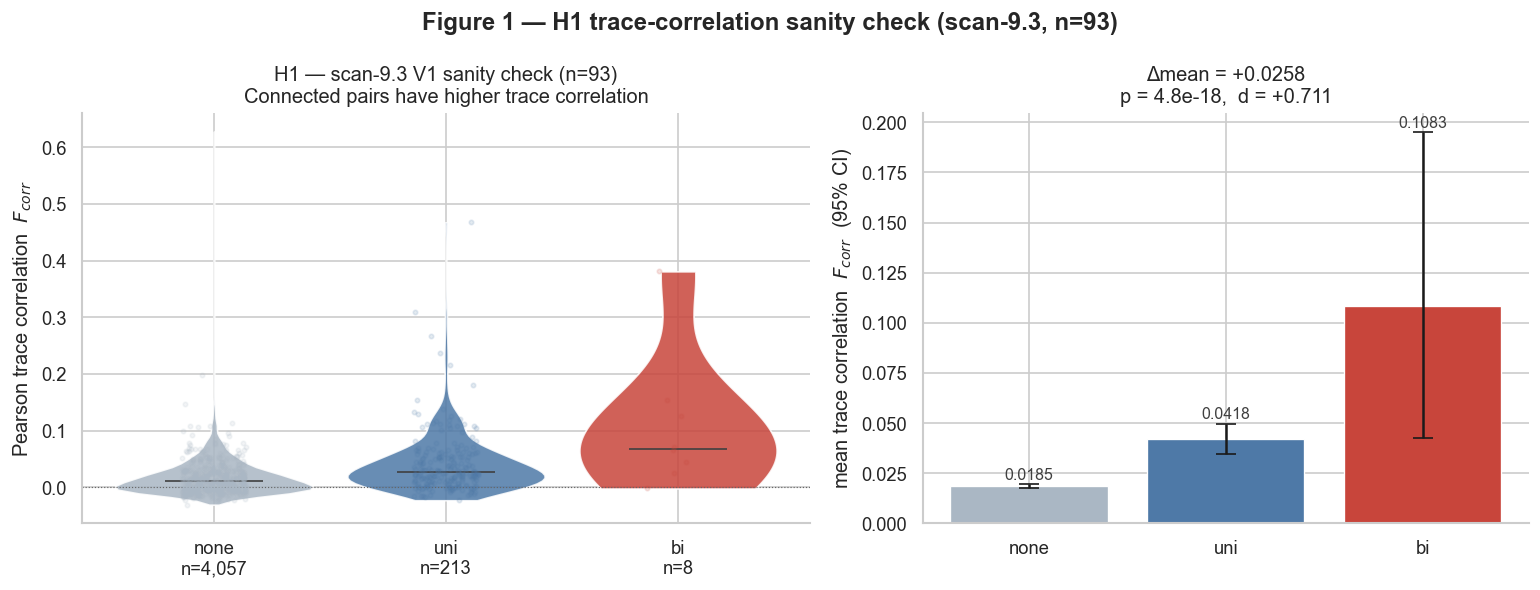

In [139]:
f_none93 = pairs93.loc[pairs93.conn_type == 'none', 'f_corr'].to_numpy()
f_uni93 = pairs93.loc[pairs93.conn_type == 'uni', 'f_corr'].to_numpy()
f_bi93 = pairs93.loc[pairs93.conn_type == 'bi', 'f_corr'].to_numpy()
f_conn93 = pairs93.loc[pairs93.connected, 'f_corr'].to_numpy()

r_h1_93 = p4_mw_row('conn vs none', f_conn93, f_none93)
print('=== H1: connected > unconnected (one-sided MW, trace correlation) ===')
print(f'  connected   n={r_h1_93["n_conn"]:>5,}   mean={r_h1_93["mean_conn"]:+.5f}')
print(f'  unconnected n={r_h1_93["n_ctrl"]:>5,}   mean={r_h1_93["mean_ctrl"]:+.5f}')
print(f'  Δmean = {r_h1_93["mean_diff"]:+.5f}   95% CI [{r_h1_93["ci_lo"]:+.5f}, {r_h1_93["ci_hi"]:+.5f}]')
print(f'  p = {r_h1_93["p_one_sided"]:.3e}   Cohen\'s d = {r_h1_93["cohens_d"]:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.2, 1]})

ax = axes[0]
data_v93 = [f_none93, f_uni93, f_bi93]
parts = ax.violinplot(data_v93, positions=[1, 2, 3], showmedians=True, showextrema=False, widths=0.85)
for k, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PAL_CONN[ORDER_CONN[k]]); pc.set_edgecolor('white'); pc.set_alpha(0.85)
for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
    if key in parts:
        parts[key].set_color('0.25'); parts[key].set_linewidth(1.0)
for k, (dv, cv) in enumerate(zip(data_v93, [PAL_CONN[g] for g in ORDER_CONN])):
    np.random.seed(k)
    jit = np.random.uniform(-0.14, 0.14, min(len(dv), 400))
    smp = np.random.choice(dv, min(len(dv), 400), replace=False)
    ax.scatter(np.full(len(smp), k+1) + jit, smp, alpha=0.15, s=7, color=cv, zorder=3)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'none\nn={len(f_none93):,}', f'uni\nn={len(f_uni93):,}', f'bi\nn={len(f_bi93):,}'])
ax.set_ylabel('Pearson trace correlation  $F_{corr}$')
ax.set_title('H1 — scan-9.3 V1 sanity check (n=93)\nConnected pairs have higher trace correlation')
ax.axhline(0, color='0.4', lw=0.7, ls=':')

ax2 = axes[1]
rng = np.random.default_rng(42)
means_b93, los_b93, his_b93 = [], [], []
for gd in data_v93:
    bm = rng.choice(gd, (4000, len(gd)), replace=True).mean(1)
    means_b93.append(gd.mean()); los_b93.append(np.percentile(bm, 2.5)); his_b93.append(np.percentile(bm, 97.5))
ax2.bar(np.arange(3), means_b93,
        yerr=[np.array(means_b93)-np.array(los_b93), np.array(his_b93)-np.array(means_b93)],
        color=[PAL_CONN[g] for g in ORDER_CONN], edgecolor='white', linewidth=0.8, capsize=6)
for k, (m_, h_) in enumerate(zip(means_b93, his_b93)):
    ax2.text(k, h_ + 0.001, f'{m_:.4f}', ha='center', va='bottom', fontsize=9.5, color='0.25')
ax2.set_xticks(np.arange(3)); ax2.set_xticklabels(ORDER_CONN)
ax2.set_ylabel('mean trace correlation  $F_{corr}$  (95% CI)')
ax2.set_title(f'Δmean = {r_h1_93["mean_diff"]:+.4f}\np = {r_h1_93["p_one_sided"]:.1e},  d = {r_h1_93["cohens_d"]:+.3f}')

plt.suptitle('Figure 1 — H1 trace-correlation sanity check (scan-9.3, n=93)', fontweight='bold')
plt.tight_layout(); plt.show()

H1_93_RESULT = r_h1_93 | {'cohort': '93-neuron scan-9.3', 'measure': 'trace_correlation'}


### Trace-Correlation Distribution Checks

These plots show the full trace-correlation distributions for unconnected, unidirectional, and bidirectional pairs in the 93-neuron cohort. They are visual diagnostics for the same H1 validation test: a rightward shift of connected pairs supports the connected-greater-than-unconnected result.

The heatmap sorts the 93-neuron trace-correlation matrix by preferred orientation, which provides context for tuning-related structure in this same-scan cohort.


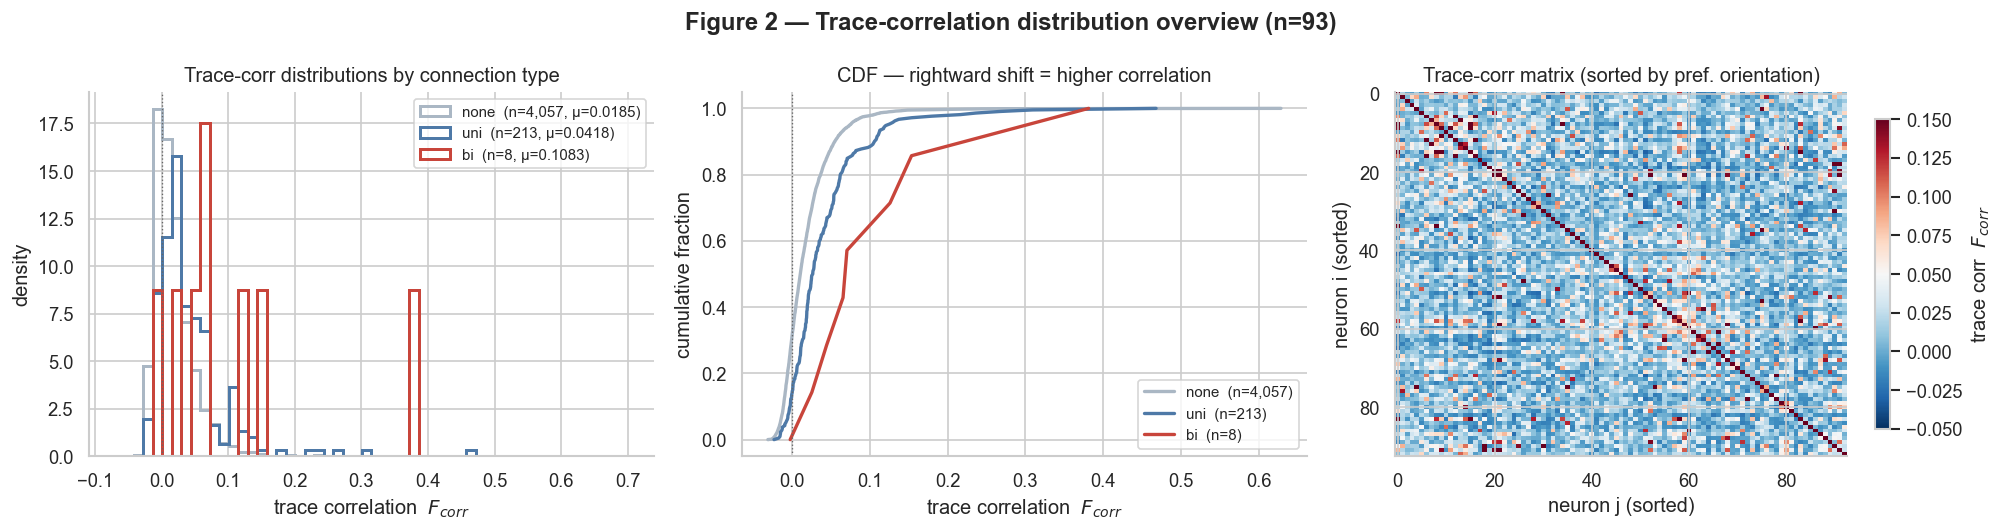

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
bins_h = np.linspace(-0.07, 0.70, 55)

ax = axes[0]
for g, dv in zip(ORDER_CONN, [f_none93, f_uni93, f_bi93]):
    ax.hist(dv, bins=bins_h, density=True, histtype='step', linewidth=1.8,
            color=PAL_CONN[g], label=f'{g}  (n={len(dv):,}, µ={dv.mean():.4f})')
ax.axvline(0, color='0.4', lw=0.8, ls=':')
ax.set(xlabel='trace correlation  $F_{corr}$', ylabel='density',
       title='Trace-corr distributions by connection type')
ax.legend(fontsize=9)

ax2 = axes[1]
for g, dv in zip(ORDER_CONN, [f_none93, f_uni93, f_bi93]):
    sv = np.sort(dv)
    ax2.plot(sv, np.linspace(0, 1, len(sv)), color=PAL_CONN[g], lw=2, label=f'{g}  (n={len(dv):,})')
ax2.axvline(0, color='0.4', lw=0.8, ls=':')
ax2.set(xlabel='trace correlation  $F_{corr}$', ylabel='cumulative fraction',
        title='CDF — rightward shift = higher correlation')
ax2.legend(fontsize=9)

ax3 = axes[2]
order93 = merged93['pref_ori'].argsort().values
im = ax3.imshow(F93[np.ix_(order93, order93)], cmap='RdBu_r', vmin=-0.05, vmax=0.15, aspect='auto')
plt.colorbar(im, ax=ax3, shrink=0.85, label='trace corr  $F_{corr}$')
ax3.set(title='Trace-corr matrix (sorted by pref. orientation)',
        xlabel='neuron j (sorted)', ylabel='neuron i (sorted)')

plt.suptitle('Figure 2 — Trace-correlation distribution overview (n=93)', fontweight='bold')
plt.tight_layout(); plt.show()


### Reciprocity Check in the 93-Neuron Cohort

This is a small-cohort analogue of H3, included only as an exploratory check. The primary validation claim remains connected versus unconnected. Bidirectional pairs are very rare in the 93-neuron cohort, so `bi > uni` should not be used as a strong conclusion even if the point estimate is positive.


=== Pairwise one-sided MW tests ===

conn vs none          n_a=  221  n_b=4,057  Δmean=+0.0258  [+0.0182,+0.0342]  p=4.801e-18  d=+0.711
uni  vs none          n_a=  213  n_b=4,057  Δmean=+0.0233  [+0.0163,+0.0313]  p=2.193e-16  d=+0.651
bi   vs none          n_a=    8  n_b=4,057  Δmean=+0.0898  [+0.0254,+0.1770]  p=2.388e-04  d=+2.583
bi   vs uni           n_a=    8  n_b=  213  Δmean=+0.0660  [+0.0012,+0.1530]  p=1.274e-02  d=+1.123


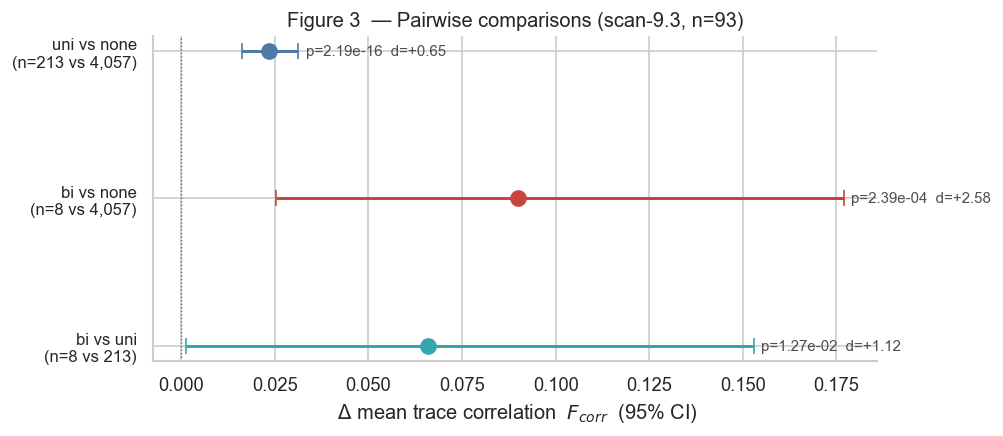

In [141]:
print('=== Pairwise one-sided MW tests ===\n')
r1_93 = p4_mw_row('conn vs none', f_conn93, f_none93)
r2_93 = p4_mw_row('uni  vs none', f_uni93, f_none93)
r3_93 = p4_mw_row('bi   vs none', f_bi93, f_none93)
r4_93 = p4_mw_row('bi   vs uni', f_bi93, f_uni93)
for r in [r1_93, r2_93, r3_93, r4_93]:
    print(f'{r["comparison"]:<20}  n_a={r["n_conn"]:>5,}  n_b={r["n_ctrl"]:>5,}  '
          f'Δmean={r["mean_diff"]:+.4f}  [{r["ci_lo"]:+.4f},{r["ci_hi"]:+.4f}]  '
          f'p={r["p_one_sided"]:.3e}  d={r["cohens_d"]:+.3f}')

fig, ax = plt.subplots(figsize=(8.5, 3.8))
results_pw93 = [r2_93, r3_93, r4_93]
labels_pw93 = ['uni vs none\n(n=213 vs 4,057)', 'bi vs none\n(n=8 vs 4,057)', 'bi vs uni\n(n=8 vs 213)']
ypos = np.arange(len(results_pw93))[::-1]
for y_, r_, c_ in zip(ypos, results_pw93, [PAL_CONN['uni'], PAL_CONN['bi'], RAMP_SEQ(0.65)]):
    ax.errorbar(r_['mean_diff'], y_,
                xerr=[[r_['mean_diff'] - r_['ci_lo']], [r_['ci_hi'] - r_['mean_diff']]],
                fmt='o', color=c_, markersize=9, capsize=5, lw=1.8)
    ax.text(r_['ci_hi'] + 0.002, y_, f"p={r_['p_one_sided']:.2e}  d={r_['cohens_d']:+.2f}",
            va='center', fontsize=9, color='0.3')
ax.axvline(0, color='0.4', lw=0.8, ls=':')
ax.set_yticks(ypos); ax.set_yticklabels(labels_pw93, fontsize=10)
ax.set_xlabel(' Δ mean trace correlation  $F_{corr}$  (95% CI)')
ax.set_title('Figure 3  — Pairwise comparisons (scan-9.3, n=93)')
plt.tight_layout(); plt.show()

PAIRWISE_93 = [r1_93, r2_93, r3_93, r4_93]


### Effect-Size Context for the 93-Neuron Check

These plots translate the 93-neuron H1 effect into distributional context. The CDF panel shows where the connected-pair means sit relative to the unconnected distribution, and the distance scatter gives a quick visual check for spatial structure in the same-scan cohort.

Formal distance controls for the main 906-neuron result are handled earlier in H4.


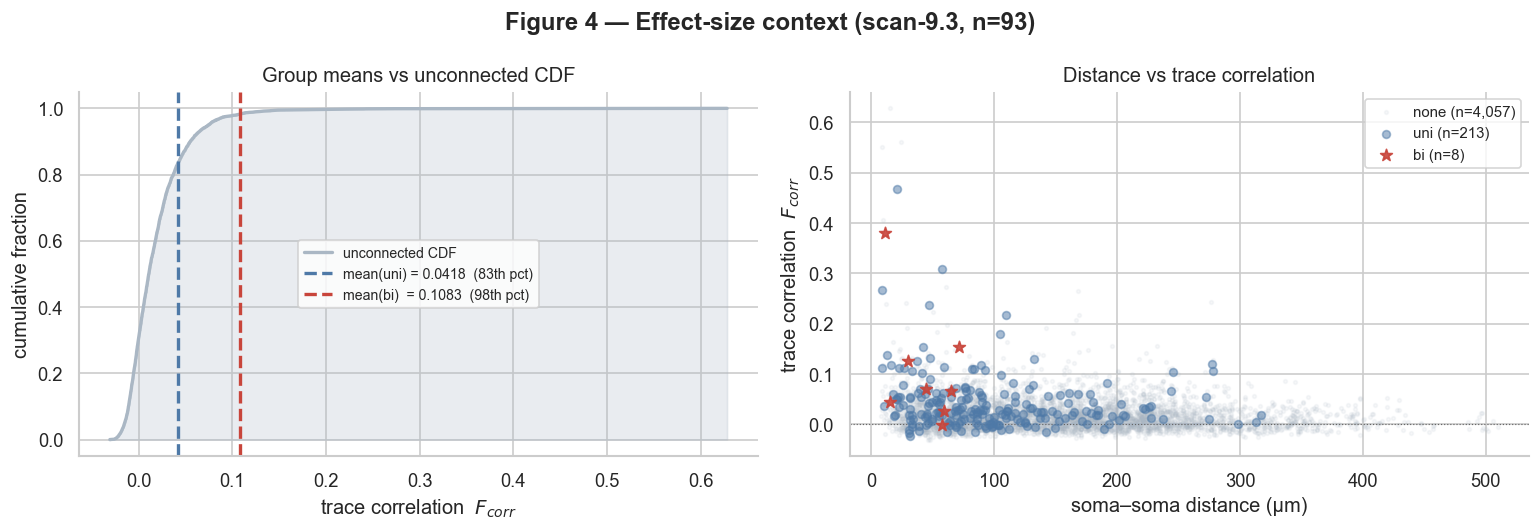

mean(uni) sits at the 83th percentile of the unconnected distribution
mean(bi)  sits at the 98th percentile of the unconnected distribution


In [142]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
pct_uni93 = float(stats.percentileofscore(f_none93, f_uni93.mean()))
pct_bi93 = float(stats.percentileofscore(f_none93, f_bi93.mean()))
sv93 = np.sort(f_none93)
ax.fill_between(sv93, np.linspace(0, 1, len(sv93)), alpha=0.25, color=PAL_CONN['none'], step='post')
ax.plot(sv93, np.linspace(0, 1, len(sv93)), color=PAL_CONN['none'], lw=2, label='unconnected CDF')
ax.axvline(f_uni93.mean(), color=PAL_CONN['uni'], lw=2, ls='--',
           label=f'mean(uni) = {f_uni93.mean():.4f}  ({pct_uni93:.0f}th pct)')
ax.axvline(f_bi93.mean(), color=PAL_CONN['bi'], lw=2, ls='--',
           label=f'mean(bi)  = {f_bi93.mean():.4f}  ({pct_bi93:.0f}th pct)')
ax.set(xlabel='trace correlation  $F_{corr}$', ylabel='cumulative fraction',
       title='Group means vs unconnected CDF')
ax.legend(fontsize=8.5)

ax2 = axes[1]
ax2.scatter(pairs93.loc[~pairs93.connected, 'dist_um'], pairs93.loc[~pairs93.connected, 'f_corr'],
            color=PAL_CONN['none'], alpha=0.1, s=5, label=f'none (n={len(f_none93):,})', zorder=2)
ax2.scatter(pairs93.loc[pairs93.conn_type=='uni', 'dist_um'], pairs93.loc[pairs93.conn_type=='uni', 'f_corr'],
            color=PAL_CONN['uni'], alpha=0.5, s=22, label=f'uni (n={len(f_uni93):,})', zorder=4)
ax2.scatter(pairs93.loc[pairs93.conn_type=='bi', 'dist_um'], pairs93.loc[pairs93.conn_type=='bi', 'f_corr'],
            color=PAL_CONN['bi'], alpha=0.9, s=55, marker='*',
            label=f'bi (n={len(f_bi93):,})', zorder=5)
ax2.set(xlabel='soma–soma distance (µm)', ylabel='trace correlation  $F_{corr}$',
        title='Distance vs trace correlation')
ax2.axhline(0, color='0.4', lw=0.7, ls=':')
ax2.legend(fontsize=9)

plt.suptitle('Figure 4 — Effect-size context (scan-9.3, n=93)', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'mean(uni) sits at the {pct_uni93:.0f}th percentile of the unconnected distribution')
print(f'mean(bi)  sits at the {pct_bi93:.0f}th percentile of the unconnected distribution')


### 93-Neuron H1 Validation Summary

This cell prints the key same-scan validation statistics from `H1_93_RESULT`: sample sizes, mean trace correlations, mean difference, bootstrap interval, one-sided Mann-Whitney p-value, Cohen's d, and a simple supported/not-supported verdict.

This is a validation summary, not the final notebook summary table.


In [143]:
print('=== H1 RESULT - scan-9.3 sanity check (trace correlation) ===')
for k, v in H1_93_RESULT.items():
    print(f'  {k}: {v:.4g}' if isinstance(v, float) else f'  {k}: {v}')

p_val93 = H1_93_RESULT['p_one_sided']; md_val93 = H1_93_RESULT['mean_diff']
d_val93 = H1_93_RESULT['cohens_d']; ci_lo93 = H1_93_RESULT['ci_lo']
print(f"\nH1 {'SUPPORTED' if p_val93 < 0.05 and ci_lo93 > 0 else 'NOT SUPPORTED'} "
      f"in this cohort (trace correlation).")
print(f'Δmean = {md_val93:+.4f}  (95% CI excludes 0: {ci_lo93 > 0})')
print(f"Cohen's d = {d_val93:+.3f}  "
      f"({'small' if abs(d_val93)<0.3 else 'medium' if abs(d_val93)<0.5 else 'large'})")
print(f'p = {p_val93:.3e}')


=== H1 RESULT - scan-9.3 sanity check (trace correlation) ===
  comparison: conn vs none
  n_conn: 221
  n_ctrl: 4057
  mean_conn: 0.04424
  mean_ctrl: 0.0185
  mean_diff: 0.02582
  ci_lo: 0.01824
  ci_hi: 0.03418
  cohens_d: 0.7105
  p_one_sided: 4.801e-18
  cohort: 93-neuron scan-9.3
  measure: trace_correlation

H1 SUPPORTED in this cohort (trace correlation).
Δmean = +0.0258  (95% CI excludes 0: True)
Cohen's d = +0.711  (large)
p = 4.801e-18


## 9.2 Signal and Noise Correlation Decomposition

The 93-neuron same-scan cohort allows a decomposition that is not possible for the full 906-neuron cross-scan cohort.

| Measure | How computed | What it reflects |
|---|---|---|
| Trace correlation | Correlation of raw per-trial responses across all trials. | Signal and noise mixed. |
| Signal correlation | Correlation of per-stimulus mean responses across oracle conditions. | Shared stimulus tuning. |
| Noise correlation | Correlation of residuals after subtracting condition means. | Shared trial-to-trial variability independent of tuning. |

This matters because a trace-correlation H1 effect could be driven entirely by shared tuning. If the connected-pair effect also appears in residual noise correlation, the same-scan validation provides stronger evidence that direct structural connectivity is associated with functional similarity beyond stimulus tuning alone.


In [144]:
import h5py
from collections import defaultdict

CACHE_NOISE_93 = CACHE_DIR / 'noise_corr_93.npy'
CACHE_SIGNAL_93 = CACHE_DIR / 'signal_corr_93.npy'
FUNCTIONAL_H5 = DATA / 'functional' / 'microns_functional.h5'

if CACHE_NOISE_93.exists() and CACHE_SIGNAL_93.exists():
    noise_corr93 = np.load(CACHE_NOISE_93)
    signal_corr93 = np.load(CACHE_SIGNAL_93)
    print('Loaded noise_corr93 and signal_corr93 from cache.')
else:
    print('Building from HDF5 (scan 9_3)...')
    with h5py.File(FUNCTIONAL_H5, 'r') as f:
        sk = '9_3'
        unit_ids93 = f[f'sessions/{sk}/meta/unit_ids'][:]
        h5_uid_to_row93 = {int(u): i for i, u in enumerate(unit_ids93)}
        # h5py requires sorted fancy indexing
        cohort_uids93 = cohort93['unit_id'].astype(int).tolist()
        sorted_rows93 = sorted(h5_uid_to_row93[uid] for uid in cohort_uids93)
        h5row_to_midx93 = {h5_uid_to_row93[uid]: int(midx)
                           for uid, midx in zip(cohort93['unit_id'].astype(int), cohort93['matrix_index'])}
        perm93 = np.argsort([h5row_to_midx93[r] for r in sorted_rows93])
        trials_h5 = f[f'sessions/{sk}/trials']
        cond_to_trials93 = defaultdict(list)
        for tk in list(trials_h5.keys()):
            ch = trials_h5[tk].attrs['condition_hash']
            resp = trials_h5[tk]['responses'][sorted_rows93, :].mean(axis=1)[perm93]  # (93,)
            cond_to_trials93[ch].append(resp)

    noise_residuals93, signal_vecs93 = [], []
    for ch, resp_list in cond_to_trials93.items():
        arr = np.stack(resp_list, axis=0)     # (n_repeats, 93)
        mean_r = arr.mean(axis=0)            # (93,) signal vector
        signal_vecs93.append(mean_r)
        if len(resp_list) >= 2:
            residuals = arr - mean_r[np.newaxis, :]
            noise_residuals93.extend(residuals)

    noise_mat93 = np.stack(noise_residuals93, axis=0)  # (320, 93)
    signal_mat93 = np.stack(signal_vecs93, axis=0)     # (280, 93)
    noise_corr93 = np.corrcoef(noise_mat93.T)          # (93, 93)
    signal_corr93 = np.corrcoef(signal_mat93.T)        # (93, 93)
    np.save(CACHE_NOISE_93, noise_corr93)
    np.save(CACHE_SIGNAL_93, signal_corr93)
    print(f'Built from {len(noise_residuals93)} noise-residual trials, '
          f'{len(signal_vecs93)} signal conditions. Saved to cache.')

off93 = ~np.eye(N93, dtype=bool)
print(f'Off-diagonal mean:  trace={F93[off93].mean():.5f} | '
      f'signal={signal_corr93[off93].mean():.5f} | '
      f'noise={noise_corr93[off93].mean():.5f}')


Loaded noise_corr93 and signal_corr93 from cache.
Off-diagonal mean:  trace=0.01983 | signal=0.07656 | noise=0.05809


Measure     mean_conn  mean_none    Δmean          p       d
--------------------------------------------------------------
trace         0.04424    0.01850 +0.02582  4.801e-18  +0.711
signal        0.12646    0.07384 +0.05286  7.030e-08  +0.410
noise         0.10218    0.05569 +0.04660  1.474e-05  +0.376


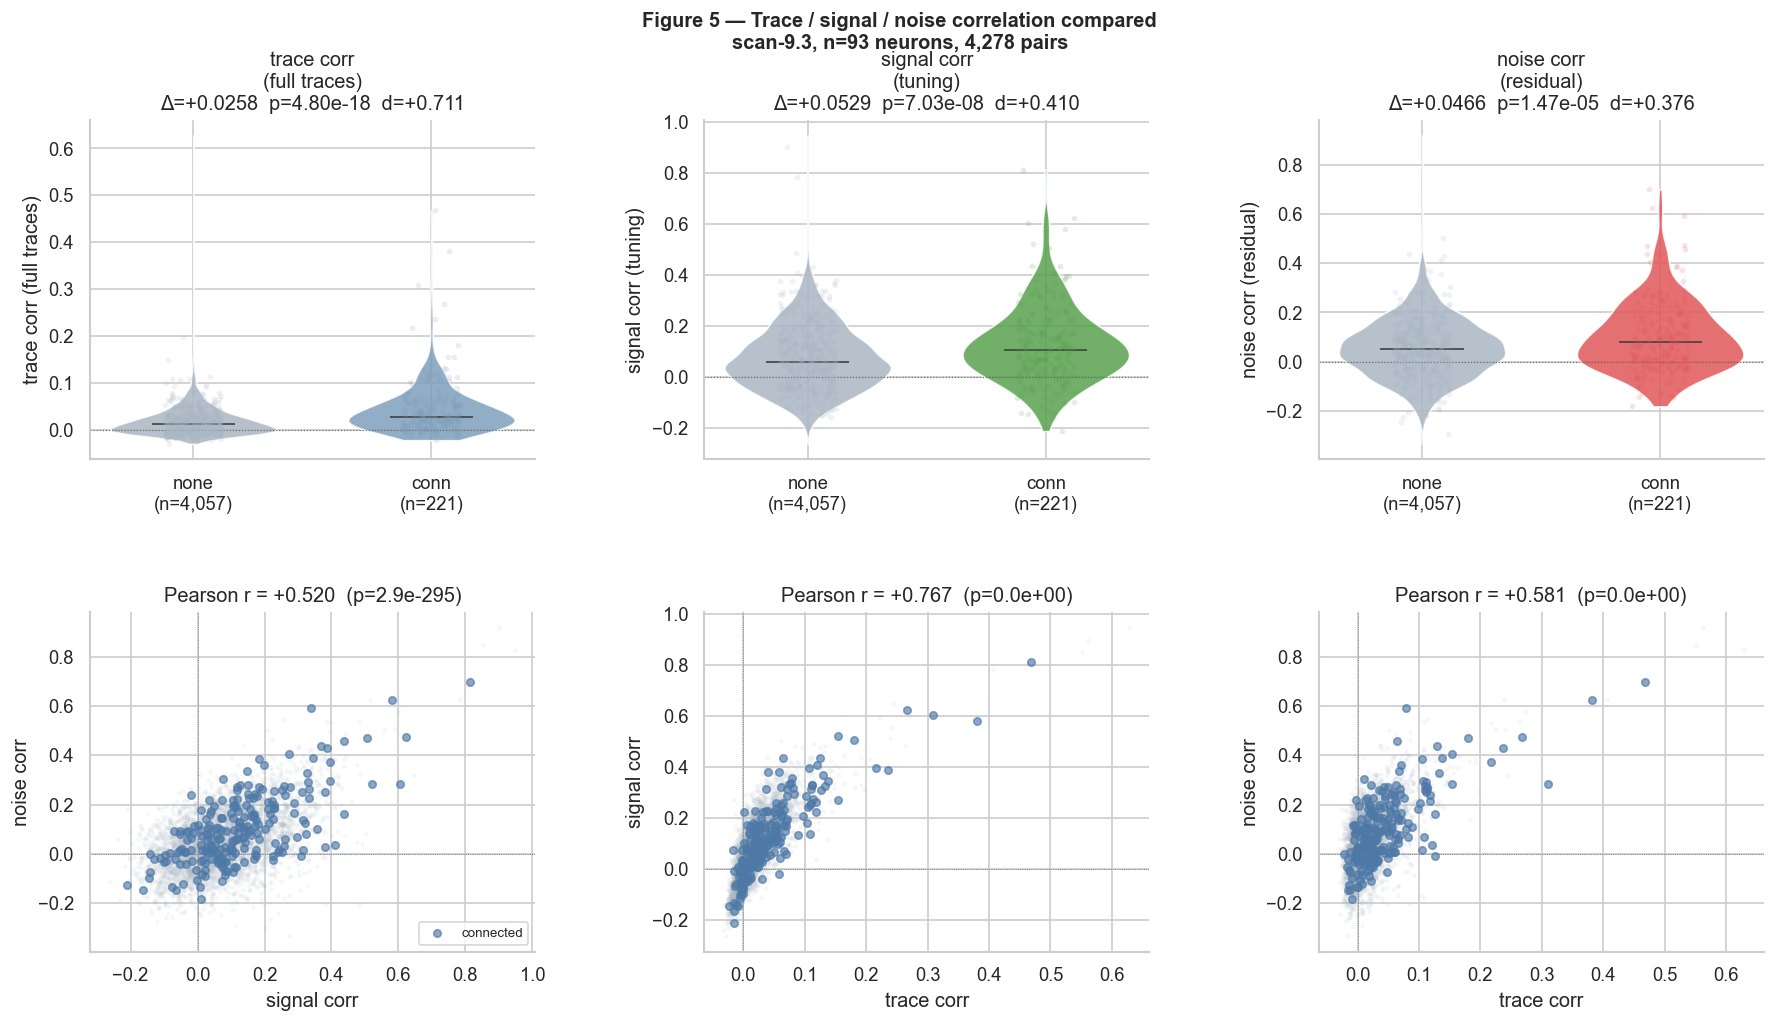


H1 verdict by measure:
  trace   : SIGNIFICANT  (p=4.80e-18, d=+0.711)
  signal  : SIGNIFICANT  (p=7.03e-08, d=+0.410)
  noise   : SIGNIFICANT  (p=1.47e-05, d=+0.376)

Noise-corr H1 is significant → connectivity effect goes beyond shared tuning.


In [ ]:
# H1 on all three measures
connected_mask93 = pairs93['connected'].values
measures93 = {
    'trace': F93[midxs93[iu93], midxs93[ju93]],
    'signal': signal_corr93[midxs93[iu93], midxs93[ju93]],
    'noise': noise_corr93[midxs93[iu93], midxs93[ju93]],
}
measure_colors93 = {'trace': '#7f9fbc', 'signal': '#59A14F', 'noise': '#E15759'}
measure_labels93 = {'trace': 'trace corr\n(full traces)',
                    'signal': 'signal corr\n(tuning)',
                    'noise': 'noise corr\n(residual)'}

print(f'{"Measure":<10} {"mean_conn":>10} {"mean_none":>10} {"Δmean":>8} {"p":>10} {"d":>7}')
print('-' * 62)
h1_by_measure93 = {}
for mkey, vals in measures93.items():
    a = vals[connected_mask93]; b = vals[~connected_mask93]
    r = p4_mw_row(mkey, a, b, n_boot=5000)
    h1_by_measure93[mkey] = r
    print(f'{mkey:<10} {r["mean_conn"]:>10.5f} {r["mean_ctrl"]:>10.5f} '
          f'{r["mean_diff"]:>+8.5f} {r["p_one_sided"]:>10.3e} {r["cohens_d"]:>+7.3f}')

fig = plt.figure(figsize=(18, 9))
gs = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
for col, mkey in enumerate(measures93):
    ax = fig.add_subplot(gs[0, col])
    vals = measures93[mkey]
    a_v = vals[connected_mask93]; b_v = vals[~connected_mask93]
    parts = ax.violinplot([b_v, a_v], positions=[1, 2],
                          showmedians=True, showextrema=False, widths=0.7)
    for k, pc in enumerate(parts['bodies']):
        pc.set_facecolor([PAL_CONN['none'], measure_colors93[mkey]][k])
        pc.set_edgecolor('white'); pc.set_alpha(0.85)
    for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
        if key in parts:
            parts[key].set_color('0.25'); parts[key].set_linewidth(1.0)
    np.random.seed(col)
    for k, (dv, cv) in enumerate(zip([b_v, a_v], [PAL_CONN['none'], measure_colors93[mkey]])):
        jit = np.random.uniform(-0.12, 0.12, min(len(dv), 400))
        smp = np.random.choice(dv, min(len(dv), 400), replace=False)
        ax.scatter(np.full(len(smp), k+1) + jit, smp, alpha=0.12, s=6, color=cv, zorder=3)
    r_ = h1_by_measure93[mkey]
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'none\n(n={len(b_v):,})', f'conn\n(n={len(a_v):,})'])
    ax.set_ylabel(measure_labels93[mkey].replace('\n', ' '))
    ax.set_title(f'{measure_labels93[mkey]}\n'
                 f'Δ={r_["mean_diff"]:+.4f}  p={r_["p_one_sided"]:.2e}  d={r_["cohens_d"]:+.3f}')
    ax.axhline(0, color='0.4', lw=0.7, ls=':')

scatter_triples93 = [
    ('signal', 'noise', 'signal corr', 'noise corr'),
    ('trace', 'signal', 'trace corr', 'signal corr'),
    ('trace', 'noise', 'trace corr', 'noise corr'),
]
for col, (xk, yk, xlabel, ylabel) in enumerate(scatter_triples93):
    ax = fig.add_subplot(gs[1, col])
    xv = measures93[xk]; yv = measures93[yk]
    ax.scatter(xv[~connected_mask93], yv[~connected_mask93],
               color=PAL_CONN['none'], alpha=0.07, s=4, zorder=2)
    ax.scatter(xv[connected_mask93], yv[connected_mask93],
               color=PAL_CONN['uni'], alpha=0.65, s=20, zorder=4, label='connected')
    r_val, p_val = stats.pearsonr(xv, yv)
    ax.set(xlabel=xlabel, ylabel=ylabel,
           title=f'Pearson r = {r_val:+.3f}  (p={p_val:.1e})')
    ax.axhline(0, color='0.4', lw=0.5, ls=':'); ax.axvline(0, color='0.4', lw=0.5, ls=':')
    if col == 0:
        ax.legend(fontsize=8)

fig.suptitle('Figure 5 — Trace / signal / noise correlation compared\n'
             'scan-9.3, n=93 neurons, 4,278 pairs', fontweight='bold', fontsize=12)
plt.show()

print('\nH1 verdict by measure:')
for mkey, r_ in h1_by_measure93.items():
    verdict = 'SIGNIFICANT' if r_['p_one_sided'] < 0.05 else 'not significant'
    print(f'  {mkey:<8}: {verdict}  (p={r_["p_one_sided"]:.2e}, d={r_["cohens_d"]:+.3f})')

nc_p93 = h1_by_measure93['noise']['p_one_sided']
print()
if nc_p93 < 0.05:
    print('Noise-corr H1 is significant → connectivity effect goes beyond shared tuning.')
else:
    print('Noise-corr H1 not significant → effect may be driven primarily by shared tuning.')

### Signal/Noise Decomposition Conclusion

In the 93-neuron V1 cohort, the connected-pair effect is present in trace correlation, signal correlation, and residual noise correlation. The noise-correlation result is especially useful because stimulus tuning has been subtracted before correlations are computed.

The bottom-row scatter plots confirm the three measures are related but not redundant: trace correlation tracks both signal and noise correlation, and signal and noise correlations correlate with each other only moderately, indicating the decomposition isolates genuinely different aspects of co-firing.

This supports the main H1 interpretation, while keeping the measurement distinction clear: the 906-neuron analysis is a signal-correlation result, and this same-scan section adds a smaller-cohort validation with trace, signal, and noise views.

## 9.3 V1/RL/AL Exploratory Area Comparisons

This section returns to the 906-neuron signal-correlation cohort and asks whether the H1 effect is visible within individual brain areas and across areas.

The area comparison is exploratory because the cohort is imbalanced: V1 has many more neurons and connected pairs than RL or AL. A weak or non-significant result in a smaller area should therefore be interpreted as limited power rather than definitive absence of a connected-pair effect.


### Load the 906-Neuron Cohort

Reuse the shared 906-neuron objects already built at the top of the notebook (`F`, `matched`, `F_corr`, `pairs`).

In [146]:
# Reuse the shared 906-neuron objects loaded at the top of the notebook.
required_906_globals = ['F', 'matched', 'F_corr', 'pairs']
missing_906_globals = [name for name in required_906_globals if name not in globals()]
if missing_906_globals:
    raise RuntimeError(f'Run the shared 906 setup and pair-table cells first. Missing: {missing_906_globals}')

F906 = F
matched906 = matched.reset_index(drop=True)
F_corr906 = F_corr

print(f'F906 shape (response matrix): {F906.shape}')
print(f'Matched cohort               : {len(matched906)} neurons')
print(f'Brain areas                  : {matched906.brain_area.value_counts().to_dict()}')
print('Using shared 906×906 signal-correlation matrix and shared pair table.')


F906 shape (response matrix): (906, 116)
Matched cohort               : 906 neurons
Brain areas                  : {'V1': 728, 'RL': 122, 'AL': 56}
Using shared 906×906 signal-correlation matrix and shared pair table.


### Build the Area-Aware 906-Neuron Pair Table

Take the shared pair table and attach the brain area of each pair's two neurons. This lets every pair be flagged as either *within-area* (both neurons in the same area) or *cross-area* (neurons in different areas), which is the partition the area-specific H1 tests below rely on.

In [147]:
N906 = len(matched906)
areas906 = matched906['brain_area'].astype(str).to_numpy()

pairs906 = pairs[['f_corr', 'conn_type', 'connected', 'same_area', 'i', 'j']].copy()
pairs906['area_i'] = areas906[pairs906['i'].to_numpy(dtype=int)]
pairs906['area_j'] = areas906[pairs906['j'].to_numpy(dtype=int)]

print(f'906-neuron finite pairs: {len(pairs906):,}   connected: {pairs906.connected.sum():,}')


906-neuron finite pairs: 409,965   connected: 11,580


### H1 Within Each Area and Across Areas

Run the connected vs unconnected test four times: once inside V1, once inside RL, once inside AL, and once across the three areas. Each test reports the mean-correlation gap with a bootstrap 95% confidence interval, Cohen's d, and the one-sided Mann-Whitney p-value. The area imbalance — 728 V1 neurons, 122 RL, 56 AL — is the reason RL and especially AL are exploratory rather than definitive.

In [148]:
area_results906 = []
AREAS = ['V1', 'RL', 'AL']
for area in AREAS:
    sub = pairs906[pairs906.same_area & (pairs906.area_i == area)]
    a_area = sub.loc[sub.connected, 'f_corr'].to_numpy()
    b_area = sub.loc[~sub.connected, 'f_corr'].to_numpy()
    if len(a_area) < 3:
        continue
    r_area = p4_mw_row(f'{area} (within)', a_area, b_area, n_boot=5000, seed=hash(area) & 0xffff)
    r_area['area'] = area; r_area['scope'] = 'within'
    area_results906.append(r_area)
    print(f'{area}: n_conn={len(a_area):>5,}  n_unconn={len(b_area):>6,}  '
          f'Δmean={r_area["mean_diff"]:+.4f}  p={r_area["p_one_sided"]:.3e}  d={r_area["cohens_d"]:+.3f}')

cross_sub906 = pairs906[~pairs906.same_area]
a_cross906 = cross_sub906.loc[cross_sub906.connected, 'f_corr'].to_numpy()
b_cross906 = cross_sub906.loc[~cross_sub906.connected, 'f_corr'].to_numpy()
r_cross906 = p4_mw_row('cross-area', a_cross906, b_cross906, n_boot=5000, seed=99)
r_cross906['area'] = 'cross'; r_cross906['scope'] = 'cross'
area_results906.append(r_cross906)
print(f'cross: n_conn={len(a_cross906):>5,}  n_unconn={len(b_cross906):>6,}  '
      f'Δmean={r_cross906["mean_diff"]:+.4f}  p={r_cross906["p_one_sided"]:.3e}  d={r_cross906["cohens_d"]:+.3f}')


V1: n_conn=10,441  n_unconn=254,187  Δmean=+0.0232  p=1.853e-57  d=+0.172
RL: n_conn=  312  n_unconn= 7,069  Δmean=+0.0171  p=2.822e-02  d=+0.117
AL: n_conn=   91  n_unconn= 1,449  Δmean=+0.0107  p=2.378e-01  d=+0.069
cross: n_conn=  736  n_unconn=135,680  Δmean=+0.0480  p=5.259e-20  d=+0.345


### Figure — Area Comparison

Top row: violin plots of signal correlation for connected vs unconnected pairs within each area, with p-value and Cohen's d in each panel title. Bottom left: forest plot of the four mean-difference effects with 95% CIs — comparisons whose CIs cross zero are not significant. Bottom right: bar chart of mean signal correlation by area and connectivity, with SEM error bars, giving a visual sense of how the gap scales across V1, RL, and AL.

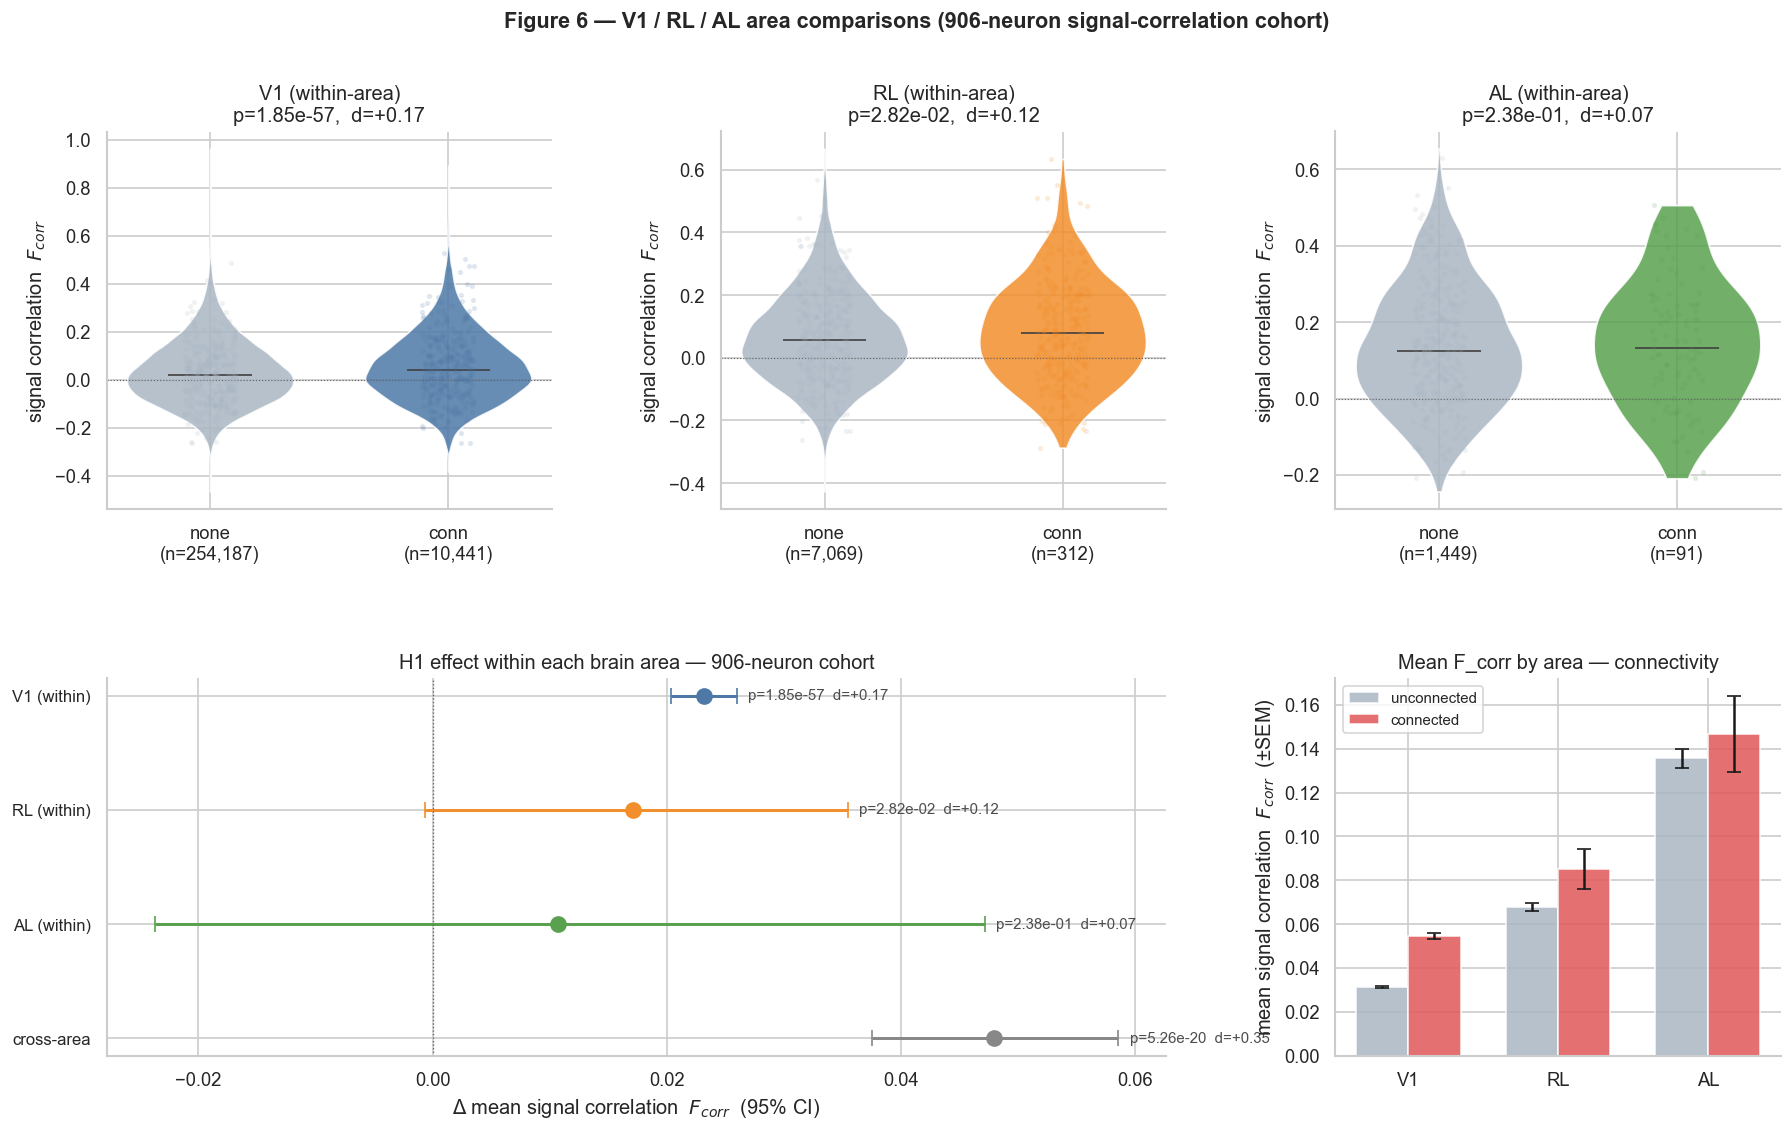

Saved: outputs/figures/person4_scan93_area_checks.png


In [149]:
fig = plt.figure(figsize=(18, 10))
gs = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

for col, area in enumerate(AREAS):
    ax = fig.add_subplot(gs[0, col])
    sub = pairs906[pairs906.same_area & (pairs906.area_i == area)]
    a_v = sub.loc[sub.connected, 'f_corr'].to_numpy()
    b_v = sub.loc[~sub.connected, 'f_corr'].to_numpy()
    parts = ax.violinplot([b_v, a_v], positions=[1, 2],
                          showmedians=True, showextrema=False, widths=0.7)
    for k, pc in enumerate(parts['bodies']):
        pc.set_facecolor([PAL_CONN['none'], PAL_AREA[area]][k])
        pc.set_edgecolor('white'); pc.set_alpha(0.85)
    for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
        if key in parts:
            parts[key].set_color('0.25'); parts[key].set_linewidth(1.0)
    np.random.seed(col)
    for k, (dv, cv) in enumerate(zip([b_v, a_v], [PAL_CONN['none'], PAL_AREA[area]])):
        jit = np.random.uniform(-0.11, 0.11, min(len(dv), 300))
        smp = np.random.choice(dv, min(len(dv), 300), replace=False)
        ax.scatter(np.full(len(smp), k+1) + jit, smp, alpha=0.12, s=5, color=cv, zorder=3)
    r_matches = [r for r in area_results906 if r.get('area') == area]
    title_stats = f'p={r_matches[0]["p_one_sided"]:.2e},  d={r_matches[0]["cohens_d"]:+.2f}' if r_matches else 'not enough connected pairs'
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'none\n(n={len(b_v):,})', f'conn\n(n={len(a_v):,})'])
    ax.set_ylabel('signal correlation  $F_{corr}$')
    ax.set_title(f'{area} (within-area)\n{title_stats}')
    ax.axhline(0, color='0.4', lw=0.7, ls=':')

ax_f = fig.add_subplot(gs[1, 0:2])
forest_labels = [r['comparison'] for r in area_results906]
forest_colors = [PAL_AREA.get(r.get('area', 'cross'), '#888888') for r in area_results906]
ypos_f = np.arange(len(area_results906))[::-1]
for y_, r_, c_ in zip(ypos_f, area_results906, forest_colors):
    ax_f.errorbar(r_['mean_diff'], y_,
                  xerr=[[r_['mean_diff'] - r_['ci_lo']], [r_['ci_hi'] - r_['mean_diff']]],
                  fmt='o', color=c_, markersize=9, capsize=5, lw=1.8)
    ax_f.text(r_['ci_hi'] + 0.001, y_,
              f"p={r_['p_one_sided']:.2e}  d={r_['cohens_d']:+.2f}",
              va='center', fontsize=9, color='0.3')
ax_f.axvline(0, color='0.4', lw=0.8, ls=':')
ax_f.set_yticks(ypos_f); ax_f.set_yticklabels(forest_labels, fontsize=10)
ax_f.set_xlabel('Δ mean signal correlation  $F_{corr}$  (95% CI)')
ax_f.set_title('H1 effect within each brain area — 906-neuron cohort')

ax_b = fig.add_subplot(gs[1, 2])
x = np.arange(len(AREAS)); w = 0.35
for k_shift, (label, conn_flag) in enumerate([('unconnected', False), ('connected', True)]):
    means_a, sems_a = [], []
    for area in AREAS:
        sub = pairs906[pairs906.same_area & (pairs906.area_i == area)]
        vals = sub.loc[sub.connected == conn_flag, 'f_corr'].to_numpy()
        means_a.append(vals.mean() if len(vals) > 0 else np.nan)
        sems_a.append(vals.std(ddof=1)/np.sqrt(len(vals)) if len(vals) > 1 else 0)
    ax_b.bar(x + (k_shift - 0.5)*w, means_a, w, yerr=sems_a, label=label,
             color=PAL_CONN['none'] if not conn_flag else '#E15759',
             edgecolor='white', capsize=4, alpha=0.85)
ax_b.set_xticks(x); ax_b.set_xticklabels(AREAS)
ax_b.set_ylabel('mean signal correlation  $F_{corr}$  (±SEM)')
ax_b.set_title('Mean F_corr by area — connectivity')
ax_b.legend(fontsize=9); ax_b.axhline(0, color='0.4', lw=0.7, ls=':')

fig.suptitle('Figure 6 — V1 / RL / AL area comparisons (906-neuron signal-correlation cohort)',
             fontweight='bold', fontsize=13)
out_fig = OUT_FIG / 'person4_scan93_area_checks.png'
fig.savefig(out_fig, bbox_inches='tight')
plt.show()
print(f'Saved: {relpath(out_fig)}')


### Save the 93-Neuron + Area Summary Table

Combine the 93-neuron scan-9.3 sanity result with the four 906-neuron area results into one tidy table and write it to `outputs/tables/person4_scan93_area_summary.csv` for cross-section reference.

In [150]:
save_cols = ['comparison', 'area', 'scope', 'n_conn', 'n_ctrl',
             'mean_conn', 'mean_ctrl', 'mean_diff', 'ci_lo', 'ci_hi', 'cohens_d', 'p_one_sided']
scan93_row = {
    'comparison': 'scan-9.3 sanity (trace-corr)', 'area': 'V1 L4', 'scope': 'scan93',
    'n_conn': H1_93_RESULT['n_conn'], 'n_ctrl': H1_93_RESULT['n_ctrl'],
    'mean_conn': H1_93_RESULT['mean_conn'], 'mean_ctrl': H1_93_RESULT['mean_ctrl'],
    'mean_diff': H1_93_RESULT['mean_diff'], 'ci_lo': H1_93_RESULT['ci_lo'],
    'ci_hi': H1_93_RESULT['ci_hi'], 'cohens_d': H1_93_RESULT['cohens_d'],
    'p_one_sided': H1_93_RESULT['p_one_sided'],
}
person4_summary_df = pd.DataFrame([scan93_row] + area_results906)[save_cols]
out_csv = OUT_TBL / 'person4_scan93_area_summary.csv'
person4_summary_df.to_csv(out_csv, index=False)
print(f'Saved: {relpath(out_csv)}')
print()
print(person4_summary_df.to_string(index=False))


Saved: outputs/tables/person4_scan93_area_summary.csv

                  comparison  area  scope  n_conn  n_ctrl  mean_conn  mean_ctrl  mean_diff     ci_lo    ci_hi  cohens_d  p_one_sided
scan-9.3 sanity (trace-corr) V1 L4 scan93     221    4057   0.044243   0.018502   0.025824  0.018245 0.034182  0.710505 4.800530e-18
                 V1 (within)    V1 within   10441  254187   0.054449   0.031280   0.023200  0.020394 0.025997  0.172429 1.852645e-57
                 RL (within)    RL within     312    7069   0.085076   0.067883   0.017125 -0.000616 0.035471  0.116687 2.822086e-02
                 AL (within)    AL within      91    1449   0.146707   0.135610   0.010746 -0.023738 0.047178  0.068871 2.377700e-01
                  cross-area cross  cross     736  135680   0.049649   0.001764   0.047966  0.037590 0.058572  0.345003 5.259409e-20


### Validation and Scope Limitations

1. **Different functional measures are being compared.** The 93-neuron validation uses trace, signal, and noise correlation; the main 906-neuron cohort uses signal correlation only. These should not be collapsed into one number.

2. **The 93-neuron cohort is narrow.** It is layer 4 V1 from one scan. That makes it useful as a same-scan sanity check, but not as a replacement for the broader 906-neuron cohort.

3. **Area comparisons are imbalanced.** V1 dominates the 906-neuron cohort. RL and especially AL have fewer neurons and connected pairs, so area-specific null results are underpowered.

4. **Pair non-independence still applies.** Each neuron contributes to many pair rows. The same-scan validation statistics are useful effect indicators, but pair-level p-values should still be read with this dependence in mind.


## 10. Final Summary Table

This table pulls the full notebook into one compact summary. It includes H1-H7 plus the H1 validation and scope-check rows from the 93-neuron same-scan analysis and the V1/RL/AL exploratory comparison.

The summary is placed after the validation section so that it reflects the complete notebook rather than only the original H1-H7 merge. The `primary_measure`, `test_statistic_type`, and `p_value_type` columns define how each numeric value should be read.


In [151]:
def add_final_row(rows, analysis, cohort, question, primary_measure, effect,
                  ci_low=np.nan, ci_high=np.nan, test_statistic_type='not applicable',
                  test_statistic=np.nan, p_value_type='not applicable', p_value=np.nan,
                  interpretation_short=''):
    rows.append({
        'analysis': analysis,
        'cohort': cohort,
        'question': question,
        'primary_measure': primary_measure,
        'effect': effect,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'test_statistic_type': test_statistic_type,
        'test_statistic': test_statistic,
        'p_value_type': p_value_type,
        'p_value': p_value,
        'interpretation_short': interpretation_short,
    })


def require_result(summary_df, hypothesis, test):
    row = summary_df[(summary_df.hypothesis == hypothesis) & (summary_df.test == test)]
    if len(row) != 1:
        available = summary_df.loc[summary_df.hypothesis == hypothesis, 'test'].tolist()
        raise ValueError(f'Missing summary row for {hypothesis}: {test!r}. Available: {available}')
    return row.iloc[0]


def wald_z_from_ci(effect, ci_low, ci_high):
    se = (ci_high - ci_low) / (2 * 1.96)
    return effect / se if se > 0 else np.nan


final_rows = []

add_final_row(
    final_rows,
    analysis='H1',
    cohort='906',
    question='Are directly connected pairs more functionally correlated?',
    primary_measure='Δ mean F_corr (connected - unconnected)',
    effect=H1_RESULT.get('mean_diff'),
    ci_low=H1_RESULT.get('ci_lo'),
    ci_high=H1_RESULT.get('ci_hi'),
    test_statistic_type='neuron-identity permutation z',
    test_statistic=H1_RESULT.get('perm_z'),
    p_value_type='one-sided neuron-identity permutation',
    p_value=H1_RESULT.get('perm_p_one_sided'),
    interpretation_short='Supported: connected pairs have a modest but robustly higher signal correlation.',
)

add_final_row(
    final_rows,
    analysis='H2',
    cohort='906 connected pairs',
    question='Does synapse strength grade functional similarity?',
    primary_measure='Spearman rho (synapse-size sum vs F_corr)',
    effect=H2_RESULT.get('spearman_rho_sum'),
    ci_low=H2_RESULT.get('spearman_ci_lo'),
    ci_high=H2_RESULT.get('spearman_ci_hi'),
    test_statistic_type='neuron-identity permutation z',
    test_statistic=H2_RESULT.get('perm_z'),
    p_value_type='two-sided neuron-identity permutation',
    p_value=H2_RESULT.get('perm_p_two_sided'),
    interpretation_short='Supported but weak: stronger connected pairs are only slightly more correlated.',
)

add_final_row(
    final_rows,
    analysis='H3',
    cohort='906',
    question='Are reciprocal pairs more functionally similar than unidirectional pairs?',
    primary_measure='Δ mean F_corr (bidirectional - unidirectional)',
    effect=H3_RESULT.get('mean_bi') - H3_RESULT.get('mean_uni'),
    test_statistic_type='neuron-identity permutation z',
    test_statistic=H3_RESULT.get('perm_z_bi_gt_uni'),
    p_value_type='one-sided neuron-identity permutation',
    p_value=H3_RESULT.get('perm_p_bi_gt_uni'),
    interpretation_short='Partially supported: reciprocal pairs exceed unconnected pairs, but bi > uni is not detected.',
)

h4h6_summary = pd.DataFrame(RESULTS)
for hyp, preferred_test, question, primary_measure, p_type, short in [
    (
        'H4',
        'distance-matched',
        'Does the connected-pair effect remain after distance matching?',
        'Δ mean F_corr (connected - distance-matched unconnected)',
        'one-sided Mann-Whitney',
        'Supported: the connected-pair effect shrinks under distance matching but remains positive.',
    ),
    (
        'H5',
        'joint logistic β(f_corr | dist, area, layer, celltype)',
        'Does F_corr remain positive after distance and composition controls?',
        'standardized logistic β for F_corr',
        'HC0 logistic Wald p-value',
        'Supported: F_corr remains positive after coarse composition controls.',
    ),
    (
        'H6',
        'joint logistic β(f_corr | ori_sim, dist)',
        'Does F_corr remain positive after orientation similarity and distance controls?',
        'standardized logistic β for F_corr',
        'HC0 logistic Wald p-value',
        'Supported with caveat: F_corr remains positive; orientation adds a smaller residual bias.',
    ),
]:
    row = require_result(h4h6_summary, hyp, preferred_test)
    stat_type = 'Wald z (from HC0 CI)' if hyp in ['H5', 'H6'] else 'effect estimate only'
    stat_value = wald_z_from_ci(row.mean_diff, row.ci_lo, row.ci_hi) if hyp in ['H5', 'H6'] else np.nan
    add_final_row(
        final_rows,
        analysis=hyp,
        cohort='906',
        question=question,
        primary_measure=primary_measure,
        effect=row.mean_diff,
        ci_low=row.ci_lo,
        ci_high=row.ci_hi,
        test_statistic_type=stat_type,
        test_statistic=stat_value,
        p_value_type=p_type,
        p_value=row.p,
        interpretation_short=short,
    )

h7_primary = h7_summary[
    (h7_summary.cohort == 'all_906')
    & (h7_summary.functional_metric == 'mean_fcorr_signed')
    & (h7_summary.structural_metric == 'total_strength')
    & (h7_summary.controls == 'distance+area')
]
if len(h7_primary):
    row = h7_primary.iloc[0]
    add_final_row(
        final_rows,
        analysis='H7 / topology',
        cohort='906',
        question='Are structural hubs also functional hubs?',
        primary_measure='partial Spearman rho (total structural strength vs mean signed F_corr)',
        effect=row.rho,
        test_statistic_type='rho^2 rank variance approximation',
        test_statistic=row.rank_variance_approx,
        p_value_type='partial Spearman p-value',
        p_value=row.p_value,
        interpretation_short='Limited support: narrow signed hub coupling is weak and sensitivity-dependent.',
    )

if 'topology' in globals() and len(topology):
    topo_row = topology.loc[(topology.density_multiplier - 1.0).abs().idxmin()]
    add_final_row(
        final_rows,
        analysis='thresholded topology',
        cohort='906',
        question='Do structural and functional graphs have similar topology at matched density?',
        primary_measure='Spearman rho (structural degree vs thresholded functional degree)',
        effect=topo_row.spearman_struct_degree_vs_functional_degree,
        test_statistic_type='functional average clustering at matched density',
        test_statistic=topo_row.functional_clustering,
        p_value_type='Spearman p-value',
        p_value=topo_row.p_degree,
        interpretation_short='Not detected: matched-density degree coupling is near zero.',
    )

if 'h1_by_measure93' in globals():
    for measure_name, result in h1_by_measure93.items():
        add_final_row(
            final_rows,
            analysis=f'H1 validation: {measure_name}',
            cohort='93-neuron scan 9.3 V1/L4',
            question=f'Does connected > unconnected hold for {measure_name} correlation?',
            primary_measure='Δ mean correlation (connected - unconnected)',
            effect=result['mean_diff'],
            ci_low=result['ci_lo'],
            ci_high=result['ci_hi'],
            test_statistic_type="Cohen's d",
            test_statistic=result['cohens_d'],
            p_value_type='one-sided Mann-Whitney',
            p_value=result['p_one_sided'],
            interpretation_short=f'Supported for {measure_name} correlation.' if result['p_one_sided'] < 0.05 else f'Not resolved for {measure_name} correlation.',
        )

if 'area_results906' in globals():
    for result in area_results906:
        add_final_row(
            final_rows,
            analysis='H1 area scope',
            cohort=f"906 {result['comparison']}",
            question='Does connected > unconnected hold within or across areas?',
            primary_measure='Δ mean F_corr (connected - unconnected)',
            effect=result['mean_diff'],
            ci_low=result['ci_lo'],
            ci_high=result['ci_hi'],
            test_statistic_type="Cohen's d",
            test_statistic=result['cohens_d'],
            p_value_type='one-sided Mann-Whitney',
            p_value=result['p_one_sided'],
            interpretation_short=f"Exploratory {result['comparison']}: effect size d={result['cohens_d']:+.2f}.",
        )

final_summary = pd.DataFrame(final_rows)
out_final = TBL_DIR / 'final_analysis_summary.csv'
final_summary.to_csv(out_final, index=False)
print(f'saved: {relpath(out_final)}')
final_summary


saved: outputs/tables/final_analysis_summary.csv


,analysis,cohort,question,primary_measure,effect,ci_low,ci_high,test_statistic_type,test_statistic,p_value_type,p_value,interpretation_short
0,H1,906,Are directly connected pairs more functionally...,Δ mean F_corr (connected - unconnected),0.033459,0.030857,0.036143,neuron-identity permutation z,20.419764,one-sided neuron-identity permutation,9.999000e-05,Supported: connected pairs have a modest but r...
1,H2,906 connected pairs,Does synapse strength grade functional similar...,Spearman rho (synapse-size sum vs F_corr),0.068628,0.049769,0.086112,neuron-identity permutation z,7.208283,two-sided neuron-identity permutation,1.999600e-04,Supported but weak: stronger connected pairs a...
2,H3,906,Are reciprocal pairs more functionally similar...,Δ mean F_corr (bidirectional - unidirectional),0.012558,NaN,NaN,neuron-identity permutation z,1.412915,one-sided neuron-identity permutation,8.318336e-02,Partially supported: reciprocal pairs exceed u...
3,H4,906,Does the connected-pair effect remain after di...,Δ mean F_corr (connected - distance-matched un...,0.018499,0.014696,0.022134,effect estimate only,NaN,one-sided Mann-Whitney,4.357941e-23,Supported: the connected-pair effect shrinks u...
4,H5,906,Does F_corr remain positive after distance and...,standardized logistic β for F_corr,0.129588,0.111582,0.147593,Wald z (from HC0 CI),14.106575,HC0 logistic Wald p-value,3.459757e-45,Supported: F_corr remains positive after coars...
5,H6,906,Does F_corr remain positive after orientation ...,standardized logistic β for F_corr,0.121677,0.101335,0.142019,Wald z (from HC0 CI),11.723947,HC0 logistic Wald p-value,9.608849e-32,Supported with caveat: F_corr remains positive...
6,H7 / topology,906,Are structural hubs also functional hubs?,partial Spearman rho (total structural strengt...,0.109542,NaN,NaN,rho^2 rank variance approximation,0.011999,partial Spearman p-value,9.579571e-04,Limited support: narrow signed hub coupling is...
7,thresholded topology,906,Do structural and functional graphs have simil...,Spearman rho (structural degree vs thresholded...,0.008211,NaN,NaN,functional average clustering at matched density,0.287253,Spearman p-value,8.050468e-01,Not detected: matched-density degree coupling ...
8,H1 validation: trace,93-neuron scan 9.3 V1/L4,Does connected > unconnected hold for trace co...,Δ mean correlation (connected - unconnected),0.025824,0.018245,0.034182,Cohen's d,0.710505,one-sided Mann-Whitney,4.800530e-18,Supported for trace correlation.
9,H1 validation: signal,93-neuron scan 9.3 V1/L4,Does connected > unconnected hold for signal c...,Δ mean correlation (connected - unconnected),0.052858,0.032801,0.073608,Cohen's d,0.410389,one-sided Mann-Whitney,7.030248e-08,Supported for signal correlation.


## 11. Overall Conclusion

The analysis supports the assignment's main pair-level answer: directly connected neurons are more functionally similar than unconnected neurons in the 906-neuron cohort. The effect is statistically robust but quantitatively modest, remains positive after distance and coarse composition controls, and is not replaced by orientation similarity.

The supporting hypotheses refine that conclusion. Synapse strength adds a weak graded component, and reciprocity does not add a detectable premium beyond connectedness in the 906-neuron cohort. These results indicate that anatomy carries functional information noisily: direct connectivity shifts the expected functional similarity distribution rather than determining the functional relationship of individual pairs.

The validation section strengthens the H1-centered interpretation. In the 93-neuron same-scan V1/L4 cohort, connected pairs are also more correlated, and the effect appears in trace, signal, and residual noise correlations. The V1/RL/AL comparison suggests that the effect is clearest in V1, weaker in RL, and unresolved in AL; the non-V1 areas are much smaller, so those area-level contrasts remain tentative.

The network-level result is more limited. The weak signed hub-coupling signal does not translate into detectable structural-functional topology similarity, and thresholded graph comparisons are sensitive to how the dense functional matrix is converted into a graph. The conclusion separates two claims: direct structural connectivity predicts higher functional similarity, while broader structural-functional topology matching is not detected.


## Reference Notes Moved From H4-H6

The notes below were moved from the H4-H6 control sections to keep the main analysis flow focused on question, test, result, and conclusion. They are preserved here with their original section source so they can be restored to those sections if needed.

### From Section 7.1 H4. Distance Control

**References.** *Cossell et al., 2015 — Nature 518:399-403*: in V1 L2/3 paired recordings, connection strength between excitatory neurons scales with response correlation **after** distance is accounted for. *Ko et al., 2011 — Nature 473:87-91*: in V1 the same like-to-like wiring bias is detected within tightly clustered local subnetworks, where distance varies little. *MICrONS Consortium, 2025 — Nature*: confirms in EM-reconstructed mouse visual cortex that connection probability falls steeply with distance and that response correlation contributes residual predictive power on top.

### From Section 7.2 H5. Composition Controls

**References.** *Ko et al., 2011 — Nature 473:87-91*: shows like-to-like connectivity within a single L2/3 V1 patch — i.e. *within* a compositional stratum — which is exactly the comparison the H5 within-stratum test reproduces here at MICrONS scale. *Cossell et al., 2015 — Nature 518:399-403*: confirms that response correlation predicts connection strength within L2/3 of V1, again controlling for compositional identity by construction. *MICrONS Consortium, 2025 — Nature*: jointly models connection probability with response correlation, distance, and area/layer/cell-type identifiers across the full V1+RL+AL volume.

### From Section 7.3 H6. Orientation Similarity

**References.** *Ko et al., 2011 — Nature 473:87-91*: directly tests connection probability against orientation similarity in L2/3 V1 paired recordings and reports the canonical orientation-driven like-to-like bias. *Cossell et al., 2015 — Nature 518:399-403*: pits signal correlation against orientation similarity and concludes that response correlation is the better predictor of synaptic strength once both are available. *MICrONS Consortium, 2025 — Nature*: confirms the same prediction at EM scale and reports analogous standardised coefficient comparisons.
